# Cross-Country Asset Return Prediction with Machine Learning

This project studies whether asset-level characteristics and macroeconomic
information can predict next-month excess returns across a diversified panel
of assets, and whether those forecasts can improve portfolio allocation out
of sample.

The analysis compares regularized linear and nonlinear machine-learning
models under strictly time-ordered validation and evaluates the resulting
forecasts against simple portfolio benchmarks after transaction costs.

## Data Description

The dataset is an anonymized monthly panel spanning January 2000 through December 2024. It contains 50 assets across four asset classes and 12 countries, together with asset-level characteristics and global and country-level macroeconomic variables. Returns are monthly excess returns expressed in decimals.

| File | Structure | Contents |
|---|---|---|
| `asset_panel.csv` | asset × month (50 × 300) | Returns, asset metadata, and `x1`–`x5` asset characteristics |
| `asset_returns_wide.csv` | month × asset | Monthly excess returns in wide format |
| `asset_info.csv` | asset | Asset-class and country mappings |
| `macro_global.csv` | month | `x6`–`x9` global macroeconomic variables |
| `macro_country.csv` | country × month | `x10`–`x16` curated country-level variables |
| `macro_country_extended.csv` | country × month | `x17`–`x164` extended country-level macroeconomic variables |

The asset universe consists of 26 Class A assets, 8 Class B assets, 9 Class C assets, and 7 Class D assets. Assets in Classes B, C, and D have economically meaningful country assignments. Class A has no natural country assignment and is coded as `country_7` in the raw data; this distinction is handled explicitly during feature engineering.

Variables `x1` through `x5` are anonymized cross-sectional asset characteristics derived from each asset's own historical pricing, fundamental, and risk information. Variables `x6` through `x164` represent anonymized macroeconomic and financial conditions, including global and country-level information. Their identities are intentionally hidden, so their behavior is investigated empirically through their scale, persistence, cross-sectional structure, and relationship with returns.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

_DATA_DIR = '/classes/41210_MiF_fall2026/Data/'
# _DATA_DIR = './'    # if the data files sit next to this notebook

panel = pd.read_csv(_DATA_DIR + 'asset_panel.csv', parse_dates=['date'])
info  = pd.read_csv(_DATA_DIR + 'asset_info.csv', index_col=0)
mac_g = pd.read_csv(_DATA_DIR + 'macro_global.csv', parse_dates=['date'])
mac_c = pd.read_csv(_DATA_DIR + 'macro_country.csv', parse_dates=['date'])
mac_x = pd.read_csv(_DATA_DIR + 'macro_country_extended.csv', parse_dates=['date'])
print(panel.shape, panel.date.min().date(), panel.date.max().date())
panel.head()


(15000, 10) 2000-01-31 2024-12-31


,date,asset_id,asset_class,country,excess_return,x1,x2,x3,x4,x5
0,2000-01-31,asset_1,A,country_7,0.035385,0.044852,0.970233,-0.109145,0.158469,0.086743
1,2000-02-29,asset_1,A,country_7,0.116676,0.073761,0.974766,-0.109145,0.133949,0.085443
2,2000-03-31,asset_1,A,country_7,0.040920,0.089627,0.922260,-0.109145,0.188675,0.086244
3,2000-04-30,asset_1,A,country_7,-0.008399,0.074356,1.055247,-0.109145,0.206628,0.085047
4,2000-05-31,asset_1,A,country_7,-0.086259,0.067134,0.788085,-0.109145,0.227556,0.083820



# Analysis

## 1. Data Preparation and Exploratory Data Analysis

This section examines the structure of the asset and macroeconomic datasets before any forecasting models are estimated. We verify the integrity of the panel, summarize return behavior across assets and asset classes, investigate the five anonymized asset characteristics, examine preliminary predictive relationships, and audit the macroeconomic variables for missingness and redundancy.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings

from IPython.display import display
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings('ignore')

# The class-server path should already be defined above.
_DATA_DIR = '/classes/41210_MiF_fall2026/Data/'
# _DATA_DIR = './'   # Use this instead if the files are next to the notebook.

panel = pd.read_csv(_DATA_DIR + 'asset_panel.csv', parse_dates=['date'])
info = pd.read_csv(_DATA_DIR + 'asset_info.csv')
returns_wide = pd.read_csv(_DATA_DIR + 'asset_returns_wide.csv',
                           parse_dates=['date'])

mac_g = pd.read_csv(_DATA_DIR + 'macro_global.csv',
                    parse_dates=['date'])

mac_c = pd.read_csv(_DATA_DIR + 'macro_country.csv',
                    parse_dates=['date'])

mac_x = pd.read_csv(_DATA_DIR + 'macro_country_extended.csv',
                    parse_dates=['date'])

print("Asset panel:", panel.shape)
print("Asset information:", info.shape)
print("Wide returns:", returns_wide.shape)
print("Global macro:", mac_g.shape)
print("Country macro:", mac_c.shape)
print("Extended country macro:", mac_x.shape)

Asset panel: (15000, 10)
Asset information: (50, 3)
Wide returns: (300, 51)
Global macro: (300, 5)
Country macro: (3600, 9)
Extended country macro: (3600, 150)


### 1.1 Sample and Asset Universe

We first verify the dimensions, date coverage, completeness, and internal consistency of the asset panel. We also examine how the 50 assets are distributed across asset classes and countries.

In [6]:
char_cols = ['x1', 'x2', 'x3', 'x4', 'x5']

audit = pd.DataFrame({
    'Value': [
        len(panel),
        panel['asset_id'].nunique(),
        panel['date'].nunique(),
        panel['date'].min().strftime('%Y-%m-%d'),
        panel['date'].max().strftime('%Y-%m-%d'),
        panel.duplicated(['asset_id', 'date']).sum(),
        panel['excess_return'].isna().sum(),
        panel[char_cols].isna().sum().sum()
    ]
}, index=[
    'Asset-month observations',
    'Number of assets',
    'Number of months',
    'First date',
    'Last date',
    'Duplicate asset-month rows',
    'Missing excess returns',
    'Missing x1-x5 values'
])

display(audit)

,Value
Asset-month observations,15000
Number of assets,50
Number of months,300
First date,2000-01-31
Last date,2024-12-31
Duplicate asset-month rows,0
Missing excess returns,0
Missing x1-x5 values,0


In [7]:
returns_from_panel = (
    panel.pivot(index='date',
                columns='asset_id',
                values='excess_return')
    .sort_index()
)

returns_from_wide = (
    returns_wide
    .set_index('date')
    .sort_index()
)

# Put columns in exactly the same order before comparing.
returns_from_wide = returns_from_wide[returns_from_panel.columns]

max_difference = (
    returns_from_panel - returns_from_wide
).abs().to_numpy().max()

print("Maximum difference between the two return files:", max_difference)

Maximum difference between the two return files: 0.0


In [8]:
class_counts = (
    info.groupby('asset_class')
    .agg(
        n_assets=('asset_id', 'nunique'),
        n_countries=('country', 'nunique')
    )
)

class_counts['share_of_assets_pct'] = (
    100 * class_counts['n_assets'] / len(info)
)

class_counts = class_counts[
    ['n_assets', 'share_of_assets_pct', 'n_countries']
]

display(class_counts.round(2))

,n_assets,share_of_assets_pct,n_countries
asset_class,,,
A,26,52.0,1
B,8,16.0,8
C,9,18.0,9
D,7,14.0,7


In [9]:
country_mapping = (
    info.groupby(['asset_class', 'country'])
    .size()
    .unstack(fill_value=0)
)

display(country_mapping)

country,country_1,country_10,country_11,country_12,country_2,country_3,country_4,country_5,country_6,country_7,country_8,country_9
asset_class,,,,,,,,,,,,
A,0,0,0,0,0,0,0,0,0,26,0,0
B,1,1,1,1,0,1,0,1,0,0,1,1
C,0,0,1,0,1,1,1,1,1,1,1,1
D,0,0,1,1,0,1,0,1,0,1,1,1


### 1.2 Return Behavior Across Asset Classes

We next summarize the return distribution of individual assets and equal-weighted asset-class portfolios. These statistics help determine whether pooling all assets under a common loss function is appropriate.

In [10]:
asset_stats = (
    panel.groupby(['asset_id', 'asset_class', 'country'])
    .agg(
        mean_monthly_return=('excess_return', 'mean'),
        monthly_volatility=('excess_return', 'std'),
        worst_month=('excess_return', 'min')
    )
    .reset_index()
)

asset_stats['annualized_return'] = (
    12 * asset_stats['mean_monthly_return']
)

asset_stats['annualized_volatility'] = (
    np.sqrt(12) * asset_stats['monthly_volatility']
)

asset_stats['sharpe_ratio'] = (
    asset_stats['annualized_return']
    / asset_stats['annualized_volatility']
)

# Sort asset_1, asset_2, ..., asset_50 numerically rather than alphabetically.
asset_stats['asset_number'] = (
    asset_stats['asset_id']
    .str.extract(r'(\d+)')
    .astype(int)
)

asset_stats = asset_stats.sort_values(
    ['asset_class', 'asset_number']
)

asset_table = asset_stats[
    [
        'asset_id',
        'asset_class',
        'country',
        'annualized_return',
        'annualized_volatility',
        'sharpe_ratio',
        'worst_month'
    ]
].copy()

# Convert return columns to percentages for display.
asset_table['annualized_return'] *= 100
asset_table['annualized_volatility'] *= 100
asset_table['worst_month'] *= 100

asset_table = asset_table.rename(columns={
    'asset_id': 'Asset',
    'asset_class': 'Class',
    'country': 'Country',
    'annualized_return': 'Ann. excess return (%)',
    'annualized_volatility': 'Ann. volatility (%)',
    'sharpe_ratio': 'Sharpe ratio',
    'worst_month': 'Worst month (%)'
})

display(asset_table.round(3))

,Asset,Class,Country,Ann. excess return (%),Ann. volatility (%),Sharpe ratio,Worst month (%)
0,asset_1,A,country_7,9.361,35.005,0.267,-24.051
11,asset_2,A,country_7,8.619,28.006,0.308,-27.489
33,asset_4,A,country_7,13.750,35.674,0.385,-31.490
44,asset_5,A,country_7,-0.149,20.202,-0.007,-16.876
46,asset_6,A,country_7,7.866,16.051,0.490,-18.460
47,asset_7,A,country_7,-5.047,30.056,-0.168,-25.248
2,asset_11,A,country_7,13.559,33.503,0.405,-33.390
4,asset_13,A,country_7,-0.360,29.061,-0.012,-24.146
5,asset_14,A,country_7,1.516,29.343,0.052,-25.212
6,asset_15,A,country_7,12.305,33.948,0.362,-54.214


In [11]:
print(
    "Lowest annualized asset volatility:",
    f"{asset_stats['annualized_volatility'].min():.2%}"
)

print(
    "Highest annualized asset volatility:",
    f"{asset_stats['annualized_volatility'].max():.2%}"
)

print(
    "Lowest monthly asset volatility:",
    f"{asset_stats['monthly_volatility'].min():.2%}"
)

print(
    "Highest monthly asset volatility:",
    f"{asset_stats['monthly_volatility'].max():.2%}"
)

Lowest annualized asset volatility: 2.85%
Highest annualized asset volatility: 60.26%
Lowest monthly asset volatility: 0.82%
Highest monthly asset volatility: 17.40%


**Table 1. Full-sample summary statistics for equal-weighted asset-class portfolios**

In [12]:
# Equal-weighted monthly return within each asset class.
class_ret = (
    panel.groupby(['date', 'asset_class'])['excess_return']
    .mean()
    .unstack()
    .sort_index()
)

class_statistics = []

for asset_class in class_ret.columns:

    r = class_ret[asset_class].dropna()

    annualized_return = r.mean() * 12
    annualized_volatility = r.std(ddof=1) * np.sqrt(12)

    sharpe = (
        annualized_return / annualized_volatility
    )

    worst_month = r.min()
    worst_date = r.idxmin()

    wealth = (1 + r).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    max_drawdown = drawdown.min()

    class_statistics.append([
        asset_class,
        annualized_return,
        annualized_volatility,
        sharpe,
        worst_month,
        worst_date,
        max_drawdown
    ])

class_summary = pd.DataFrame(
    class_statistics,
    columns=[
        'Class',
        'Annualized Return',
        'Annualized Volatility',
        'Sharpe Ratio',
        'Worst Month',
        'Worst Month Date',
        'Maximum Drawdown'
    ]
)

class_summary_display = class_summary.copy()

for column in [
    'Annualized Return',
    'Annualized Volatility',
    'Worst Month',
    'Maximum Drawdown'
]:
    class_summary_display[column] *= 100

class_summary_display['Worst Month Date'] = (
    class_summary_display['Worst Month Date']
    .dt.strftime('%Y-%m')
)

display(class_summary_display.round({
    'Annualized Return': 2,
    'Annualized Volatility': 2,
    'Sharpe Ratio': 2,
    'Worst Month': 2,
    'Maximum Drawdown': 2
}))

,Class,Annualized Return,Annualized Volatility,Sharpe Ratio,Worst Month,Worst Month Date,Maximum Drawdown
0,A,6.02,14.61,0.41,-19.85,2008-10,-52.66
1,B,-0.24,7.95,-0.03,-8.52,2008-10,-42.22
2,C,4.77,14.61,0.33,-16.02,2008-10,-55.11
3,D,2.68,5.28,0.51,-5.03,2022-09,-24.80


**Figure 1. Cumulative excess returns by asset class, 2000-2024**

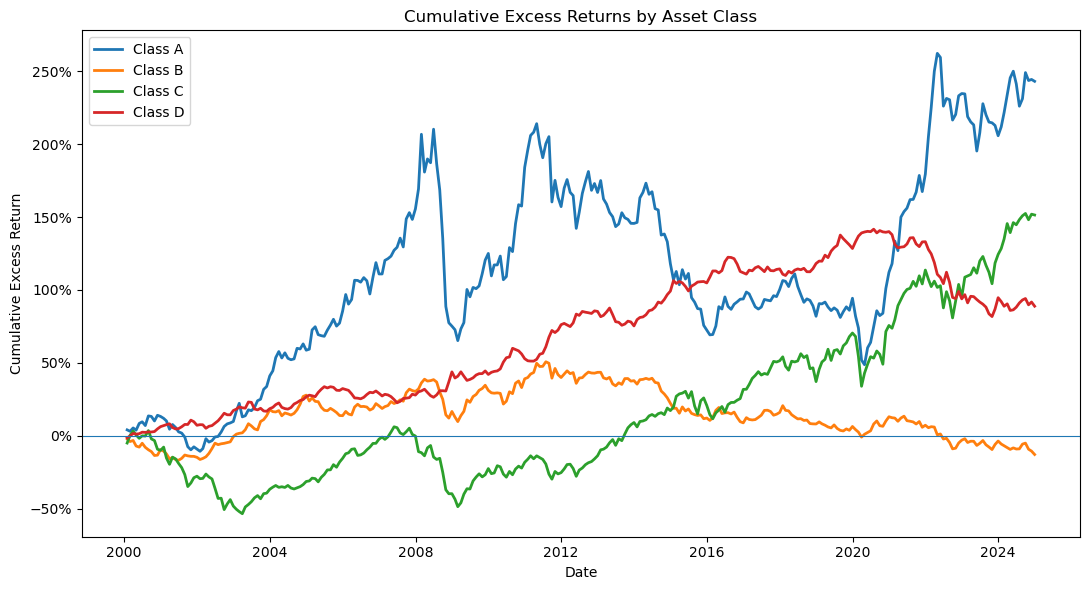

In [13]:
cumulative_class_returns = (
    (1 + class_ret).cumprod() - 1
)

fig, ax = plt.subplots(figsize=(11, 6))

for asset_class in cumulative_class_returns.columns:
    ax.plot(
        cumulative_class_returns.index,
        cumulative_class_returns[asset_class],
        label=f'Class {asset_class}',
        linewidth=2
    )

ax.axhline(0, linewidth=0.8)
ax.set_title('Cumulative Excess Returns by Asset Class')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Excess Return')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend()
plt.tight_layout()
fig.savefig(
    "figure1_cumulative_returns.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

**Figure 2. Correlation matrix of monthly excess returns ordered by asset class**

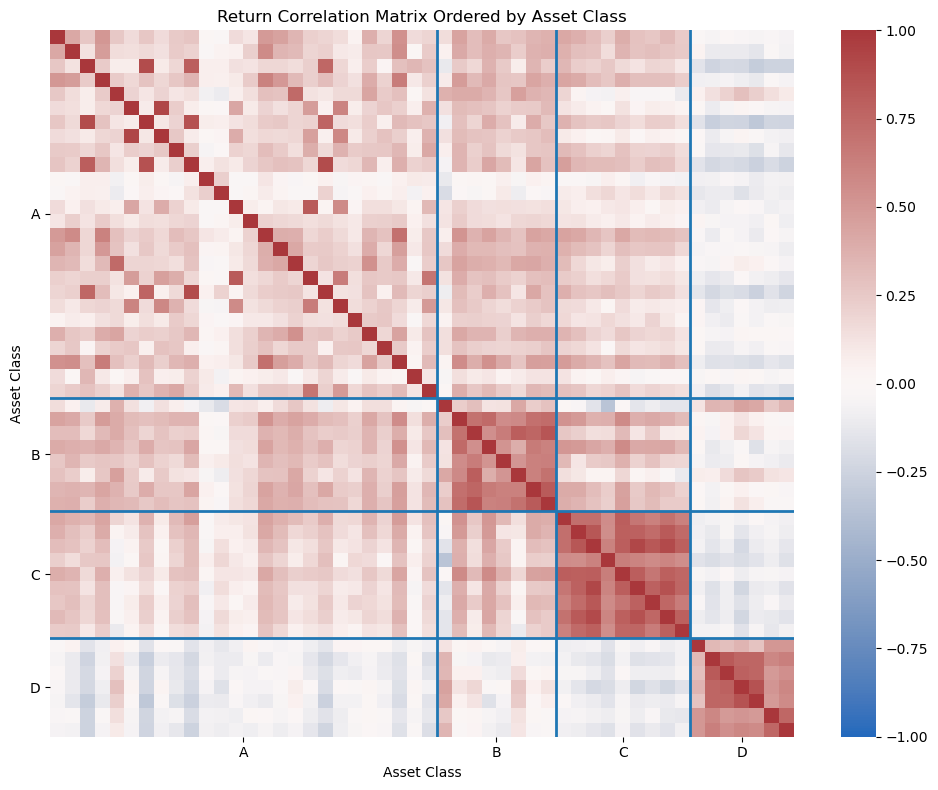

In [18]:
# Individual-asset return matrix.
ret_wide = (
    panel.pivot(
        index='date',
        columns='asset_id',
        values='excess_return'
    )
    .sort_index()
)

# Asset-class lookup.
asset_classes = (
    info.set_index('asset_id')['asset_class']
)

# Natural ordering of asset IDs.
def asset_number(asset_id):
    return int(asset_id.split('_')[1])

ordered_assets = []

for asset_class in ['A', 'B', 'C', 'D']:
    assets = asset_classes[
        asset_classes == asset_class
    ].index.tolist()

    ordered_assets.extend(
        sorted(assets, key=asset_number)
    )

corr_matrix = (
    ret_wide[ordered_assets]
    .corr()
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    cmap='vlag',
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    ax=ax
)

# Draw boundaries between asset classes.
class_sizes = [
    (asset_classes == c).sum()
    for c in ['A', 'B', 'C', 'D']
]

boundaries = np.cumsum(class_sizes)

for boundary in boundaries[:-1]:
    ax.axhline(boundary, linewidth=2)
    ax.axvline(boundary, linewidth=2)

# Put class labels at block midpoints.
starts = np.r_[0, boundaries[:-1]]
midpoints = (starts + boundaries) / 2

ax.set_xticks(midpoints)
ax.set_xticklabels(['A', 'B', 'C', 'D'])

ax.set_yticks(midpoints)
ax.set_yticklabels(['A', 'B', 'C', 'D'], rotation=0)

ax.set_title('Return Correlation Matrix Ordered by Asset Class')
ax.set_xlabel('Asset Class')
ax.set_ylabel('Asset Class')

plt.tight_layout()
fig.savefig(
    "figure2_correlation_matrix.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

In [15]:
corr = ret_wide.corr()

within_class_corr = {}

for asset_class in ['A', 'B', 'C', 'D']:

    assets = asset_classes[
        asset_classes == asset_class
    ].index

    matrix = corr.loc[assets, assets].values

    # Use only unique off-diagonal correlations.
    values = matrix[
        np.triu_indices_from(matrix, k=1)
    ]

    within_class_corr[asset_class] = values.mean()


between_class_corr = {}

for class_1, class_2 in itertools.combinations(
    ['A', 'B', 'C', 'D'], 2
):

    assets_1 = asset_classes[
        asset_classes == class_1
    ].index

    assets_2 = asset_classes[
        asset_classes == class_2
    ].index

    between_class_corr[
        (class_1, class_2)
    ] = corr.loc[
        assets_1, assets_2
    ].values.mean()


block_corr = pd.DataFrame(
    index=['A', 'B', 'C', 'D'],
    columns=['A', 'B', 'C', 'D'],
    dtype=float
)

for asset_class, value in within_class_corr.items():
    block_corr.loc[asset_class, asset_class] = value

for (class_1, class_2), value in between_class_corr.items():
    block_corr.loc[class_1, class_2] = value
    block_corr.loc[class_2, class_1] = value

display(block_corr.round(3))

,A,B,C,D
A,0.211,0.240,0.176,-0.080
B,0.240,0.550,0.230,0.053
C,0.176,0.230,0.725,-0.104
D,-0.080,0.053,-0.104,0.580


**Figure 3. Rolling 12-month Sharpe ratios by asset class**

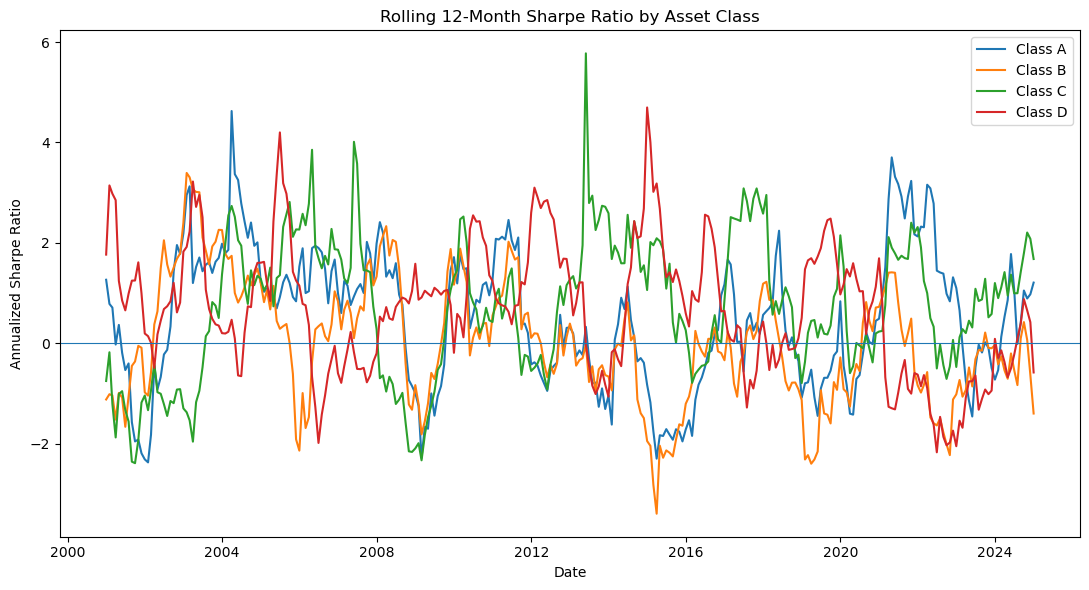

In [16]:
rolling_sharpe = (
    class_ret.rolling(12).mean()
    / class_ret.rolling(12).std(ddof=1)
    * np.sqrt(12)
)

fig, ax = plt.subplots(figsize=(11, 6))

for asset_class in rolling_sharpe.columns:
    ax.plot(
        rolling_sharpe.index,
        rolling_sharpe[asset_class],
        label=f'Class {asset_class}',
        linewidth=1.5
    )

ax.axhline(0, linewidth=0.8)
ax.set_title('Rolling 12-Month Sharpe Ratio by Asset Class')
ax.set_xlabel('Date')
ax.set_ylabel('Annualized Sharpe Ratio')
ax.legend()

plt.tight_layout()
plt.show()

In [17]:
positive_sharpe_share = (
    (rolling_sharpe > 0).sum()
    / rolling_sharpe.notna().sum()
)

positive_sharpe_table = (
    100 * positive_sharpe_share
).rename('Positive 12-Month Sharpe Windows (%)').to_frame()

display(positive_sharpe_table.round(1))

,Positive 12-Month Sharpe Windows (%)
asset_class,
A,61.9
B,49.5
C,70.6
D,69.2


### 1.3 Asset Characteristics

We next examine the distributions, scales, and persistence of the five anonymized asset characteristics. Because their economic labels are hidden, we also compare them with quantities reconstructed directly from historical returns.

In [26]:
characteristic_stats = []

for asset_class, group in panel.groupby('asset_class'):

    for variable in char_cols:

        s = group[variable]

        characteristic_stats.append([
            asset_class,
            variable,
            s.mean(),
            s.std(),
            s.min(),
            s.quantile(0.25),
            s.median(),
            s.quantile(0.75),
            s.max()
        ])

characteristic_stats = pd.DataFrame(
    characteristic_stats,
    columns=[
        'Class',
        'Variable',
        'Mean',
        'Std. Dev.',
        'Min',
        '25%',
        'Median',
        '75%',
        'Max'
    ]
)

display(
    characteristic_stats.round(4)
)

,Class,Variable,Mean,Std. Dev.,Min,25%,Median,75%,Max
0,A,x1,-0.0033,0.0236,-0.1409,-0.0122,-0.0032,0.0047,0.1483
1,A,x2,0.0688,0.3628,-0.8417,-0.1570,0.0063,0.2232,2.6724
2,A,x3,-0.2497,0.9522,-9.4960,-0.5321,-0.0109,0.3373,0.9630
3,A,x4,0.0003,0.0535,-0.3999,-0.0182,0.0005,0.0193,0.3366
4,A,x5,0.0834,0.0320,0.0240,0.0612,0.0800,0.1003,0.2732
5,B,x1,-0.0003,0.0017,-0.0061,-0.0013,-0.0003,0.0006,0.0049
6,B,x2,-0.0002,0.1063,-0.3053,-0.0701,-0.0060,0.0674,0.4461
7,B,x3,0.0378,0.2090,-0.6952,-0.1144,0.0547,0.1870,0.5786
8,B,x4,-0.0175,1.3035,-4.7122,-0.7100,-0.1400,0.4888,5.1500
9,B,x5,0.0284,0.0075,0.0127,0.0233,0.0271,0.0319,0.0566


**Figure 4. Distribution of the five asset characteristics by asset class**

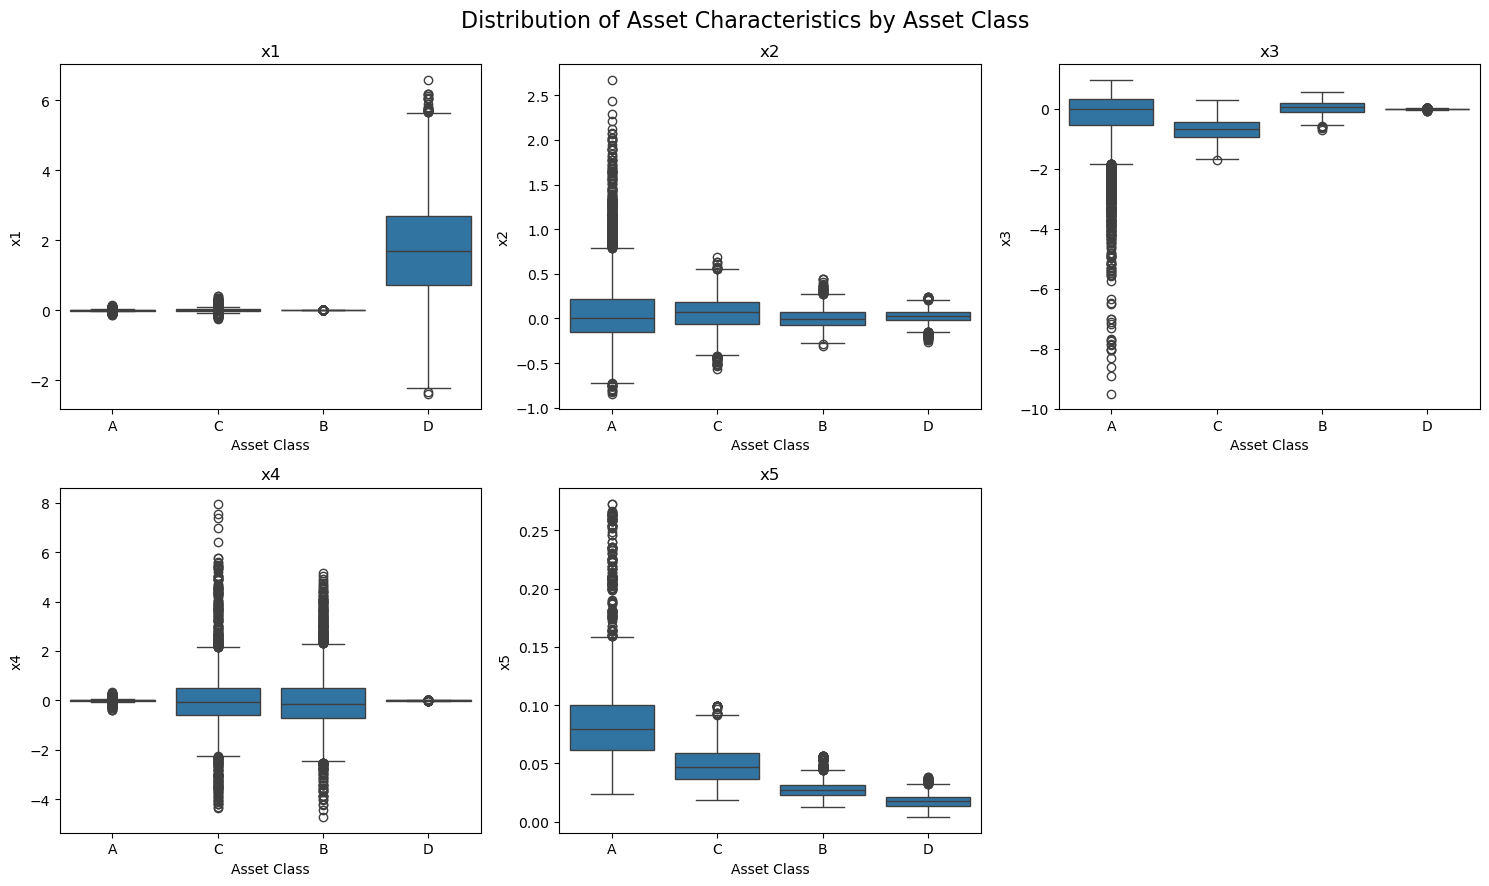

In [27]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 9)
)

axes = axes.flatten()

for i, variable in enumerate(char_cols):

    sns.boxplot(
        data=panel,
        x='asset_class',
        y=variable,
        ax=axes[i]
    )

    axes[i].set_title(variable)
    axes[i].set_xlabel('Asset Class')
    axes[i].set_ylabel(variable)

# Remove unused sixth panel.
axes[-1].axis('off')

fig.suptitle(
    'Distribution of Asset Characteristics by Asset Class',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [28]:
persistence_results = []

for asset_class in sorted(
    panel['asset_class'].unique()
):

    subset = (
        panel[
            panel['asset_class'] == asset_class
        ]
        .sort_values(['asset_id', 'date'])
    )

    for variable in char_cols:

        autocorrelations = []

        for asset_id, asset_data in subset.groupby(
            'asset_id'
        ):

            autocorrelations.append(
                asset_data[variable].autocorr(lag=1)
            )

        persistence_results.append([
            asset_class,
            variable,
            np.nanmean(autocorrelations),
            np.nanmin(autocorrelations),
            np.nanmax(autocorrelations)
        ])

persistence_table = pd.DataFrame(
    persistence_results,
    columns=[
        'Class',
        'Variable',
        'Average Lag-1 Autocorrelation',
        'Minimum',
        'Maximum'
    ]
)

display(
    persistence_table.round(3)
)

,Class,Variable,Average Lag-1 Autocorrelation,Minimum,Maximum
0,A,x1,0.525,-0.045,0.951
1,A,x2,0.909,0.867,0.942
2,A,x3,0.969,0.929,0.984
3,A,x4,0.425,-0.136,0.882
4,A,x5,0.987,0.964,0.995
5,B,x1,0.950,0.908,0.986
6,B,x2,0.916,0.875,0.929
7,B,x3,0.973,0.950,0.984
8,B,x4,0.974,0.952,0.985
9,B,x5,0.988,0.978,0.992


#### Investigating the Economic Meaning of the Anonymous Characteristics

The following diagnostics compare the anonymized characteristics with return-based quantities that can be reconstructed directly from the asset panel. These comparisons are exploratory and are used to form economic hypotheses about the characteristics rather than to redefine the supplied variables.

In [29]:
p = (
    panel
    .sort_values(['asset_id', 'date'])
    .copy()
)

# Compound the previous 12 monthly returns.
p['momentum_12m_reconstructed'] = (
    p.groupby('asset_id')['excess_return']
    .transform(
        lambda s:
        (1 + s)
        .shift(1)
        .rolling(12)
        .apply(np.prod, raw=True)
        - 1
    )
)

x2_check = (
    p[['x2', 'momentum_12m_reconstructed']]
    .dropna()
)

x2_error = (
    x2_check['x2']
    - x2_check['momentum_12m_reconstructed']
).abs()

print(
    "Correlation between x2 and reconstructed "
    "12-month momentum:",
    round(
        x2_check[
            ['x2', 'momentum_12m_reconstructed']
        ].corr().iloc[0, 1],
        6
    )
)

print(
    "Median absolute difference:",
    f"{x2_error.median():.8f}"
)

print(
    "Share within 0.0001:",
    f"{(x2_error < 1e-4).mean():.2%}"
)

Correlation between x2 and reconstructed 12-month momentum: 0.993362
Median absolute difference: 0.00000070
Share within 0.0001: 99.63%


In [30]:
# Sample standard deviation of the previous 36 monthly returns.
p['volatility_36m_reconstructed'] = (
    p.groupby('asset_id')['excess_return']
    .transform(
        lambda s:
        s.shift(1)
        .rolling(36)
        .std(ddof=1)
    )
)

# The supplied measure has a floor at 0.004.
p['volatility_36m_reconstructed'] = (
    p['volatility_36m_reconstructed']
    .clip(lower=0.004)
)

x5_check = (
    p[['x5', 'volatility_36m_reconstructed']]
    .dropna()
)

x5_error = (
    x5_check['x5']
    - x5_check['volatility_36m_reconstructed']
).abs()

print(
    "Correlation between x5 and reconstructed "
    "36-month volatility:",
    round(
        x5_check[
            ['x5', 'volatility_36m_reconstructed']
        ].corr().iloc[0, 1],
        10
    )
)

print(
    "Maximum absolute difference:",
    f"{x5_error.max():.8f}"
)

print(
    "Share within 0.000001:",
    f"{(x5_error < 1e-6).mean():.2%}"
)

Correlation between x5 and reconstructed 36-month volatility: 1.0
Maximum absolute difference: 0.00000064
Share within 0.000001: 100.00%


In [31]:
# Previous 60-month compounded return.
p['return_60m_previous'] = (
    p.groupby('asset_id')['excess_return']
    .transform(
        lambda s:
        (
            (1 + s)
            .rolling(60)
            .apply(np.prod, raw=True)
            - 1
        ).shift(1)
    )
)

x3_relationship = []

for asset_class in ['A', 'B', 'C', 'D']:

    subset = (
        p[p['asset_class'] == asset_class]
        [['x3', 'return_60m_previous']]
        .dropna()
    )

    correlation = subset['x3'].corr(
        -subset['return_60m_previous']
    )

    x3_relationship.append([
        asset_class,
        correlation
    ])

x3_relationship = pd.DataFrame(
    x3_relationship,
    columns=[
        'Class',
        'Correlation of x3 with Negative Prior 60-Month Return'
    ]
)

display(
    x3_relationship.round(3)
)

,Class,Correlation of x3 with Negative Prior 60-Month Return
0,A,0.999
1,B,0.936
2,C,0.364
3,D,0.941


### 1.4 Preliminary Cross-Sectional Predictive Evidence

Before estimating formal forecasting models, we conduct a simple nonparametric characteristic-sort exercise. Predictors are first aligned according to the timing rules in the project. Within each asset class and month, assets are then sorted into terciles based on each characteristic, and the subsequent return difference between the high and low terciles is calculated.

In [32]:
aligned = (
    panel
    .sort_values(['asset_id', 'date'])
    .copy()
)

# x1, x3 and x4 are contemporaneous in the supplied file,
# so use last month's value to predict this month's return.
for variable in ['x1', 'x3', 'x4']:

    aligned[f'{variable}_pred'] = (
        aligned.groupby('asset_id')[variable]
        .shift(1)
    )

# x2 and x5 are already lagged by the data provider.
for variable in ['x2', 'x5']:

    aligned[f'{variable}_pred'] = (
        aligned[variable]
    )

In [33]:
sort_results = []
ic_results = []

for asset_class in sorted(
    aligned['asset_class'].unique()
):

    subset = aligned[
        aligned['asset_class'] == asset_class
    ].copy()

    for variable in char_cols:

        predictor = f'{variable}_pred'

        monthly_spreads = []
        monthly_ics = []

        for date, month_data in subset.groupby('date'):

            month_data = (
                month_data
                .dropna(
                    subset=[
                        predictor,
                        'excess_return'
                    ]
                )
                .copy()
            )

            if (
                len(month_data) < 3
                or month_data[predictor].nunique() < 3
            ):
                continue

            # Rank first so qcut is robust to tied values.
            ranks = (
                month_data[predictor]
                .rank(method='first')
            )

            month_data['tercile'] = pd.qcut(
                ranks,
                3,
                labels=['Low', 'Mid', 'High']
            )

            tercile_returns = (
                month_data
                .groupby(
                    'tercile',
                    observed=True
                )['excess_return']
                .mean()
            )

            if (
                'High' in tercile_returns.index
                and 'Low' in tercile_returns.index
            ):

                monthly_spreads.append(
                    tercile_returns['High']
                    - tercile_returns['Low']
                )

            monthly_ics.append(
                month_data[predictor].corr(
                    month_data['excess_return'],
                    method='spearman'
                )
            )

        monthly_spreads = np.array(
            monthly_spreads,
            dtype=float
        )

        monthly_ics = np.array(
            monthly_ics,
            dtype=float
        )

        annualized_spread = (
            np.nanmean(monthly_spreads) * 12
        )


        sort_results.append([
            asset_class,
            variable,
            len(monthly_spreads),
            annualized_spread
        ])

        ic_results.append([
            asset_class,
            variable,
            np.nanmean(monthly_ics),
            np.nanstd(monthly_ics, ddof=1),
            len(monthly_ics)
        ])


sort_table = pd.DataFrame(
    sort_results,
    columns=[
        'Class',
        'Variable',
        'Months',
        'Annualized High-Low Return'
    ]
)

ic_table = pd.DataFrame(
    ic_results,
    columns=[
        'Class',
        'Variable',
        'Mean Rank IC',
        'SD Rank IC',
        'Months'
    ]
)

In [34]:
sort_display = sort_table.copy()

sort_display[
    'Annualized High-Low Return'
] *= 100

display(
    sort_display
    .sort_values(
        'Annualized High-Low Return',
        ascending=False
    )
    .round(3)
)

,Class,Variable,Months,Annualized High-Low Return
1,A,x2,300,3.819
3,A,x4,299,2.777
15,D,x1,299,2.230
17,D,x3,299,2.115
5,B,x1,299,2.020
18,D,x4,299,1.632
0,A,x1,299,1.572
13,C,x4,299,1.444
10,C,x1,299,1.364
14,C,x5,300,0.915


In [35]:
display(
    ic_table
    .sort_values(
        'Mean Rank IC',
        ascending=False
    )
    .round(3)
)

,Class,Variable,Mean Rank IC,SD Rank IC,Months
15,D,x1,0.098,0.494,299
5,B,x1,0.095,0.465,299
18,D,x4,0.049,0.450,299
17,D,x3,0.041,0.433,299
10,C,x1,0.034,0.338,299
19,D,x5,0.033,0.575,300
13,C,x4,0.025,0.376,299
6,B,x2,0.021,0.448,300
14,C,x5,0.017,0.427,300
1,A,x2,0.009,0.293,300


**Figure 5. Annualized high-minus-low characteristic-sort returns**

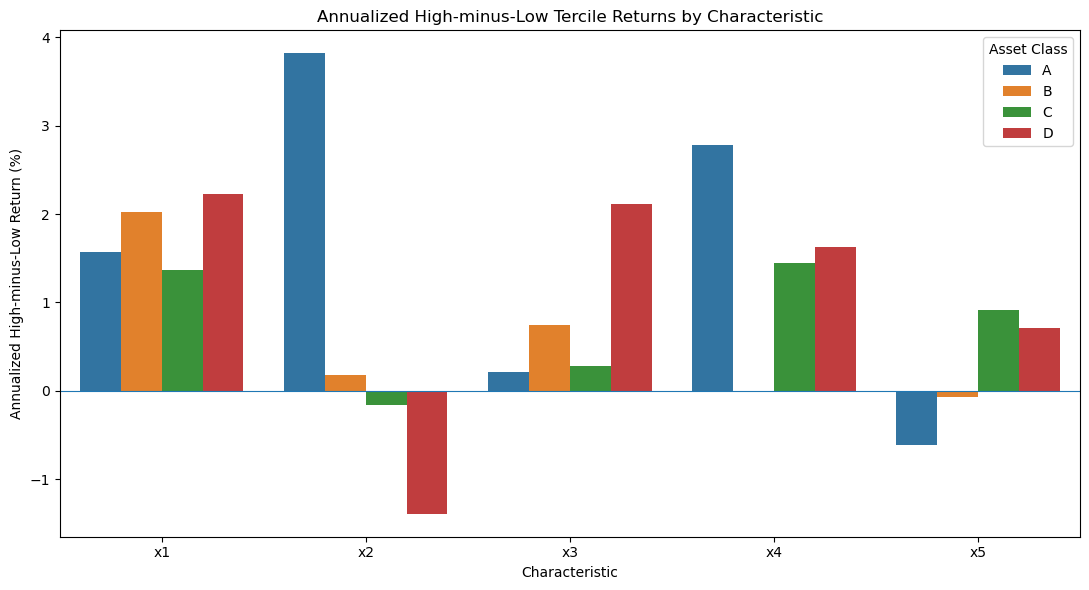

In [36]:
sort_plot = sort_table.copy()

sort_plot[
    'Annualized High-Low Return'
] *= 100

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=sort_plot,
    x='Variable',
    y='Annualized High-Low Return',
    hue='Class',
    ax=ax
)

ax.axhline(0, linewidth=0.8)
ax.set_title(
    'Annualized High-minus-Low Tercile Returns by Characteristic'
)
ax.set_xlabel('Characteristic')
ax.set_ylabel('Annualized High-minus-Low Return (%)')
ax.legend(title='Asset Class')

plt.tight_layout()
plt.show()

### 1.5 Volatility Scaling

Because return volatility differs sharply across asset classes, we examine how much each class contributes to a pooled squared-error objective before and after scaling returns by the lagged volatility characteristic `x5`.

In [37]:
scaled_panel = panel.copy()

scaled_panel['scaled_return'] = (
    scaled_panel['excess_return']
    / scaled_panel['x5']
)

# Share of assets in each class.
asset_share = (
    info.groupby('asset_class')
    .size()
    / len(info)
)

# Contribution to the sum of squared raw returns.
raw_squared_return = (
    scaled_panel
    .assign(
        squared_return=
        scaled_panel['excess_return'] ** 2
    )
    .groupby('asset_class')[
        'squared_return'
    ]
    .sum()
)

raw_squared_share = (
    raw_squared_return
    / raw_squared_return.sum()
)

# Contribution after scaling returns by x5.
scaled_squared_return = (
    scaled_panel
    .assign(
        squared_scaled_return=
        scaled_panel['scaled_return'] ** 2
    )
    .groupby('asset_class')[
        'squared_scaled_return'
    ]
    .sum()
)

scaled_squared_share = (
    scaled_squared_return
    / scaled_squared_return.sum()
)

scaling_table = pd.DataFrame({
    'Share of Assets (%)':
        100 * asset_share,

    'Share of Squared Raw Returns (%)':
        100 * raw_squared_share,

    'Share of Squared Scaled Returns (%)':
        100 * scaled_squared_share
})

display(
    scaling_table.round(2)
)

,Share of Assets (%),Share of Squared Raw Returns (%),Share of Squared Scaled Returns (%)
asset_class,,,
A,52.0,86.98,52.57
B,16.0,2.89,15.64
C,18.0,9.05,17.72
D,14.0,1.09,14.07


In [38]:
scaled_return_stats = (
    scaled_panel
    .groupby('asset_class')['scaled_return']
    .agg(['mean', 'std'])
)

display(
    scaled_return_stats.round(3)
)

,mean,std
asset_class,,
A,0.062,1.076
B,-0.021,1.060
C,0.085,1.061
D,0.133,1.067


### 1.6 Global and Country-Level Macroeconomic Data

Finally, we audit the macroeconomic datasets. We examine completeness and persistence in the curated macro variables and identify missing observations, exact duplicates, constants, and near-duplicate variables in the extended macro panel before using any macroeconomic predictors in a forecasting model.

In [39]:
global_macro_cols = [
    'x6', 'x7', 'x8', 'x9'
]

global_macro_summary = []

for variable in global_macro_cols:

    global_macro_summary.append([
        variable,
        mac_g[variable].isna().sum(),
        mac_g[variable].mean(),
        mac_g[variable].std(),
        mac_g[variable].autocorr(lag=1)
    ])

global_macro_summary = pd.DataFrame(
    global_macro_summary,
    columns=[
        'Variable',
        'Missing Observations',
        'Mean',
        'Standard Deviation',
        'Lag-1 Autocorrelation'
    ]
)

display(
    global_macro_summary.round(3)
)

,Variable,Missing Observations,Mean,Standard Deviation,Lag-1 Autocorrelation
0,x6,0,19.872,8.072,0.845
1,x7,0,0.812,0.119,0.984
2,x8,0,0.232,1.007,0.961
3,x9,0,0.067,0.019,0.978


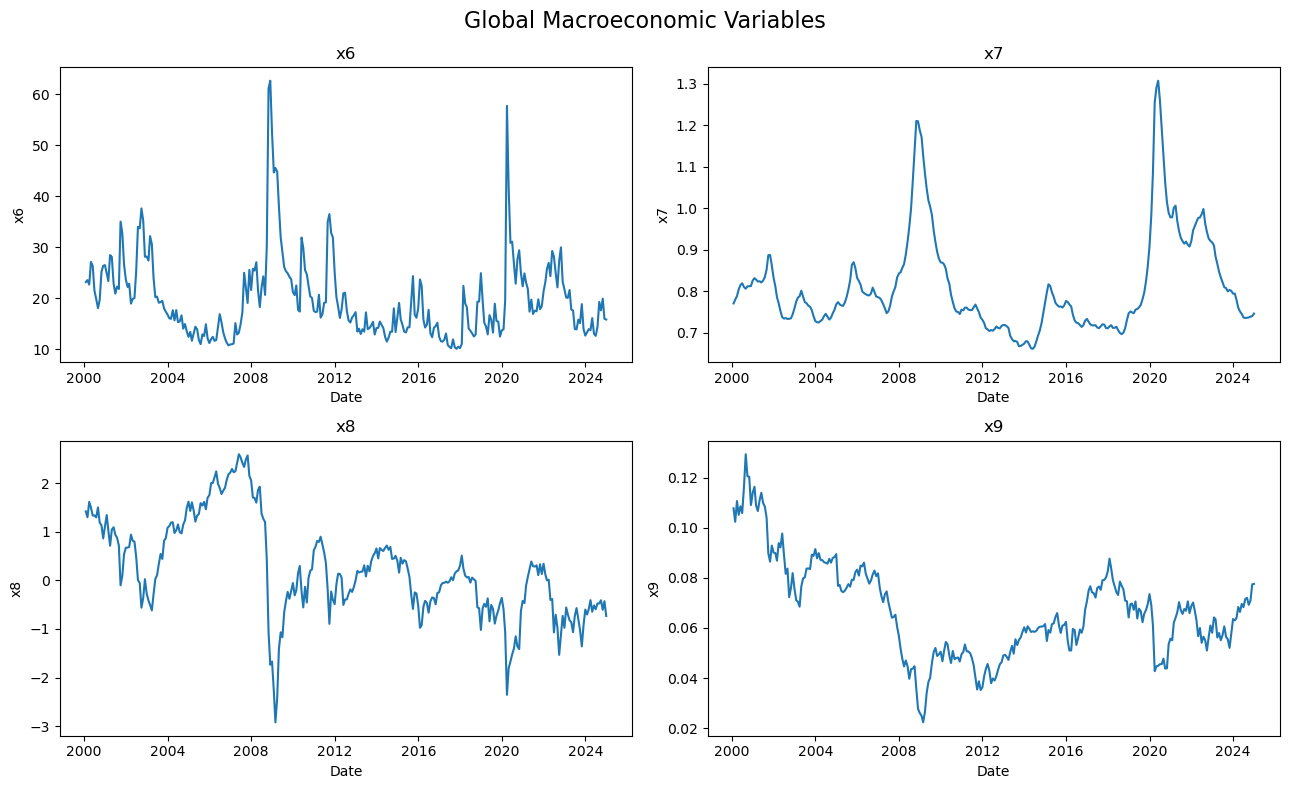

In [40]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(13, 8)
)

axes = axes.flatten()

for i, variable in enumerate(global_macro_cols):

    axes[i].plot(
        mac_g['date'],
        mac_g[variable]
    )

    axes[i].set_title(variable)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel(variable)

fig.suptitle(
    'Global Macroeconomic Variables',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [41]:
global_missing = (
    mac_g.isna().sum()
)

country_missing = (
    mac_c.isna().sum()
)

extended_missing = (
    mac_x.isna().sum()
)

print("Global macro variables with missing values:")
display(
    global_missing[
        global_missing > 0
    ].to_frame('Missing')
)

print("Curated country variables with missing values:")
display(
    country_missing[
        country_missing > 0
    ].to_frame('Missing')
)

print("Extended country variables with missing values:")
display(
    extended_missing[
        extended_missing > 0
    ].to_frame('Missing')
)

Global macro variables with missing values:


,Missing


Curated country variables with missing values:


,Missing
x11,99


Extended country variables with missing values:


,Missing
x55,6
x82,120
x83,120
x113,188
x136,53
x163,188
x164,188


In [42]:
def missing_ranges(
    dataframe,
    columns,
    key='country'
):

    results = []

    for variable in columns:

        for group_name, group in dataframe.groupby(key):

            group = (
                group
                .sort_values('date')
            )

            missing = (
                group[variable].isna()
            )

            if missing.any():

                missing_dates = group.loc[
                    missing,
                    'date'
                ]

                first_missing = (
                    missing_dates.min()
                )

                last_observed = (
                    group.loc[
                        ~missing,
                        'date'
                    ]
                    .max()
                )

                has_later_observation = (
                    (
                        group['date']
                        > first_missing
                    )
                    &
                    group[variable].notna()
                ).any()

                results.append([
                    variable,
                    group_name,
                    missing.sum(),
                    first_missing,
                    missing_dates.max(),
                    last_observed,
                    has_later_observation
                ])

    return pd.DataFrame(
        results,
        columns=[
            'Variable',
            'Country',
            'Missing Observations',
            'First Missing',
            'Last Missing',
            'Last Observed',
            'Nonmissing After First Missing'
        ]
    )


x11_missing_detail = missing_ranges(
    mac_c,
    ['x11']
)

display(
    x11_missing_detail
)

,Variable,Country,Missing Observations,First Missing,Last Missing,Last Observed,Nonmissing After First Missing
0,x11,country_11,9,2024-04-30,2024-12-31,2024-03-31,False
1,x11,country_12,50,2020-11-30,2024-12-31,2020-10-31,False
2,x11,country_9,40,2021-09-30,2024-12-31,2021-08-31,False


In [43]:
extended_cols = [
    column
    for column in mac_x.columns
    if column.startswith('x')
]

incomplete_extended_cols = [
    column
    for column in extended_cols
    if mac_x[column].isna().any()
]

extended_missing_summary = (
    mac_x[incomplete_extended_cols]
    .isna()
    .sum()
    .rename('Missing Observations')
    .to_frame()
)

display(
    extended_missing_summary
)

,Missing Observations
x55,6
x82,120
x83,120
x113,188
x136,53
x163,188
x164,188


#### Redundancy in the Extended Macro Panel

The extended macroeconomic file is intentionally uncurated. Before it is combined with the curated variables, we check for exact duplicates, constant variables, and nearly perfectly correlated series.

In [44]:
merged_country_macro = (
    mac_x.merge(
        mac_c,
        on=['date', 'country'],
        suffixes=('_extended', '_curated')
    )
)

exact_curated_duplicates = []

for extended_variable in [
    f'x{i}' for i in range(17, 165)
]:

    for curated_variable in [
        f'x{i}' for i in range(10, 17)
    ]:

        a = merged_country_macro[
            extended_variable
        ]

        b = merged_country_macro[
            curated_variable
        ]

        valid = (
            a.notna()
            & b.notna()
        )

        if (
            valid.any()
            and np.allclose(
                a[valid],
                b[valid],
                rtol=0,
                atol=1e-12
            )
            and a.isna().equals(
                b.isna()
            )
        ):

            exact_curated_duplicates.append([
                extended_variable,
                curated_variable
            ])


exact_curated_duplicates = pd.DataFrame(
    exact_curated_duplicates,
    columns=[
        'Extended Variable',
        'Exact Curated Duplicate'
    ]
)

display(
    exact_curated_duplicates
)

,Extended Variable,Exact Curated Duplicate
0,x17,x14
1,x18,x16
2,x73,x10
3,x89,x12
4,x92,x15
5,x114,x13


In [45]:
merged_global_macro = (
    mac_x.merge(
        mac_g,
        on='date',
        suffixes=('_extended', '_global')
    )
)

exact_global_duplicates = []

for extended_variable in [
    f'x{i}' for i in range(17, 165)
]:

    for global_variable in [
        'x6', 'x7', 'x8', 'x9'
    ]:

        a = merged_global_macro[
            extended_variable
        ]

        b = merged_global_macro[
            global_variable
        ]

        valid = (
            a.notna()
            & b.notna()
        )

        if (
            valid.any()
            and a.isna().sum() == 0
            and np.allclose(
                a[valid],
                b[valid],
                rtol=0,
                atol=1e-12
            )
        ):

            exact_global_duplicates.append([
                extended_variable,
                global_variable
            ])


exact_global_duplicates = pd.DataFrame(
    exact_global_duplicates,
    columns=[
        'Extended Variable',
        'Exact Global Duplicate'
    ]
)

display(
    exact_global_duplicates
)

,Extended Variable,Exact Global Duplicate
0,x88,x6
1,x99,x9
2,x104,x7
3,x109,x8


In [46]:
constant_variables = []

for variable in extended_cols:

    if mac_x[variable].nunique(
        dropna=True
    ) == 1:

        constant_variables.append([
            variable,
            mac_x[variable]
            .dropna()
            .iloc[0]
        ])


constant_variables = pd.DataFrame(
    constant_variables,
    columns=[
        'Variable',
        'Constant Value'
    ]
)

display(
    constant_variables
)

,Variable,Constant Value
0,x148,0.512821


In [47]:
complete_nonconstant_extended = [
    variable
    for variable in extended_cols
    if (
        mac_x[variable].notna().all()
        and mac_x[variable].std() != 0
    )
]

extended_corr = (
    mac_x[
        complete_nonconstant_extended
    ]
    .corr()
)

high_correlation_pairs = []

for i, variable_1 in enumerate(
    complete_nonconstant_extended
):

    for variable_2 in (
        complete_nonconstant_extended[
            i + 1:
        ]
    ):

        correlation = (
            extended_corr.loc[
                variable_1,
                variable_2
            ]
        )

        if abs(correlation) > 0.99:

            high_correlation_pairs.append([
                variable_1,
                variable_2,
                correlation
            ])


high_correlation_pairs = pd.DataFrame(
    high_correlation_pairs,
    columns=[
        'Variable 1',
        'Variable 2',
        'Correlation'
    ]
)

display(
    high_correlation_pairs
    .sort_values(
        'Correlation',
        key=abs,
        ascending=False
    )
    .round(4)
)

print(
    "Number of pairs with |correlation| > 0.99:",
    len(high_correlation_pairs)
)

,Variable 1,Variable 2,Correlation
15,x143,x160,-1.0000
3,x57,x58,0.9997
1,x56,x58,0.9996
0,x56,x57,0.9992
12,x106,x107,0.9991
2,x56,x59,0.9986
10,x96,x97,0.9979
11,x103,x104,0.9977
5,x58,x59,0.9972
4,x57,x59,0.9962


Number of pairs with |correlation| > 0.99: 16


### 1.7 EDA Summary

The exploratory analysis establishes the structure of the prediction problem and motivates several later modeling choices. The asset classes differ substantially in return volatility and dependence structure, several asset characteristics are highly persistent and appear to have economically recognizable interpretations, and volatility scaling substantially equalizes the dispersion of the prediction target across classes. The macroeconomic data are persistent and the extended panel contains substantial missingness and redundancy. These findings are used below to construct the forecasting dataset and define the formal out-of-sample methodology.

## 2. Feature Engineering, Evaluation Design, and Benchmarks

This section constructs the forecasting dataset before any predictive models are estimated. All predictors are aligned so that only information available before the return month is used. We define the primary volatility-scaled target, transform the asset characteristics and macroeconomic predictors, establish the expanding- and rolling-window out-of-sample experiments, and calculate the forecast and portfolio benchmarks that later models must beat.

### 2.1 Treatment of the Incomplete Country Macro Variable

The curated country variable `x11` stops updating before the end of the sample for three countries. Before deciding how to treat it, we examine whether it can be reconstructed from complete variables elsewhere in the supplied macro datasets.

In [48]:
# Investigate whether x11 can be reconstructed from complete macro variables.

x11_diagnostic = (
    mac_c[['date', 'country', 'x11', 'x12']]
    .merge(
        mac_x[['date', 'country', 'x86']],
        on=['date', 'country'],
        how='left'
    )
    .sort_values(['country', 'date'])
)

# A strong approximate relationship discovered in the data.
x11_diagnostic['x11_proxy'] = (
    x11_diagnostic['x86']
    - x11_diagnostic['x12']
)

x11_observed = (
    x11_diagnostic
    .dropna(subset=['x11'])
    .copy()
)

x11_observed['reconstruction_error'] = (
    x11_observed['x11']
    - x11_observed['x11_proxy']
)

x11_overall_diagnostic = pd.DataFrame({
    'Value': [
        x11_observed['x11'].corr(
            x11_observed['x11_proxy']
        ),
        x11_observed[
            'reconstruction_error'
        ].abs().mean(),
        np.sqrt(
            np.mean(
                x11_observed[
                    'reconstruction_error'
                ] ** 2
            )
        )
    ]
}, index=[
    'Correlation: x11 vs. x86 - x12',
    'Mean absolute reconstruction error',
    'Root mean squared reconstruction error'
])

display(
    x11_overall_diagnostic.round(4)
)

,Value
Correlation: x11 vs. x86 - x12,0.9882
Mean absolute reconstruction error,0.2151
Root mean squared reconstruction error,0.3536


In [49]:
missing_x11_countries = [
    'country_9',
    'country_11',
    'country_12'
]

x11_country_diagnostics = []

for country in missing_x11_countries:

    temp = (
        x11_observed[
            x11_observed['country'] == country
        ]
        .copy()
    )

    correlation = (
        temp['x11']
        .corr(temp['x11_proxy'])
    )

    mae = (
        temp['reconstruction_error']
        .abs()
        .mean()
    )

    rmse = np.sqrt(
        np.mean(
            temp['reconstruction_error'] ** 2
        )
    )

    x11_country_diagnostics.append([
        country,
        len(temp),
        correlation,
        mae,
        rmse
    ])


x11_country_diagnostics = pd.DataFrame(
    x11_country_diagnostics,
    columns=[
        'Country',
        'Observed Months',
        'Correlation',
        'MAE',
        'RMSE'
    ]
)

display(
    x11_country_diagnostics.round(4)
)

,Country,Observed Months,Correlation,MAE,RMSE
0,country_9,260,0.9918,0.1636,0.2027
1,country_11,291,0.9716,0.1934,0.3297
2,country_12,250,0.8714,0.4554,0.7791


The relationship between `x11` and `x86 - x12` is strong but not exact. Because reconstructing `x11` would also introduce an extended-panel variable into the curated baseline specification, the baseline forecasting dataset excludes `x11`. The proxy is reported only as a diagnostic and is not used in the forecasting models.


### 2.2 Prediction Target and Asset Characteristics

The primary target is monthly excess return divided by the lagged volatility characteristic `x5`. This normalization is motivated by the EDA, which showed that raw return dispersion differs dramatically across asset classes while volatility scaling produces nearly equal target variance across classes.

The timing convention is enforced before any transformations are applied. `x1`, `x3`, and `x4` are shifted one month within each asset, while `x2` and `x5` are already lagged in the supplied panel and are used directly.

In [50]:
# Begin with the original asset panel.
model_data = (
    panel
    .sort_values(['asset_id', 'date'])
    .copy()
)

# Primary prediction target.
# x5 is already lagged by one month in the supplied dataset.
model_data['target_scaled'] = (
    model_data['excess_return']
    / model_data['x5']
)

# x1, x3, and x4 are contemporaneous in the raw file.
# Shift them one month within asset.
for variable in ['x1', 'x3', 'x4']:

    model_data[f'{variable}_lag'] = (
        model_data
        .groupby('asset_id')[variable]
        .shift(1)
    )

# x2 and x5 are already lagged by the data provider.
for variable in ['x2', 'x5']:

    model_data[f'{variable}_lag'] = (
        model_data[variable]
    )

### 2.3 Cross-Sectional Characteristic Transformation

Because the raw characteristic scales differ substantially across asset classes, the timing-aligned characteristics are transformed into within-class monthly ranks. Ranks are mapped to the interval from -1 to 1. This preserves the cross-sectional ordering of each characteristic while preventing differences in measurement units across asset classes from dominating pooled models.

In [51]:
def rank_to_minus1_plus1(series):
    """
    Rank nonmissing observations and map them to [-1, 1].
    Lowest observation = -1
    Highest observation = +1
    """

    valid = series.notna()
    n = valid.sum()

    result = pd.Series(
        np.nan,
        index=series.index,
        dtype=float
    )

    if n == 0:
        return result

    if n == 1:
        result.loc[valid] = 0.0
        return result

    ranks = (
        series.loc[valid]
        .rank(method='average')
    )

    result.loc[valid] = (
        2 * (ranks - 1) / (n - 1)
        - 1
    )

    return result


characteristic_features = []

for variable in ['x1', 'x2', 'x3', 'x4', 'x5']:

    new_name = f'char_{variable}'

    model_data[new_name] = (
        model_data
        .groupby(
            ['date', 'asset_class']
        )[f'{variable}_lag']
        .transform(rank_to_minus1_plus1)
    )

    characteristic_features.append(
        new_name
    )


# Verify the transformed characteristics stay within [-1, 1].
display(
    model_data[
        characteristic_features
    ]
    .agg(['min', 'max'])
    .round(3)
)

,char_x1,char_x2,char_x3,char_x4,char_x5
min,-1.0,-1.0,-1.0,-1.0,-1.0
max,1.0,1.0,1.0,1.0,1.0


In [52]:
# Asset-class indicators.
# Class A is the omitted reference category.

class_dummies = pd.get_dummies(
    model_data['asset_class'],
    prefix='class',
    drop_first=True,
    dtype=float
)

# Make the expected columns explicit.
class_dummies = class_dummies.reindex(
    columns=[
        'class_B',
        'class_C',
        'class_D'
    ],
    fill_value=0
)

model_data = pd.concat(
    [
        model_data,
        class_dummies
    ],
    axis=1
)

class_features = [
    'class_B',
    'class_C',
    'class_D'
]

### 2.4 Global Macroeconomic Predictors

The four global macro variables are shifted by one month before being merged into the asset panel. They are left in their original units at this stage. Standardization is performed separately inside each forecasting window using training data only, so validation and test observations never affect the transformation.

In [53]:
global_variables = [
    'x6',
    'x7',
    'x8',
    'x9'
]

global_lagged = (
    mac_g
    .sort_values('date')
    .copy()
)

global_features = []

for variable in global_variables:

    new_name = f'global_{variable}'

    global_lagged[new_name] = (
        global_lagged[variable]
        .shift(1)
    )

    global_features.append(
        new_name
    )


model_data = (
    model_data
    .merge(
        global_lagged[
            ['date']
            + global_features
        ],
        on='date',
        how='left'
    )
)

### 2.5 Country-Level Macroeconomic Predictors

The baseline country-macro specification uses the six complete curated variables `x10` and `x12` through `x16`. `x11` is excluded from the baseline because its multi-year terminal gaps would otherwise require a stale forward fill or an approximate reconstruction.

Each country variable is shifted one month and ranked cross-sectionally across the 12 countries at each date, with ranks mapped to -1 through 1. Assets in Classes B, C, and D receive the lagged rank of their own country. Class A has no natural country assignment, so its country-specific macro ranks are set to zero, the neutral midpoint of the transformed variables.

In [54]:
country_variables = [
    'x10',
    'x12',
    'x13',
    'x14',
    'x15',
    'x16'
]

country_lagged = (
    mac_c
    .sort_values(
        ['country', 'date']
    )
    .copy()
)

# Lag every country macro variable by one month.
for variable in country_variables:

    country_lagged[
        f'{variable}_lag'
    ] = (
        country_lagged
        .groupby('country')[variable]
        .shift(1)
    )


country_features = []

# Cross-country rank at each forecast date.
for variable in country_variables:

    new_name = f'country_{variable}'

    country_lagged[new_name] = (
        country_lagged
        .groupby('date')[
            f'{variable}_lag'
        ]
        .transform(
            rank_to_minus1_plus1
        )
    )

    country_features.append(
        new_name
    )


# Merge country macro information into assets.
model_data = (
    model_data
    .merge(
        country_lagged[
            ['date', 'country']
            + country_features
        ],
        on=[
            'date',
            'country'
        ],
        how='left'
    )
)


# Class A has no natural country exposure.
# Zero is the neutral midpoint of the [-1, 1] rank.
for feature in country_features:

    model_data.loc[
        model_data['asset_class'] == 'A',
        feature
    ] = 0.0

In [55]:
feature_sets = {

    'CHAR':
        characteristic_features
        + class_features,

    'GLOBAL':
        characteristic_features
        + class_features
        + global_features,

    'COUNTRY':
        characteristic_features
        + class_features
        + global_features
        + country_features
}


predictor_count_table = pd.DataFrame({
    'Information Set': [
        'CHAR',
        'GLOBAL',
        'COUNTRY'
    ],

    'Asset Characteristics': [
        len(characteristic_features),
        len(characteristic_features),
        len(characteristic_features)
    ],

    'Class Indicators': [
        len(class_features),
        len(class_features),
        len(class_features)
    ],

    'Global Macro': [
        0,
        len(global_features),
        len(global_features)
    ],

    'Country Macro': [
        0,
        0,
        len(country_features)
    ]
})

predictor_count_table[
    'Total Predictors'
] = (
    predictor_count_table[
        [
            'Asset Characteristics',
            'Class Indicators',
            'Global Macro',
            'Country Macro'
        ]
    ]
    .sum(axis=1)
)

display(
    predictor_count_table
)

,Information Set,Asset Characteristics,Class Indicators,Global Macro,Country Macro,Total Predictors
0,CHAR,5,3,0,0,8
1,GLOBAL,5,3,4,0,12
2,COUNTRY,5,3,4,6,18


In [56]:
predictor_definition_table = pd.DataFrame({
    'Information Set': list(feature_sets.keys()),
    'Predictors': [
        ', '.join(feature_sets[name])
        for name in feature_sets
    ],
    'Count': [
        len(feature_sets[name])
        for name in feature_sets
    ]
})

display(predictor_definition_table)


,Information Set,Predictors,Count
0,CHAR,"char_x1, char_x2, char_x3, char_x4, char_x5, c...",8
1,GLOBAL,"char_x1, char_x2, char_x3, char_x4, char_x5, c...",12
2,COUNTRY,"char_x1, char_x2, char_x3, char_x4, char_x5, c...",18


In [57]:
all_model_features = (
    characteristic_features
    + class_features
    + global_features
    + country_features
)

required_columns = (
    [
        'date',
        'asset_id',
        'asset_class',
        'country',
        'excess_return',
        'target_scaled',
        'x5'
    ]
    + all_model_features
)


forecast_data = (
    model_data[
        required_columns
    ]
    .dropna(
        subset=[
            'target_scaled'
        ]
        + all_model_features
    )
    .sort_values(
        ['date', 'asset_id']
    )
    .reset_index(drop=True)
)


forecast_data_audit = pd.DataFrame({
    'Value': [
        len(forecast_data),
        forecast_data[
            'asset_id'
        ].nunique(),
        forecast_data[
            'date'
        ].nunique(),
        forecast_data[
            'date'
        ].min(),
        forecast_data[
            'date'
        ].max(),
        forecast_data[
            all_model_features
        ].isna().sum().sum()
    ]
}, index=[
    'Asset-month observations',
    'Assets',
    'Months',
    'First usable date',
    'Last usable date',
    'Missing predictor values'
])

display(
    forecast_data_audit
)

,Value
Asset-month observations,14950
Assets,50
Months,299
First usable date,2000-02-29 00:00:00
Last usable date,2024-12-31 00:00:00
Missing predictor values,0


### 2.6 Out-of-Sample Evaluation Design

The formal out-of-sample period is January 2015 through December 2024. Models are refit annually. The pre-specified reference design uses an expanding training window and a five-year rolling validation window. A ten-year rolling training window is evaluated as an alternative specification.

All assets observed in the same month remain in the same training, validation, or test block. No random cross-validation is used.


In [58]:
TEST_YEARS = list(
    range(2015, 2025)
)

VALIDATION_YEARS = 5
ROLLING_TRAIN_YEARS = 10


def get_forecast_window(
    dataframe,
    test_year,
    scheme='expanding'
):
    """
    Return training, validation, and test samples
    for a given annual forecast window.
    """

    validation_start_year = (
        test_year
        - VALIDATION_YEARS
    )

    training_end_year = (
        validation_start_year
        - 1
    )

    if scheme == 'expanding':

        training_start_year = (
            dataframe[
                'date'
            ].dt.year.min()
        )

    elif scheme == 'rolling':

        training_start_year = (
            training_end_year
            - ROLLING_TRAIN_YEARS
            + 1
        )

    else:

        raise ValueError(
            "scheme must be "
            "'expanding' or 'rolling'"
        )


    training = dataframe[
        (
            dataframe['date'].dt.year
            >= training_start_year
        )
        &
        (
            dataframe['date'].dt.year
            <= training_end_year
        )
    ].copy()


    validation = dataframe[
        (
            dataframe['date'].dt.year
            >= validation_start_year
        )
        &
        (
            dataframe['date'].dt.year
            <= test_year - 1
        )
    ].copy()


    test = dataframe[
        dataframe[
            'date'
        ].dt.year == test_year
    ].copy()


    return (
        training,
        validation,
        test
    )

In [59]:
window_rows = []

for test_year in TEST_YEARS:

    for scheme in [
        'expanding',
        'rolling'
    ]:

        train, validation, test = (
            get_forecast_window(
                forecast_data,
                test_year,
                scheme
            )
        )

        window_rows.append([
            scheme,
            test_year,

            train['date'].min(),
            train['date'].max(),
            train['date'].nunique(),

            validation['date'].min(),
            validation['date'].max(),
            validation['date'].nunique(),

            test['date'].min(),
            test['date'].max(),
            test['date'].nunique()
        ])


forecast_windows = pd.DataFrame(
    window_rows,
    columns=[
        'Scheme',
        'Test Year',

        'Training Start',
        'Training End',
        'Training Months',

        'Validation Start',
        'Validation End',
        'Validation Months',

        'Test Start',
        'Test End',
        'Test Months'
    ]
)

display(
    forecast_windows
)

,Scheme,Test Year,Training Start,Training End,Training Months,Validation Start,Validation End,Validation Months,Test Start,Test End,Test Months
0,expanding,2015,2000-02-29,2009-12-31,119,2010-01-31,2014-12-31,60,2015-01-31,2015-12-31,12
1,rolling,2015,2000-02-29,2009-12-31,119,2010-01-31,2014-12-31,60,2015-01-31,2015-12-31,12
2,expanding,2016,2000-02-29,2010-12-31,131,2011-01-31,2015-12-31,60,2016-01-31,2016-12-31,12
3,rolling,2016,2001-01-31,2010-12-31,120,2011-01-31,2015-12-31,60,2016-01-31,2016-12-31,12
4,expanding,2017,2000-02-29,2011-12-31,143,2012-01-31,2016-12-31,60,2017-01-31,2017-12-31,12
5,rolling,2017,2002-01-31,2011-12-31,120,2012-01-31,2016-12-31,60,2017-01-31,2017-12-31,12
6,expanding,2018,2000-02-29,2012-12-31,155,2013-01-31,2017-12-31,60,2018-01-31,2018-12-31,12
7,rolling,2018,2003-01-31,2012-12-31,120,2013-01-31,2017-12-31,60,2018-01-31,2018-12-31,12
8,expanding,2019,2000-02-29,2013-12-31,167,2014-01-31,2018-12-31,60,2019-01-31,2019-12-31,12
9,rolling,2019,2004-01-31,2013-12-31,120,2014-01-31,2018-12-31,60,2019-01-31,2019-12-31,12


In [60]:
def monthly_mse(
    y_true,
    y_pred,
    dates
):
    """
    Compute squared error within each month first,
    then average monthly losses through time.
    """

    loss = pd.DataFrame({
        'date': pd.Series(
            dates
        ).reset_index(drop=True),

        'squared_error': (
            np.asarray(y_true)
            - np.asarray(y_pred)
        ) ** 2
    })

    return (
        loss
        .groupby('date')[
            'squared_error'
        ]
        .mean()
        .mean()
    )


def oos_r2(
    y_true,
    y_pred,
    benchmark_pred
):
    """
    Out-of-sample R-squared relative
    to a supplied benchmark forecast.
    """

    numerator = np.sum(
        (
            np.asarray(y_true)
            - np.asarray(y_pred)
        ) ** 2
    )

    denominator = np.sum(
        (
            np.asarray(y_true)
            - np.asarray(benchmark_pred)
        ) ** 2
    )

    return (
        1
        - numerator / denominator
    )

### 2.7 Forecast Benchmarks

Two no-model forecast benchmarks are constructed before estimating any predictive model. The first forecasts zero volatility-scaled excess return. The second forecasts the expanding historical mean volatility-scaled return using observations available only through completed prior months.

In [61]:
forecast_benchmarks = (
    panel
    .sort_values(['date', 'asset_id'])
    .copy()
)

forecast_benchmarks[
    'target_scaled'
] = (
    forecast_benchmarks[
        'excess_return'
    ]
    /
    forecast_benchmarks['x5']
)

# Benchmark 1: zero.
forecast_benchmarks[
    'pred_zero'
] = 0.0


# Benchmark 2: expanding historical mean using
# only observations from completed prior months.
monthly_history = (
    forecast_benchmarks
    .groupby('date')[
        'target_scaled'
    ]
    .agg(
        monthly_sum='sum',
        monthly_count='count'
    )
    .sort_index()
)

monthly_history[
    'past_sum'
] = (
    monthly_history[
        'monthly_sum'
    ]
    .cumsum()
    .shift(1)
)

monthly_history[
    'past_count'
] = (
    monthly_history[
        'monthly_count'
    ]
    .cumsum()
    .shift(1)
)

monthly_history[
    'pred_trailing_mean'
] = (
    monthly_history[
        'past_sum'
    ]
    /
    monthly_history[
        'past_count'
    ]
)

forecast_benchmarks = (
    forecast_benchmarks
    .merge(
        monthly_history[
            ['pred_trailing_mean']
        ],
        left_on='date',
        right_index=True,
        how='left'
    )
)


forecast_benchmarks_oos = (
    forecast_benchmarks[
        forecast_benchmarks[
            'date'
        ].dt.year.between(
            2015,
            2024
        )
    ]
    .dropna(
        subset=[
            'pred_trailing_mean'
        ]
    )
    .copy()
)

In [62]:
def benchmark_forecast_summary(
    dataframe
):

    zero_error = (
        dataframe[
            'target_scaled'
        ]
        -
        dataframe[
            'pred_zero'
        ]
    ) ** 2

    mean_error = (
        dataframe[
            'target_scaled'
        ]
        -
        dataframe[
            'pred_trailing_mean'
        ]
    ) ** 2

    zero_sse = zero_error.sum()
    mean_sse = mean_error.sum()

    return pd.Series({
        'Observations':
            len(dataframe),

        'MSE: Zero':
            zero_error.mean(),

        'MSE: Trailing Mean':
            mean_error.mean(),

        'Trailing Mean R2 vs Zero':
            1 - mean_sse / zero_sse
    })


overall_forecast_benchmark = (
    benchmark_forecast_summary(
        forecast_benchmarks_oos
    )
    .to_frame()
    .T
)

class_forecast_benchmark = (
    forecast_benchmarks_oos
    .groupby('asset_class')
    .apply(
        benchmark_forecast_summary,
        include_groups=False
    )
)


print(
    "Overall forecast benchmarks"
)

display(
    overall_forecast_benchmark
    .round(4)
)


print(
    "Forecast benchmarks by asset class"
)

display(
    class_forecast_benchmark
    .round(4)
)

Overall forecast benchmarks


,Observations,MSE: Zero,MSE: Trailing Mean,Trailing Mean R2 vs Zero
0,6000.0,1.213,1.2133,-0.0002


Forecast benchmarks by asset class


,Observations,MSE: Zero,MSE: Trailing Mean,Trailing Mean R2 vs Zero
asset_class,,,,
A,3120.0,1.2259,1.2233,0.0021
B,960.0,1.1218,1.1439,-0.0197
C,1080.0,1.2017,1.1859,0.0132
D,840.0,1.2842,1.2909,-0.0052


### 2.8 Portfolio Benchmarks

Three simple portfolio strategies are calculated over the same 2015-2024 out-of-sample period that will later be used for the forecast-based portfolios: equal weight, inverse-volatility risk parity, and time-series momentum. All weights are determined using only previously observed returns, normalized to unit gross exposure, and rebalanced monthly.

In [63]:
portfolio_data = (
    panel
    .sort_values(
        ['asset_id', 'date']
    )
    .copy()
)


# Trailing compounded 12-month return.
portfolio_data[
    'trailing_12m_return'
] = (
    portfolio_data
    .groupby('asset_id')[
        'excess_return'
    ]
    .transform(
        lambda series:
        (
            (1 + series)
            .shift(1)
            .rolling(12)
            .apply(
                np.prod,
                raw=True
            )
            - 1
        )
    )
)


# Trailing 36-month sample volatility.
portfolio_data[
    'trailing_36m_vol'
] = (
    portfolio_data
    .groupby('asset_id')[
        'excess_return'
    ]
    .transform(
        lambda series:
        series
        .shift(1)
        .rolling(36)
        .std(ddof=1)
    )
    .clip(lower=0.004)
)


portfolio_oos = (
    portfolio_data[
        portfolio_data[
            'date'
        ].dt.year.between(
            2015,
            2024
        )
    ]
    .copy()
)

In [64]:
# Equal-weight target weights.
portfolio_oos[
    'weight_equal'
] = (
    1
    /
    portfolio_oos
    .groupby('date')[
        'asset_id'
    ]
    .transform('count')
)


# Risk parity score.
portfolio_oos[
    'inverse_vol'
] = (
    1
    /
    portfolio_oos[
        'trailing_36m_vol'
    ]
)

portfolio_oos[
    'weight_risk_parity'
] = (
    portfolio_oos[
        'inverse_vol'
    ]
    /
    portfolio_oos
    .groupby('date')[
        'inverse_vol'
    ]
    .transform('sum')
)


# Time-series momentum score.
portfolio_oos[
    'tsmom_score'
] = (
    np.sign(
        portfolio_oos[
            'trailing_12m_return'
        ]
    )
    /
    portfolio_oos[
        'trailing_36m_vol'
    ]
)


# Normalize to unit gross exposure.
portfolio_oos[
    'weight_tsmom'
] = (
    portfolio_oos[
        'tsmom_score'
    ]
    /
    portfolio_oos
    .groupby('date')[
        'tsmom_score'
    ]
    .transform(
        lambda series:
        np.abs(series).sum()
    )
)

In [65]:
# Wide matrix of realized returns.
oos_return_matrix = (
    portfolio_oos
    .pivot(
        index='date',
        columns='asset_id',
        values='excess_return'
    )
    .sort_index()
)


portfolio_weight_matrices = {

    'Equal Weight':
        portfolio_oos
        .pivot(
            index='date',
            columns='asset_id',
            values='weight_equal'
        )
        .reindex_like(
            oos_return_matrix
        ),

    'Risk Parity':
        portfolio_oos
        .pivot(
            index='date',
            columns='asset_id',
            values='weight_risk_parity'
        )
        .reindex_like(
            oos_return_matrix
        ),

    'Time-Series Momentum':
        portfolio_oos
        .pivot(
            index='date',
            columns='asset_id',
            values='weight_tsmom'
        )
        .reindex_like(
            oos_return_matrix
        )
}

In [66]:
def evaluate_weight_path(
    target_weights,
    realized_returns,
    cost_bps=0
):
    """
    Evaluate a monthly portfolio target-weight path.

    Turnover is the sum of absolute changes in target
    portfolio weights from one month to the next.

    cost_bps is charged per dollar of turnover.
    """

    dates = target_weights.index

    gross_returns = pd.Series(
        index=dates,
        dtype=float
    )

    turnover = pd.Series(
        0.0,
        index=dates,
        dtype=float
    )

    previous_weights = None

    for date in dates:

        weights = (
            target_weights
            .loc[date]
            .values
            .astype(float)
        )

        returns = (
            realized_returns
            .loc[date]
            .values
            .astype(float)
        )

        if previous_weights is not None:

            turnover.loc[date] = (
                np.abs(
                    weights
                    - previous_weights
                )
                .sum()
            )

        gross_returns.loc[date] = (
            np.dot(
                weights,
                returns
            )
        )

        previous_weights = (
            weights.copy()
        )

    cost_rate = (
        cost_bps
        / 10000
    )

    net_returns = (
        gross_returns
        - cost_rate * turnover
    )

    return pd.DataFrame({
        'gross_return':
            gross_returns,

        'turnover':
            turnover,

        'net_return':
            net_returns
    })

In [67]:
BASE_TRANSACTION_COST_BPS = 10

TRANSACTION_COST_SENSITIVITY = [
    10,
    25,
    50
]


benchmark_paths = {}

for strategy, weights in (
    portfolio_weight_matrices.items()
):

    benchmark_paths[strategy] = (
        evaluate_weight_path(
            weights,
            oos_return_matrix,
            cost_bps=
            BASE_TRANSACTION_COST_BPS
        )
    )

In [68]:
def portfolio_statistics(
    returns,
    turnover=None
):
    """
    Annualized portfolio summary statistics.
    """

    annualized_return = (
        returns.mean()
        * 12
    )

    annualized_volatility = (
        returns.std(ddof=1)
        * np.sqrt(12)
    )

    sharpe_ratio = (
        annualized_return
        / annualized_volatility
    )

    wealth = (
        1 + returns
    ).cumprod()

    drawdown = (
        wealth
        / wealth.cummax()
        - 1
    )

    maximum_drawdown = (
        drawdown.min()
    )

    if turnover is None:

        average_turnover = np.nan

    else:

        # Exclude first month because
        # no previous portfolio exists.
        average_turnover = (
            turnover.iloc[1:]
            .mean()
        )


    return pd.Series({
        'Annualized Return':
            annualized_return,

        'Annualized Volatility':
            annualized_volatility,

        'Sharpe Ratio':
            sharpe_ratio,

        'Maximum Drawdown':
            maximum_drawdown,

        'Average Monthly Turnover':
            average_turnover
    })

In [69]:
benchmark_summary_rows = []

for strategy, path in (
    benchmark_paths.items()
):

    gross_stats = (
        portfolio_statistics(
            path['gross_return'],
            path['turnover']
        )
    )

    net_stats = (
        portfolio_statistics(
            path['net_return'],
            path['turnover']
        )
    )

    benchmark_summary_rows.append({
        'Strategy':
            strategy,

        'Gross Ann. Return':
            gross_stats[
                'Annualized Return'
            ],

        'Gross Ann. Vol':
            gross_stats[
                'Annualized Volatility'
            ],

        'Gross Sharpe':
            gross_stats[
                'Sharpe Ratio'
            ],

        'Net Ann. Return':
            net_stats[
                'Annualized Return'
            ],

        'Net Sharpe':
            net_stats[
                'Sharpe Ratio'
            ],

        'Max Drawdown':
            net_stats[
                'Maximum Drawdown'
            ],

        'Avg. Monthly Turnover':
            gross_stats[
                'Average Monthly Turnover'
            ]
    })


benchmark_portfolio_summary = (
    pd.DataFrame(
        benchmark_summary_rows
    )
)


benchmark_portfolio_display = (
    benchmark_portfolio_summary
    .copy()
)


percentage_columns = [
    'Gross Ann. Return',
    'Gross Ann. Vol',
    'Net Ann. Return',
    'Max Drawdown',
    'Avg. Monthly Turnover'
]

for column in percentage_columns:

    benchmark_portfolio_display[
        column
    ] *= 100


display(
    benchmark_portfolio_display
    .round(3)
)

,Strategy,Gross Ann. Return,Gross Ann. Vol,Gross Sharpe,Net Ann. Return,Net Sharpe,Max Drawdown,Avg. Monthly Turnover
0,Equal Weight,3.801,8.783,0.433,3.801,0.433,-17.553,0.000
1,Risk Parity,1.610,5.382,0.299,1.585,0.294,-10.696,2.111
2,Time-Series Momentum,0.343,4.024,0.085,0.040,0.010,-13.955,25.471


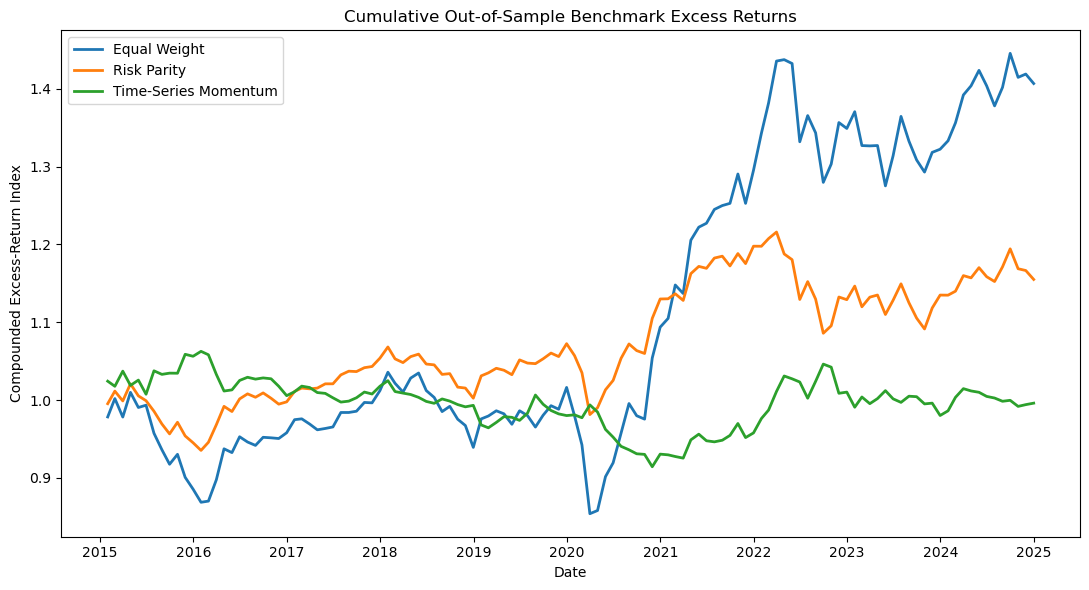

In [70]:
fig, ax = plt.subplots(
    figsize=(11, 6)
)

for strategy, path in (
    benchmark_paths.items()
):

    cumulative_wealth = (
        1
        + path['net_return']
    ).cumprod()

    ax.plot(
        cumulative_wealth.index,
        cumulative_wealth,
        label=strategy,
        linewidth=2
    )


ax.set_title(
    'Cumulative Out-of-Sample Benchmark Excess Returns'
)

ax.set_xlabel(
    'Date'
)

ax.set_ylabel(
    'Compounded Excess-Return Index'
)

ax.legend()

plt.tight_layout()

plt.show()

### 2.9 Forecasting Design Summary

The primary forecasting target is volatility-scaled monthly excess return. The five asset characteristics are timing-aligned and transformed into within-class monthly ranks. The baseline information sets contain 8 predictors using characteristics and class indicators, 12 predictors after adding global macro variables, and 18 predictors after adding complete curated country macro variables.

The main out-of-sample period is 2015-2024. Models are refit annually. The pre-specified reference design uses an expanding training window and a rolling five-year validation window, while a ten-year rolling training window is evaluated as an alternative. All monthly cross-sections remain intact when the sample is split.

Forecast performance is evaluated relative to zero and an expanding trailing historical mean calculated using all observations realized through completed prior months. Economic performance is evaluated relative to equal weight, risk parity, and time-series momentum portfolios. Portfolio weights are normalized to unit gross exposure, turnover is measured as the sum of absolute changes in target weights between consecutive months, and the primary transaction-cost assumption is 10 basis points per dollar traded, with 25- and 50-basis-point sensitivity checks.


## 3. Predictive Models and Out-of-Sample Forecasts

We now estimate four core forecasting models: OLS, Elastic Net, Random Forest, and Gradient Boosting. Each model is evaluated using the same CHAR, GLOBAL, and COUNTRY information sets and the same time-ordered out-of-sample windows defined above.

Hyperparameters are selected using the five-year validation period. After selection, the chosen specification is refit using the historical observations permitted by the expanding or rolling estimation scheme through the end of the year preceding the forecast. The following test year remains completely out of sample.

In [71]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.model_selection import ParameterGrid


RANDOM_STATE = 7034


MODEL_GRIDS = {

    'OLS': {},

    'Elastic Net': {
        'alpha': [
            0.001,
            0.01,
            0.1,
            0.3,
            1.0
        ],
        'l1_ratio': [
            0.1,
            0.5,
            0.9,
            1.0
        ]
    },

    'Random Forest': {
        'max_depth': [
            3,
            6
        ],
        'min_samples_leaf': [
            10,
            30
        ],
        'max_features': [
            0.5,
            1.0
        ]
    },

    'Gradient Boosting': {
        'n_estimators': [
            100,
            300
        ],
        'learning_rate': [
            0.03,
            0.10
        ],
        'max_depth': [
            1,
            2
        ]
    }
}


CORE_MODELS = list(
    MODEL_GRIDS.keys()
)

### 3.1 Model Specifications

OLS provides the basic linear benchmark. Elastic Net adds regularization to the linear model. Random Forest and Gradient Boosting allow nonlinear relationships and interactions between predictors.

The linear models standardize predictors within each estimation sample. Tree-based models use predictors in their existing units because their split rules do not require standardization.

In [72]:
def make_model(
    model_name,
    params=None
):

    if params is None:
        params = {}


    if model_name == 'OLS':

        return Pipeline([
            (
                'scaler',
                StandardScaler()
            ),
            (
                'model',
                LinearRegression()
            )
        ])


    if model_name == 'Elastic Net':

        return Pipeline([
            (
                'scaler',
                StandardScaler()
            ),
            (
                'model',
                ElasticNet(
                    alpha=params['alpha'],
                    l1_ratio=params['l1_ratio'],
                    max_iter=50000
                )
            )
        ])


    if model_name == 'Random Forest':

        return RandomForestRegressor(
            n_estimators=300,
            max_depth=params[
                'max_depth'
            ],
            min_samples_leaf=params[
                'min_samples_leaf'
            ],
            max_features=params[
                'max_features'
            ],
            random_state=
                RANDOM_STATE,
            n_jobs=-1
        )


    if model_name == 'Gradient Boosting':

        return GradientBoostingRegressor(
            n_estimators=params[
                'n_estimators'
            ],
            learning_rate=params[
                'learning_rate'
            ],
            max_depth=params[
                'max_depth'
            ],
            min_samples_leaf=20,
            random_state=
                RANDOM_STATE
        )


    raise ValueError(
        f"Unknown model: {model_name}"
    )

### 3.2 Hyperparameter Selection

For each model, information set, estimation scheme, and test year, candidate specifications are fitted using the training block and compared on the subsequent five-year validation period. The specification with the lowest validation mean squared error is selected.

Validation loss is calculated by first averaging squared forecast errors across assets within each month and then averaging across months.

In [73]:
def tune_model(
    model_name,
    training,
    validation,
    features
):

    rows = []


    for params in ParameterGrid(
        MODEL_GRIDS[model_name]
    ):

        model = make_model(
            model_name,
            params
        )


        model.fit(
            training[features],
            training['target_scaled']
        )


        prediction = model.predict(
            validation[features]
        )


        validation_mse = monthly_mse(
            validation['target_scaled'],
            prediction,
            validation['date']
        )


        rows.append({
            'Parameters':
                params,

            'Validation MSE':
                validation_mse
        })


    tuning_table = pd.DataFrame(
        rows
    )


    best_row = (
        tuning_table[
            'Validation MSE'
        ]
        .idxmin()
    )


    best_params = (
        tuning_table.loc[
            best_row,
            'Parameters'
        ]
    )


    best_validation_mse = (
        tuning_table.loc[
            best_row,
            'Validation MSE'
        ]
    )


    return (
        best_params,
        best_validation_mse,
        tuning_table
    )

### 3.3 Final Historical Estimation Sample

After hyperparameters have been selected, the chosen model is refit before producing the test-year forecast. Under the expanding scheme, the final model uses all available observations through the end of the preceding year. Under the rolling scheme, it uses the most recent ten years.

In [74]:
def get_final_estimation_sample(
    dataframe,
    test_year,
    scheme='expanding'
):

    end_year = (
        test_year - 1
    )


    if scheme == 'expanding':

        start_year = (
            dataframe[
                'date'
            ].dt.year.min()
        )


    elif scheme == 'rolling':

        start_year = (
            test_year
            - ROLLING_TRAIN_YEARS
        )


    else:

        raise ValueError(
            "scheme must be "
            "'expanding' or 'rolling'"
        )


    estimation = dataframe[
        dataframe[
            'date'
        ].dt.year.between(
            start_year,
            end_year
        )
    ].copy()


    return estimation

### 3.4 Core Out-of-Sample Forecasting Exercise

The following procedure is repeated for every estimation scheme, information set, model, and test year from 2015 through 2024. Hyperparameters are selected without using the test year, the selected model is refit using the appropriate historical sample, and forecasts are stored for later evaluation and portfolio construction.

In [75]:
prediction_records = []
selected_parameter_records = []
all_tuning_records = []


for scheme in [
    'expanding',
    'rolling'
]:

    for info_name, features in (
        feature_sets.items()
    ):

        for model_name in CORE_MODELS:

            print(
                f"Running: "
                f"{scheme} | "
                f"{info_name} | "
                f"{model_name}"
            )


            for test_year in TEST_YEARS:

                (
                    tuning_train,
                    validation,
                    test
                ) = get_forecast_window(
                    forecast_data,
                    test_year,
                    scheme
                )


                (
                    best_params,
                    best_validation_mse,
                    tuning_table
                ) = tune_model(
                    model_name,
                    tuning_train,
                    validation,
                    features
                )


                tuning_table = (
                    tuning_table.copy()
                )

                tuning_table[
                    'Scheme'
                ] = scheme

                tuning_table[
                    'Information Set'
                ] = info_name

                tuning_table[
                    'Model'
                ] = model_name

                tuning_table[
                    'Test Year'
                ] = test_year


                all_tuning_records.append(
                    tuning_table
                )


                selected_parameter_records.append({
                    'Scheme':
                        scheme,

                    'Information Set':
                        info_name,

                    'Model':
                        model_name,

                    'Test Year':
                        test_year,

                    'Parameters':
                        str(best_params),

                    'Validation MSE':
                        best_validation_mse
                })


                final_estimation = (
                    get_final_estimation_sample(
                        forecast_data,
                        test_year,
                        scheme
                    )
                )


                final_model = make_model(
                    model_name,
                    best_params
                )


                final_model.fit(
                    final_estimation[
                        features
                    ],
                    final_estimation[
                        'target_scaled'
                    ]
                )


                test_prediction = (
                    final_model.predict(
                        test[features]
                    )
                )


                test_output = test[
                    [
                        'date',
                        'asset_id',
                        'asset_class',
                        'country',
                        'target_scaled',
                        'excess_return',
                        'x5'
                    ]
                ].copy()


                test_output[
                    'pred_scaled'
                ] = test_prediction


                test_output[
                    'pred_raw'
                ] = (
                    test_output[
                        'pred_scaled'
                    ]
                    *
                    test_output['x5']
                )


                test_output[
                    'Scheme'
                ] = scheme

                test_output[
                    'Information Set'
                ] = info_name

                test_output[
                    'Model'
                ] = model_name

                test_output[
                    'Test Year'
                ] = test_year


                prediction_records.append(
                    test_output
                )

Running: expanding | CHAR | OLS
Running: expanding | CHAR | Elastic Net
Running: expanding | CHAR | Random Forest
Running: expanding | CHAR | Gradient Boosting
Running: expanding | GLOBAL | OLS
Running: expanding | GLOBAL | Elastic Net
Running: expanding | GLOBAL | Random Forest
Running: expanding | GLOBAL | Gradient Boosting
Running: expanding | COUNTRY | OLS
Running: expanding | COUNTRY | Elastic Net
Running: expanding | COUNTRY | Random Forest
Running: expanding | COUNTRY | Gradient Boosting
Running: rolling | CHAR | OLS
Running: rolling | CHAR | Elastic Net
Running: rolling | CHAR | Random Forest
Running: rolling | CHAR | Gradient Boosting
Running: rolling | GLOBAL | OLS
Running: rolling | GLOBAL | Elastic Net
Running: rolling | GLOBAL | Random Forest
Running: rolling | GLOBAL | Gradient Boosting
Running: rolling | COUNTRY | OLS
Running: rolling | COUNTRY | Elastic Net
Running: rolling | COUNTRY | Random Forest
Running: rolling | COUNTRY | Gradient Boosting


In [76]:
model_predictions = pd.concat(
    prediction_records,
    ignore_index=True
)


selected_hyperparameters = (
    pd.DataFrame(
        selected_parameter_records
    )
)


tuning_results = pd.concat(
    all_tuning_records,
    ignore_index=True
)


print(
    "Prediction rows:",
    len(model_predictions)
)

print(
    "Unique test months:",
    model_predictions[
        'date'
    ].nunique()
)

print(
    "Models:",
    model_predictions[
        'Model'
    ].unique()
)

Prediction rows: 144000
Unique test months: 120
Models: <ArrowStringArray>
['OLS', 'Elastic Net', 'Random Forest', 'Gradient Boosting']
Length: 4, dtype: str


### 3.5 Forecast Ensemble

In addition to the four individual models, we construct a simple equal-weight ensemble of Elastic Net, Random Forest, and Gradient Boosting forecasts. No additional parameters are estimated. The ensemble tests whether the different model families contain complementary predictive information.

In [77]:
ensemble_models = [
    'Elastic Net',
    'Random Forest',
    'Gradient Boosting'
]


ensemble_base = (
    model_predictions[
        model_predictions[
            'Model'
        ].isin(
            ensemble_models
        )
    ]
    .copy()
)


ensemble_prediction = (
    ensemble_base
    .groupby(
        [
            'Scheme',
            'Information Set',
            'Test Year',
            'date',
            'asset_id'
        ],
        as_index=False
    )
    .agg(
        pred_scaled=(
            'pred_scaled',
            'mean'
        ),

        n_models=(
            'Model',
            'nunique'
        )
    )
)


# Every ensemble prediction should contain
# all three component models.
assert (
    ensemble_prediction[
        'n_models'
    ]
    .eq(3)
    .all()
)

In [78]:
prediction_metadata = (
    model_predictions[
        [
            'Scheme',
            'Information Set',
            'Test Year',
            'date',
            'asset_id',
            'asset_class',
            'country',
            'target_scaled',
            'excess_return',
            'x5'
        ]
    ]
    .drop_duplicates()
)


ensemble_prediction = (
    ensemble_prediction
    .merge(
        prediction_metadata,
        on=[
            'Scheme',
            'Information Set',
            'Test Year',
            'date',
            'asset_id'
        ],
        how='left'
    )
)


ensemble_prediction[
    'Model'
] = 'Ensemble'


ensemble_prediction[
    'pred_raw'
] = (
    ensemble_prediction[
        'pred_scaled'
    ]
    *
    ensemble_prediction['x5']
)


ensemble_prediction = (
    ensemble_prediction[
        model_predictions.columns
    ]
)


model_predictions = pd.concat(
    [
        model_predictions,
        ensemble_prediction
    ],
    ignore_index=True
)


print(
    model_predictions[
        'Model'
    ].unique()
)

<ArrowStringArray>
['OLS', 'Elastic Net', 'Random Forest', 'Gradient Boosting', 'Ensemble']
Length: 5, dtype: str


### 3.6 Out-of-Sample Forecast Evaluation

Forecasts are compared with both previously defined no-model benchmarks: zero and the expanding historical mean. Performance is measured using mean squared error and out-of-sample R-squared. Positive out-of-sample R-squared indicates an improvement over the corresponding benchmark.

In [79]:
benchmark_lookup = (
    forecast_benchmarks[
        [
            'date',
            'asset_id',
            'pred_zero',
            'pred_trailing_mean'
        ]
    ]
    .drop_duplicates()
)


model_predictions = (
    model_predictions
    .merge(
        benchmark_lookup,
        on=[
            'date',
            'asset_id'
        ],
        how='left'
    )
)


assert (
    model_predictions[
        [
            'pred_zero',
            'pred_trailing_mean'
        ]
    ]
    .notna()
    .all()
    .all()
)

In [80]:
def prediction_summary(
    dataframe
):

    actual = (
        dataframe[
            'target_scaled'
        ]
        .to_numpy()
    )

    prediction = (
        dataframe[
            'pred_scaled'
        ]
        .to_numpy()
    )

    zero_benchmark = (
        dataframe[
            'pred_zero'
        ]
        .to_numpy()
    )

    mean_benchmark = (
        dataframe[
            'pred_trailing_mean'
        ]
        .to_numpy()
    )


    return {

        'Months':
            dataframe[
                'date'
            ].nunique(),

        'Observations':
            len(dataframe),

        'MSE':
            monthly_mse(
                actual,
                prediction,
                dataframe['date']
            ),

        'OOS R2 vs Zero':
            oos_r2(
                actual,
                prediction,
                zero_benchmark
            ),

        'OOS R2 vs Trailing Mean':
            oos_r2(
                actual,
                prediction,
                mean_benchmark
            )
    }

### 3.7 Overall Forecasting Results

The next table reports out-of-sample forecasting performance over the full 2015-2024 test period for every model, information set, and estimation scheme.

In [81]:
summary_rows = []


for (
    scheme,
    info_name,
    model_name
), group in model_predictions.groupby(
    [
        'Scheme',
        'Information Set',
        'Model'
    ]
):

    metrics = (
        prediction_summary(
            group
        )
    )


    metrics.update({
        'Scheme':
            scheme,

        'Information Set':
            info_name,

        'Model':
            model_name
    })


    summary_rows.append(
        metrics
    )


model_oos_summary = (
    pd.DataFrame(
        summary_rows
    )
    [
        [
            'Scheme',
            'Information Set',
            'Model',
            'Months',
            'Observations',
            'MSE',
            'OOS R2 vs Zero',
            'OOS R2 vs Trailing Mean'
        ]
    ]
    .sort_values(
        [
            'Scheme',
            'Information Set',
            'OOS R2 vs Zero'
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
)


display(
    model_oos_summary
    .round(4)
)

,Scheme,Information Set,Model,Months,Observations,MSE,OOS R2 vs Zero,OOS R2 vs Trailing Mean
0,expanding,CHAR,Elastic Net,120,6000,1.2135,-0.0004,-0.0001
1,expanding,CHAR,Ensemble,120,6000,1.2143,-0.0010,-0.0008
2,expanding,CHAR,Gradient Boosting,120,6000,1.2154,-0.0020,-0.0017
4,expanding,CHAR,Random Forest,120,6000,1.2157,-0.0022,-0.0019
3,expanding,CHAR,OLS,120,6000,1.2169,-0.0032,-0.0030
5,expanding,COUNTRY,Elastic Net,120,6000,1.2134,-0.0003,-0.0001
8,expanding,COUNTRY,OLS,120,6000,1.2325,-0.0161,-0.0158
6,expanding,COUNTRY,Ensemble,120,6000,1.2396,-0.0219,-0.0216
7,expanding,COUNTRY,Gradient Boosting,120,6000,1.2451,-0.0264,-0.0262
9,expanding,COUNTRY,Random Forest,120,6000,1.2860,-0.0602,-0.0599


### 3.8 Forecast Performance by Asset Class

Because the four asset classes have different return behavior and dependence structures, we also evaluate each forecasting specification separately within Classes A, B, C, and D.

In [82]:
class_summary_rows = []


for (
    scheme,
    info_name,
    model_name,
    asset_class
), group in model_predictions.groupby(
    [
        'Scheme',
        'Information Set',
        'Model',
        'asset_class'
    ]
):

    metrics = (
        prediction_summary(
            group
        )
    )


    metrics.update({
        'Scheme':
            scheme,

        'Information Set':
            info_name,

        'Model':
            model_name,

        'Class':
            asset_class
    })


    class_summary_rows.append(
        metrics
    )


class_oos_summary = (
    pd.DataFrame(
        class_summary_rows
    )
    [
        [
            'Scheme',
            'Information Set',
            'Model',
            'Class',
            'MSE',
            'OOS R2 vs Zero',
            'OOS R2 vs Trailing Mean'
        ]
    ]
    .sort_values(
        [
            'Scheme',
            'Information Set',
            'Model',
            'Class'
        ]
    )
)


display(
    class_oos_summary
    .round(4)
)

,Scheme,Information Set,Model,Class,MSE,OOS R2 vs Zero,OOS R2 vs Trailing Mean
0,expanding,CHAR,Elastic Net,A,1.2241,0.0014,-0.0007
1,expanding,CHAR,Elastic Net,B,1.1423,-0.0183,0.0014
2,expanding,CHAR,Elastic Net,C,1.1885,0.0110,-0.0022
3,expanding,CHAR,Elastic Net,D,1.2875,-0.0026,0.0027
4,expanding,CHAR,Ensemble,A,1.2235,0.0019,-0.0002
...,...,...,...,...,...,...,...
115,rolling,GLOBAL,OLS,D,1.3279,-0.0341,-0.0287
116,rolling,GLOBAL,Random Forest,A,1.2459,-0.0164,-0.0185
117,rolling,GLOBAL,Random Forest,B,1.1631,-0.0369,-0.0168
118,rolling,GLOBAL,Random Forest,C,1.2449,-0.0359,-0.0497


### 3.9 Hyperparameter Selection

We inspect how often each hyperparameter combination is selected across forecast years. This provides a diagnostic of whether model selection is stable and whether the chosen values repeatedly lie at the boundary of the pre-specified grids.

In [83]:
parameter_selection_frequency = (
    selected_hyperparameters[
        selected_hyperparameters[
            'Model'
        ] != 'OLS'
    ]
    .groupby(
        [
            'Scheme',
            'Information Set',
            'Model',
            'Parameters'
        ]
    )
    .size()
    .rename(
        'Times Selected'
    )
    .reset_index()
    .sort_values(
        [
            'Scheme',
            'Information Set',
            'Model',
            'Times Selected'
        ],
        ascending=[
            True,
            True,
            True,
            False
        ]
    )
)


display(
    parameter_selection_frequency
)

,Scheme,Information Set,Model,Parameters,Times Selected
2,expanding,CHAR,Elastic Net,"{'alpha': 0.1, 'l1_ratio': 0.9}",4
1,expanding,CHAR,Elastic Net,"{'alpha': 0.1, 'l1_ratio': 0.5}",3
3,expanding,CHAR,Elastic Net,"{'alpha': 0.3, 'l1_ratio': 0.1}",2
0,expanding,CHAR,Elastic Net,"{'alpha': 0.01, 'l1_ratio': 1.0}",1
4,expanding,CHAR,Gradient Boosting,"{'learning_rate': 0.03, 'max_depth': 1, 'n_est...",5
...,...,...,...,...,...
57,rolling,GLOBAL,Gradient Boosting,"{'learning_rate': 0.03, 'max_depth': 1, 'n_est...",1
59,rolling,GLOBAL,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 1, 'n_esti...",1
61,rolling,GLOBAL,Random Forest,"{'max_depth': 3, 'max_features': 0.5, 'min_sam...",5
60,rolling,GLOBAL,Random Forest,"{'max_depth': 3, 'max_features': 0.5, 'min_sam...",4


### 3.10 Expanding-Window Reference Comparison

The expanding-window specification was the pre-specified reference forecasting design. The following compact table expresses out-of-sample R-squared in percentage points to make differences across models and information sets easier to compare. The rolling-window results are retained in the full results table and in the information-set comparison below.


In [84]:
expanding_results = (
    model_oos_summary[
        model_oos_summary[
            'Scheme'
        ] == 'expanding'
    ]
    [
        [
            'Information Set',
            'Model',
            'OOS R2 vs Zero',
            'OOS R2 vs Trailing Mean'
        ]
    ]
    .copy()
)


expanding_results[
    'OOS R2 vs Zero (%)'
] = (
    100
    * expanding_results[
        'OOS R2 vs Zero'
    ]
)


expanding_results[
    'OOS R2 vs Trailing Mean (%)'
] = (
    100
    * expanding_results[
        'OOS R2 vs Trailing Mean'
    ]
)


display(
    expanding_results[
        [
            'Information Set',
            'Model',
            'OOS R2 vs Zero (%)',
            'OOS R2 vs Trailing Mean (%)'
        ]
    ]
    .round(3)
)

,Information Set,Model,OOS R2 vs Zero (%),OOS R2 vs Trailing Mean (%)
0,CHAR,Elastic Net,-0.038,-0.013
1,CHAR,Ensemble,-0.102,-0.078
2,CHAR,Gradient Boosting,-0.197,-0.172
4,CHAR,Random Forest,-0.220,-0.195
3,CHAR,OLS,-0.321,-0.296
5,COUNTRY,Elastic Net,-0.030,-0.005
8,COUNTRY,OLS,-1.609,-1.584
6,COUNTRY,Ensemble,-2.189,-2.163
7,COUNTRY,Gradient Boosting,-2.641,-2.615
9,COUNTRY,Random Forest,-6.015,-5.989


In [85]:
macro_comparison = (
    model_oos_summary[
        [
            'Scheme',
            'Model',
            'Information Set',
            'OOS R2 vs Zero'
        ]
    ]
    .pivot(
        index=[
            'Scheme',
            'Model'
        ],
        columns=
            'Information Set',
        values=
            'OOS R2 vs Zero'
    )
    .reset_index()
)


macro_comparison[
    'GLOBAL - CHAR'
] = (
    macro_comparison['GLOBAL']
    - macro_comparison['CHAR']
)


macro_comparison[
    'COUNTRY - GLOBAL'
] = (
    macro_comparison['COUNTRY']
    - macro_comparison['GLOBAL']
)


macro_comparison[
    'COUNTRY - CHAR'
] = (
    macro_comparison['COUNTRY']
    - macro_comparison['CHAR']
)


for column in [
    'CHAR',
    'GLOBAL',
    'COUNTRY',
    'GLOBAL - CHAR',
    'COUNTRY - GLOBAL',
    'COUNTRY - CHAR'
]:

    macro_comparison[column] *= 100


display(
    macro_comparison
    .round(3)
)

Information Set,Scheme,Model,CHAR,COUNTRY,GLOBAL,GLOBAL - CHAR,COUNTRY - GLOBAL,COUNTRY - CHAR
0,expanding,Elastic Net,-0.038,-0.030,-0.030,0.008,0.000,0.008
1,expanding,Ensemble,-0.102,-2.189,-1.794,-1.692,-0.394,-2.086
2,expanding,Gradient Boosting,-0.197,-2.641,-2.641,-2.444,0.000,-2.444
3,expanding,OLS,-0.321,-1.609,-1.609,-1.288,-0.000,-1.288
4,expanding,Random Forest,-0.220,-6.015,-4.524,-4.304,-1.491,-5.795
5,rolling,Elastic Net,0.142,0.464,0.467,0.325,-0.003,0.322
6,rolling,Ensemble,0.148,-0.499,-0.701,-0.849,0.202,-0.646
7,rolling,Gradient Boosting,-0.035,-1.068,-1.788,-1.753,0.720,-1.033
8,rolling,OLS,-0.071,-0.748,-0.718,-0.647,-0.031,-0.677
9,rolling,Random Forest,0.116,-2.765,-2.774,-2.890,0.009,-2.881


### 3.11 Characteristic–Macro Interaction Model

The baseline results show that global macroeconomic information improves forecasting performance for the rolling-window Elastic Net, while country-specific macro variables add little additional predictive power. I therefore test whether global macro conditions also change the predictive relationship between asset characteristics and future returns.

The interaction specification retains all characteristic, asset-class, and global macro main effects and adds every pairwise interaction between the five asset characteristics and four global macro variables. Elastic Net regularization is used to shrink interactions that do not contribute useful predictive information. All predictors, including interaction terms, continue to use only information available at the forecast date.

In [86]:
interaction_data = (
    forecast_data.copy()
)


interaction_features = []


for char_feature in characteristic_features:

    for global_feature in global_features:

        interaction_name = (
            f'{char_feature}_x_{global_feature}'
        )


        interaction_data[
            interaction_name
        ] = (
            interaction_data[
                char_feature
            ]
            *
            interaction_data[
                global_feature
            ]
        )


        interaction_features.append(
            interaction_name
        )


interaction_model_features = (
    characteristic_features
    + class_features
    + global_features
    + interaction_features
)


print(
    "Characteristics:",
    len(characteristic_features)
)

print(
    "Class indicators:",
    len(class_features)
)

print(
    "Global macro:",
    len(global_features)
)

print(
    "Interactions:",
    len(interaction_features)
)

print(
    "Total predictors:",
    len(interaction_model_features)
)

Characteristics: 5
Class indicators: 3
Global macro: 4
Interactions: 20
Total predictors: 32


In [87]:
interaction_audit = pd.DataFrame({
    'Value': [
        len(interaction_data),
        interaction_data[
            'date'
        ].nunique(),
        interaction_data[
            interaction_model_features
        ].isna().sum().sum()
    ]
}, index=[
    'Observations',
    'Months',
    'Missing predictor values'
])


display(
    interaction_audit
)

,Value
Observations,14950
Months,299
Missing predictor values,0


#### Out-of-Sample Interaction Forecasts

The interaction model is evaluated under the same expanding- and rolling-window designs used for the core models. Hyperparameters are selected on the five-year validation block using the expanded Elastic Net grid established above. The selected specification is then refit on the permissible historical sample before forecasting the following year.

In [88]:
interaction_prediction_records = []
interaction_parameter_records = []
interaction_tuning_records = []
interaction_coefficient_records = []


In [89]:
INTERACTION_MAX_ITER = 10000


def make_interaction_enet(
    params
):

    return Pipeline([
        (
            'scaler',
            StandardScaler()
        ),
        (
            'model',
            ElasticNet(
                alpha=params['alpha'],
                l1_ratio=params['l1_ratio'],
                max_iter=INTERACTION_MAX_ITER,
                tol=1e-4,
                selection='random',
                random_state=RANDOM_STATE,
                precompute=True
            )
        )
    ])


def tune_interaction_enet(
    training,
    validation,
    features
):

    grid = list(
        ParameterGrid(
            MODEL_GRIDS[
                'Elastic Net'
            ]
        )
    )

    rows = []


    for i, params in enumerate(
        grid,
        start=1
    ):

        print(
            f"    Candidate "
            f"{i}/{len(grid)}"
        )


        model = make_interaction_enet(
            params
        )


        model.fit(
            training[features],
            training[
                'target_scaled'
            ]
        )


        n_iter = (
            model
            .named_steps[
                'model'
            ]
            .n_iter_
        )


        prediction = model.predict(
            validation[features]
        )


        validation_mse = (
            monthly_mse(
                validation[
                    'target_scaled'
                ],
                prediction,
                validation['date']
            )
        )


        rows.append({
            'Parameters':
                params,

            'Validation MSE':
                validation_mse,

            'Iterations':
                n_iter,

            'Converged':
                (
                    n_iter
                    < INTERACTION_MAX_ITER
                )
        })


    tuning_table = pd.DataFrame(
        rows
    )


    usable = tuning_table[
        tuning_table[
            'Converged'
        ]
    ].copy()


    if len(usable) == 0:

        raise RuntimeError(
            "No Elastic Net "
            "candidate converged."
        )


    best_row = (
        usable[
            'Validation MSE'
        ]
        .idxmin()
    )


    best_params = (
        usable.loc[
            best_row,
            'Parameters'
        ]
    )


    best_validation_mse = (
        usable.loc[
            best_row,
            'Validation MSE'
        ]
    )


    return (
        best_params,
        best_validation_mse,
        tuning_table
    )

In [90]:
for scheme in [
    'expanding',
    'rolling'
]:

    for test_year in TEST_YEARS:

        print(
            f"\nRunning interaction model: "
            f"{scheme} | {test_year}"
        )

        (
            tuning_train,
            validation,
            test
        ) = get_forecast_window(
            interaction_data,
            test_year,
            scheme
        )

        (
            best_params,
            best_validation_mse,
            tuning_table
        ) = tune_interaction_enet(
            tuning_train,
            validation,
            interaction_model_features
        )

        print(
            "    Best parameters:",
            best_params
        )

        final_estimation = (
            get_final_estimation_sample(
                interaction_data,
                test_year,
                scheme
            )
        )

        final_model = (
            make_interaction_enet(
                best_params
            )
        )

        final_model.fit(
            final_estimation[
                interaction_model_features
            ],
            final_estimation[
                'target_scaled'
            ]
        )

        final_iterations = (
            final_model
            .named_steps['model']
            .n_iter_
        )

        print(
            "    Final fit iterations:",
            final_iterations
        )

        if final_iterations >= INTERACTION_MAX_ITER:
            raise RuntimeError(
                f"Final interaction fit did not converge "
                f"for {scheme} {test_year}."
            )

        test_prediction = (
            final_model.predict(
                test[
                    interaction_model_features
                ]
            )
        )

        test_output = test[
            [
                'date',
                'asset_id',
                'asset_class',
                'country',
                'target_scaled',
                'excess_return',
                'x5'
            ]
        ].copy()

        test_output['pred_scaled'] = (
            test_prediction
        )

        test_output['pred_raw'] = (
            test_output['pred_scaled']
            * test_output['x5']
        )

        test_output['Scheme'] = scheme
        test_output['Information Set'] = 'GLOBAL'
        test_output['Model'] = 'Elastic Net + Interactions'
        test_output['Test Year'] = test_year

        interaction_prediction_records.append(
            test_output
        )

        tuning_table = tuning_table.copy()
        tuning_table['Scheme'] = scheme
        tuning_table['Test Year'] = test_year

        interaction_tuning_records.append(
            tuning_table
        )

        interaction_parameter_records.append({
            'Scheme': scheme,
            'Test Year': test_year,
            'Parameters': str(best_params),
            'Validation MSE': best_validation_mse
        })

        coefficients = (
            final_model
            .named_steps['model']
            .coef_
        )

        for feature, coefficient in zip(
            interaction_model_features,
            coefficients
        ):
            interaction_coefficient_records.append({
                'Scheme': scheme,
                'Test Year': test_year,
                'Feature': feature,
                'Coefficient': coefficient
            })

        # Lightweight checkpoint after each completed year.
        pd.concat(
            interaction_prediction_records,
            ignore_index=True
        ).to_csv(
            'interaction_predictions_checkpoint.csv',
            index=False
        )

        print(
            f"    Saved checkpoint: "
            f"{scheme} | {test_year}"
        )



Running interaction model: expanding | 2015
    Candidate 1/20
    Candidate 2/20
    Candidate 3/20
    Candidate 4/20
    Candidate 5/20
    Candidate 6/20
    Candidate 7/20
    Candidate 8/20
    Candidate 9/20
    Candidate 10/20
    Candidate 11/20
    Candidate 12/20
    Candidate 13/20
    Candidate 14/20
    Candidate 15/20
    Candidate 16/20
    Candidate 17/20
    Candidate 18/20
    Candidate 19/20
    Candidate 20/20
    Best parameters: {'alpha': 0.3, 'l1_ratio': 0.5}
    Final fit iterations: 0
    Saved checkpoint: expanding | 2015

Running interaction model: expanding | 2016
    Candidate 1/20
    Candidate 2/20
    Candidate 3/20
    Candidate 4/20
    Candidate 5/20
    Candidate 6/20
    Candidate 7/20
    Candidate 8/20
    Candidate 9/20
    Candidate 10/20
    Candidate 11/20
    Candidate 12/20
    Candidate 13/20
    Candidate 14/20
    Candidate 15/20
    Candidate 16/20
    Candidate 17/20
    Candidate 18/20
    Candidate 19/20
    Candidate 20/20
    Best

In [91]:
interaction_predictions = pd.concat(
    interaction_prediction_records,
    ignore_index=True
)


interaction_hyperparameters = (
    pd.DataFrame(
        interaction_parameter_records
    )
)


interaction_tuning_results = pd.concat(
    interaction_tuning_records,
    ignore_index=True
)


interaction_coefficients = (
    pd.DataFrame(
        interaction_coefficient_records
    )
)


print(
    "Interaction predictions:",
    len(interaction_predictions)
)

print(
    "Test months:",
    interaction_predictions[
        'date'
    ].nunique()
)

Interaction predictions: 12000
Test months: 120


In [92]:
interaction_predictions = (
    interaction_predictions
    .merge(
        benchmark_lookup,
        on=[
            'date',
            'asset_id'
        ],
        how='left'
    )
)


assert (
    interaction_predictions[
        [
            'pred_zero',
            'pred_trailing_mean'
        ]
    ]
    .notna()
    .all()
    .all()
)

#### Interaction Model Performance

The interaction model is compared directly with the baseline GLOBAL Elastic Net. Because both specifications use the same underlying characteristic and global macro information, the difference in out-of-sample performance isolates whether explicitly allowing macro conditions to modify characteristic effects improves forecasting accuracy.

In [93]:
interaction_summary_rows = []


for scheme, group in (
    interaction_predictions
    .groupby('Scheme')
):

    metrics = prediction_summary(
        group
    )


    metrics[
        'Scheme'
    ] = scheme


    interaction_summary_rows.append(
        metrics
    )


interaction_oos_summary = (
    pd.DataFrame(
        interaction_summary_rows
    )
)


display(
    interaction_oos_summary[
        [
            'Scheme',
            'Months',
            'Observations',
            'MSE',
            'OOS R2 vs Zero',
            'OOS R2 vs Trailing Mean'
        ]
    ]
    .round(4)
)

,Scheme,Months,Observations,MSE,OOS R2 vs Zero,OOS R2 vs Trailing Mean
0,expanding,120,6000,1.2289,-0.0131,-0.0128
1,rolling,120,6000,1.2075,0.0046,0.0048


In [94]:
baseline_global_enet = (
    model_oos_summary[
        (
            model_oos_summary[
                'Model'
            ] == 'Elastic Net'
        )
        &
        (
            model_oos_summary[
                'Information Set'
            ] == 'GLOBAL'
        )
    ]
    [
        [
            'Scheme',
            'OOS R2 vs Zero',
            'OOS R2 vs Trailing Mean'
        ]
    ]
    .copy()
)


baseline_global_enet = (
    baseline_global_enet
    .rename(
        columns={
            'OOS R2 vs Zero':
                'Baseline R2 vs Zero',

            'OOS R2 vs Trailing Mean':
                'Baseline R2 vs Mean'
        }
    )
)


interaction_comparison = (
    interaction_oos_summary[
        [
            'Scheme',
            'OOS R2 vs Zero',
            'OOS R2 vs Trailing Mean'
        ]
    ]
    .rename(
        columns={
            'OOS R2 vs Zero':
                'Interaction R2 vs Zero',

            'OOS R2 vs Trailing Mean':
                'Interaction R2 vs Mean'
        }
    )
    .merge(
        baseline_global_enet,
        on='Scheme',
        how='left'
    )
)


interaction_comparison[
    'Interaction Gain vs Zero'
] = (
    interaction_comparison[
        'Interaction R2 vs Zero'
    ]
    -
    interaction_comparison[
        'Baseline R2 vs Zero'
    ]
)


interaction_comparison[
    'Interaction Gain vs Mean'
] = (
    interaction_comparison[
        'Interaction R2 vs Mean'
    ]
    -
    interaction_comparison[
        'Baseline R2 vs Mean'
    ]
)


r2_columns = [
    'Interaction R2 vs Zero',
    'Baseline R2 vs Zero',
    'Interaction Gain vs Zero',
    'Interaction R2 vs Mean',
    'Baseline R2 vs Mean',
    'Interaction Gain vs Mean'
]


interaction_comparison[
    r2_columns
] = (
    100
    * interaction_comparison[
        r2_columns
    ]
)


display(
    interaction_comparison
    .round(3)
)

,Scheme,Interaction R2 vs Zero,Interaction R2 vs Mean,Baseline R2 vs Zero,Baseline R2 vs Mean,Interaction Gain vs Zero,Interaction Gain vs Mean
0,expanding,-1.308,-1.283,-0.030,-0.005,-1.278,-1.278
1,rolling,0.459,0.484,0.467,0.492,-0.008,-0.008


#### Interaction Selection Stability

Because Elastic Net can set coefficients exactly to zero, the frequency with which an interaction survives regularization provides a simple measure of stability. The following diagnostic counts the number of annual estimation windows in which each interaction receives a nonzero coefficient.

In [95]:
interaction_only_coefficients = (
    interaction_coefficients[
        interaction_coefficients[
            'Feature'
        ].isin(
            interaction_features
        )
    ]
    .copy()
)


interaction_only_coefficients[
    'Selected'
] = (
    interaction_only_coefficients[
        'Coefficient'
    ]
    .abs()
    > 1e-10
)


interaction_selection = (
    interaction_only_coefficients
    .groupby(
        [
            'Scheme',
            'Feature'
        ]
    )
    .agg(
        Times_Selected=(
            'Selected',
            'sum'
        ),

        Average_Coefficient=(
            'Coefficient',
            'mean'
        )
    )
    .reset_index()
    .sort_values(
        [
            'Scheme',
            'Times_Selected'
        ],
        ascending=[
            True,
            False
        ]
    )
)


display(
    interaction_selection
)

,Scheme,Feature,Times_Selected,Average_Coefficient
0,expanding,char_x1_x_global_x6,1,0.004335
1,expanding,char_x1_x_global_x7,1,-0.004196
2,expanding,char_x1_x_global_x8,1,-0.000186
3,expanding,char_x1_x_global_x9,1,0.002563
4,expanding,char_x2_x_global_x6,1,0.003124
5,expanding,char_x2_x_global_x7,1,-0.012249
6,expanding,char_x2_x_global_x8,1,0.005619
7,expanding,char_x2_x_global_x9,1,-0.000494
8,expanding,char_x3_x_global_x6,1,0.000995
9,expanding,char_x3_x_global_x7,1,0.005001


In [96]:
interaction_parameter_frequency = (
    interaction_hyperparameters
    .groupby(
        [
            'Scheme',
            'Parameters'
        ]
    )
    .size()
    .rename(
        'Times Selected'
    )
    .reset_index()
    .sort_values(
        [
            'Scheme',
            'Times Selected'
        ],
        ascending=[
            True,
            False
        ]
    )
)


display(
    interaction_parameter_frequency
)

,Scheme,Parameters,Times Selected
1,expanding,"{'alpha': 0.1, 'l1_ratio': 0.9}",5
2,expanding,"{'alpha': 0.3, 'l1_ratio': 0.5}",4
0,expanding,"{'alpha': 0.001, 'l1_ratio': 0.1}",1
4,rolling,"{'alpha': 0.1, 'l1_ratio': 0.9}",4
6,rolling,"{'alpha': 0.3, 'l1_ratio': 0.5}",4
3,rolling,"{'alpha': 0.1, 'l1_ratio': 0.1}",1
5,rolling,"{'alpha': 0.3, 'l1_ratio': 0.1}",1


### 3.12 Extended Macroeconomic Screening and Boosted Trees

The baseline results indicate that global macroeconomic variables improve the rolling-window Elastic Net, while the curated country variables add little additional predictive information. I therefore examine whether the wider `x17`–`x164` country-level macro panel contains additional useful signals.

Because the extended panel is high-dimensional and intentionally uncurated, I use a two-stage procedure. First, Elastic Net screens the extended macro variables while conditioning on the core characteristic, class, and global-macro predictors. Second, Gradient Boosting is estimated using all core predictors plus only the extended macro variables that survive the screening step.

Feature screening and model selection are performed using only information available before each test year. The final 2015–2024 forecasts therefore remain genuinely out of sample.

In [97]:
excluded_extended = set(
    incomplete_extended_cols
)


excluded_extended.update(
    exact_curated_duplicates[
        'Extended Variable'
    ].tolist()
)


excluded_extended.update(
    exact_global_duplicates[
        'Extended Variable'
    ].tolist()
)


excluded_extended.update(
    constant_variables[
        'Variable'
    ].tolist()
)


clean_extended_variables = [
    f'x{i}'
    for i in range(17, 165)
    if f'x{i}' not in excluded_extended
]


print(
    "Original extended variables:",
    148
)

print(
    "Excluded variables:",
    len(excluded_extended)
)

print(
    "Clean extended variables:",
    len(clean_extended_variables)
)

Original extended variables: 148
Excluded variables: 18
Clean extended variables: 130


#### Timing and Cross-Country Transformation

Each extended country variable is lagged by one month and then ranked across the 12 countries at each date, using the same transformation as the curated country variables. The ranks are mapped to the interval from -1 to 1.

Assets in Classes B, C, and D receive the lagged macro rank of their associated country. Class A has no natural country exposure, so its extended country-macro predictors are set to zero, the neutral midpoint of the rank transformation.

In [98]:
extended_lagged = (
    mac_x
    .sort_values(
        ['country', 'date']
    )
    .copy()
)


for variable in clean_extended_variables:

    extended_lagged[
        f'{variable}_lag'
    ] = (
        extended_lagged
        .groupby('country')[
            variable
        ]
        .shift(1)
    )


extended_features = []


for variable in clean_extended_variables:

    feature_name = (
        f'extended_{variable}'
    )


    extended_lagged[
        feature_name
    ] = (
        extended_lagged
        .groupby('date')[
            f'{variable}_lag'
        ]
        .transform(
            rank_to_minus1_plus1
        )
    )


    extended_features.append(
        feature_name
    )

In [99]:
extended_forecast_data = (
    forecast_data
    .merge(
        extended_lagged[
            [
                'date',
                'country'
            ]
            + extended_features
        ],
        on=[
            'date',
            'country'
        ],
        how='left'
    )
)


# Class A has no natural country exposure.
for feature in extended_features:

    extended_forecast_data.loc[
        extended_forecast_data[
            'asset_class'
        ] == 'A',
        feature
    ] = 0.0


print(
    "Observations:",
    len(extended_forecast_data)
)

print(
    "Extended predictors:",
    len(extended_features)
)

print(
    "Missing extended predictor values:",
    extended_forecast_data[
        extended_features
    ]
    .isna()
    .sum()
    .sum()
)

Observations: 14950
Extended predictors: 130
Missing extended predictor values: 0


#### Two-Stage Screening Design

The extended-macro variables are screened separately within each annual forecasting window. To keep the subsequent Gradient Boosting validation period independent of the screening decision, the ten-year rolling training sample is itself divided chronologically: the first seven years estimate candidate Elastic Net models and the final three years select the Elastic Net penalty.

The selected Elastic Net is then refit on the complete ten-year training block. Only nonzero coefficients on the extended macro variables are retained. The five asset characteristics, three class indicators, and four global macro variables are always retained regardless of their Elastic Net coefficients.

Gradient Boosting hyperparameters are then chosen using the existing five-year validation block, after which the selected model is refit on the most recent ten years available before the test year.

In [100]:
extended_core_features = (
    characteristic_features
    + class_features
    + global_features
)


def get_screening_split(
    training,
    validation_years=3
):

    last_year = (
        training[
            'date'
        ].dt.year.max()
    )

    validation_start = (
        last_year
        - validation_years
        + 1
    )


    screening_train = (
        training[
            training[
                'date'
            ].dt.year
            < validation_start
        ]
        .copy()
    )


    screening_validation = (
        training[
            training[
                'date'
            ].dt.year
            >= validation_start
        ]
        .copy()
    )


    return (
        screening_train,
        screening_validation
    )

In [101]:
SCREENING_MAX_ITER = 10000


def make_screening_enet(
    params
):

    return Pipeline([
        (
            'scaler',
            StandardScaler()
        ),
        (
            'model',
            ElasticNet(
                alpha=params[
                    'alpha'
                ],
                l1_ratio=params[
                    'l1_ratio'
                ],
                max_iter=
                    SCREENING_MAX_ITER,
                tol=1e-4,
                selection='random',
                random_state=
                    RANDOM_STATE,
                precompute=True
            )
        )
    ])

In [102]:
def tune_screening_enet(
    training,
    validation,
    features
):

    rows = []


    grid = list(
        ParameterGrid(
            MODEL_GRIDS[
                'Elastic Net'
            ]
        )
    )


    for params in grid:

        model = (
            make_screening_enet(
                params
            )
        )


        model.fit(
            training[features],
            training[
                'target_scaled'
            ]
        )


        prediction = (
            model.predict(
                validation[features]
            )
        )


        validation_mse = (
            monthly_mse(
                validation[
                    'target_scaled'
                ],
                prediction,
                validation[
                    'date'
                ]
            )
        )


        rows.append({
            'Parameters':
                params,

            'Validation MSE':
                validation_mse
        })


    results = pd.DataFrame(
        rows
    )


    best_row = (
        results[
            'Validation MSE'
        ]
        .idxmin()
    )


    return (
        results.loc[
            best_row,
            'Parameters'
        ],
        results
    )

#### Rolling Extended-Macro Forecasts

The following experiment is restricted to the rolling-window specification because the earlier results show that recent historical information provides more useful forecasts than an expanding sample. For every test year, the extended macro variables are screened anew, so the selected predictor set is allowed to evolve through time without using future observations.

In [103]:
extended_prediction_records = []
extended_selection_records = []
extended_parameter_records = []


for test_year in TEST_YEARS:

    print(
        f"\nTest year: "
        f"{test_year}"
    )


    (
        tuning_train,
        validation,
        test
    ) = get_forecast_window(
        extended_forecast_data,
        test_year,
        scheme='rolling'
    )


    # --------------------------------
    # Stage 1: Elastic Net screening
    # --------------------------------

    (
        screening_train,
        screening_validation
    ) = get_screening_split(
        tuning_train,
        validation_years=3
    )


    screening_features = (
        extended_core_features
        + extended_features
    )


    (
        best_screen_params,
        screening_results
    ) = tune_screening_enet(
        screening_train,
        screening_validation,
        screening_features
    )


    screening_model = (
        make_screening_enet(
            best_screen_params
        )
    )


    screening_model.fit(
        tuning_train[
            screening_features
        ],
        tuning_train[
            'target_scaled'
        ]
    )


    screening_coefficients = (
        screening_model
        .named_steps[
            'model'
        ]
        .coef_
    )


    coefficient_map = dict(
        zip(
            screening_features,
            screening_coefficients
        )
    )


    selected_extended = [
        feature
        for feature in extended_features
        if abs(
            coefficient_map[
                feature
            ]
        ) > 1e-8
    ]


    print(
        "  Selected extended variables:",
        len(selected_extended)
    )


    for feature in selected_extended:

        extended_selection_records.append({
            'Test Year':
                test_year,

            'Feature':
                feature,

            'Coefficient':
                coefficient_map[
                    feature
                ]
        })


    final_features = (
        extended_core_features
        + selected_extended
    )


    # --------------------------------
    # Stage 2: tune Gradient Boosting
    # --------------------------------

    gb_rows = []


    for params in ParameterGrid(
        MODEL_GRIDS[
            'Gradient Boosting'
        ]
    ):

        model = (
            make_model(
                'Gradient Boosting',
                params
            )
        )


        model.fit(
            tuning_train[
                final_features
            ],
            tuning_train[
                'target_scaled'
            ]
        )


        prediction = model.predict(
            validation[
                final_features
            ]
        )


        validation_mse = (
            monthly_mse(
                validation[
                    'target_scaled'
                ],
                prediction,
                validation[
                    'date'
                ]
            )
        )


        gb_rows.append({
            'Parameters':
                params,

            'Validation MSE':
                validation_mse
        })


    gb_results = pd.DataFrame(
        gb_rows
    )


    best_row = (
        gb_results[
            'Validation MSE'
        ]
        .idxmin()
    )


    best_gb_params = (
        gb_results.loc[
            best_row,
            'Parameters'
        ]
    )


    print(
        "  Best GB parameters:",
        best_gb_params
    )


    # --------------------------------
    # Final refit and test forecast
    # --------------------------------

    final_estimation = (
        get_final_estimation_sample(
            extended_forecast_data,
            test_year,
            scheme='rolling'
        )
    )


    final_model = make_model(
        'Gradient Boosting',
        best_gb_params
    )


    final_model.fit(
        final_estimation[
            final_features
        ],
        final_estimation[
            'target_scaled'
        ]
    )


    test_prediction = (
        final_model.predict(
            test[
                final_features
            ]
        )
    )


    test_output = test[
        [
            'date',
            'asset_id',
            'asset_class',
            'country',
            'target_scaled',
            'excess_return',
            'x5'
        ]
    ].copy()


    test_output[
        'pred_scaled'
    ] = test_prediction


    test_output[
        'pred_raw'
    ] = (
        test_output[
            'pred_scaled'
        ]
        *
        test_output['x5']
    )


    test_output[
        'Scheme'
    ] = 'rolling'


    test_output[
        'Information Set'
    ] = 'EXTENDED'


    test_output[
        'Model'
    ] = (
        'Screened Gradient Boosting'
    )


    test_output[
        'Test Year'
    ] = test_year


    extended_prediction_records.append(
        test_output
    )


    extended_parameter_records.append({
        'Test Year':
            test_year,

        'Screening Parameters':
            str(
                best_screen_params
            ),

        'Selected Extended Variables':
            len(
                selected_extended
            ),

        'Gradient Boosting Parameters':
            str(
                best_gb_params
            )
    })


    # Checkpoint after every year.
    pd.concat(
        extended_prediction_records,
        ignore_index=True
    ).to_csv(
        'extended_predictions_checkpoint.csv',
        index=False
    )


    pd.DataFrame(
        extended_selection_records
    ).to_csv(
        'extended_selection_checkpoint.csv',
        index=False
    )


    pd.DataFrame(
        extended_parameter_records
    ).to_csv(
        'extended_parameters_checkpoint.csv',
        index=False
    )


    print(
        "  Saved checkpoint."
    )


Test year: 2015
  Selected extended variables: 40
  Best GB parameters: {'learning_rate': 0.03, 'max_depth': 1, 'n_estimators': 100}
  Saved checkpoint.

Test year: 2016
  Selected extended variables: 0
  Best GB parameters: {'learning_rate': 0.03, 'max_depth': 1, 'n_estimators': 100}
  Saved checkpoint.

Test year: 2017
  Selected extended variables: 0
  Best GB parameters: {'learning_rate': 0.03, 'max_depth': 1, 'n_estimators': 100}
  Saved checkpoint.

Test year: 2018
  Selected extended variables: 0
  Best GB parameters: {'learning_rate': 0.03, 'max_depth': 1, 'n_estimators': 100}
  Saved checkpoint.

Test year: 2019
  Selected extended variables: 0
  Best GB parameters: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100}
  Saved checkpoint.

Test year: 2020
  Selected extended variables: 0
  Best GB parameters: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100}
  Saved checkpoint.

Test year: 2021
  Selected extended variables: 0
  Best GB parameters: {'learnin

In [104]:
extended_predictions = pd.concat(
    extended_prediction_records,
    ignore_index=True
)


extended_parameters = pd.DataFrame(
    extended_parameter_records
)


extended_selections = pd.DataFrame(
    extended_selection_records
)


print(
    "Predictions:",
    len(
        extended_predictions
    )
)

print(
    "Test months:",
    extended_predictions[
        'date'
    ].nunique()
)

Predictions: 6000
Test months: 120


In [105]:
extended_predictions = (
    extended_predictions
    .merge(
        benchmark_lookup,
        on=[
            'date',
            'asset_id'
        ],
        how='left'
    )
)


assert (
    extended_predictions[
        [
            'pred_zero',
            'pred_trailing_mean'
        ]
    ]
    .notna()
    .all()
    .all()
)

#### Extended-Macro Forecast Performance

The screened Gradient Boosting model is compared with the existing rolling GLOBAL models. This determines whether searching the wider country-level macro panel uncovers additional predictive information beyond the core global macro variables.

In [106]:
extended_metrics = (
    prediction_summary(
        extended_predictions
    )
)


extended_result = pd.DataFrame([
    {
        'Scheme':
            'rolling',

        'Information Set':
            'EXTENDED',

        'Model':
            'Screened Gradient Boosting',

        **extended_metrics
    }
])


display(
    extended_result[
        [
            'Scheme',
            'Model',
            'MSE',
            'OOS R2 vs Zero',
            'OOS R2 vs Trailing Mean'
        ]
    ]
    .round(4)
)

,Scheme,Model,MSE,OOS R2 vs Zero,OOS R2 vs Trailing Mean
0,rolling,Screened Gradient Boosting,1.2348,-0.0179,-0.0177


In [107]:
extended_comparison = (
    model_oos_summary[
        (
            model_oos_summary[
                'Scheme'
            ] == 'rolling'
        )
        &
        (
            model_oos_summary[
                'Information Set'
            ] == 'GLOBAL'
        )
    ]
    [
        [
            'Model',
            'OOS R2 vs Zero',
            'OOS R2 vs Trailing Mean'
        ]
    ]
    .copy()
)


extension_row = pd.DataFrame({
    'Model': [
        'Screened Gradient Boosting'
    ],

    'OOS R2 vs Zero': [
        extended_metrics[
            'OOS R2 vs Zero'
        ]
    ],

    'OOS R2 vs Trailing Mean': [
        extended_metrics[
            'OOS R2 vs Trailing Mean'
        ]
    ]
})


extended_comparison = pd.concat(
    [
        extended_comparison,
        extension_row
    ],
    ignore_index=True
)


extended_comparison[
    [
        'OOS R2 vs Zero',
        'OOS R2 vs Trailing Mean'
    ]
] *= 100


display(
    extended_comparison
    .sort_values(
        'OOS R2 vs Zero',
        ascending=False
    )
    .round(3)
)

,Model,OOS R2 vs Zero,OOS R2 vs Trailing Mean
0,Elastic Net,0.467,0.492
1,Ensemble,-0.701,-0.676
2,OLS,-0.718,-0.693
3,Gradient Boosting,-1.788,-1.762
5,Screened Gradient Boosting,-1.794,-1.769
4,Random Forest,-2.774,-2.749


In [108]:
extended_selection_frequency = (
    extended_selections
    .groupby('Feature')
    .agg(
        Times_Selected=(
            'Test Year',
            'nunique'
        ),

        Average_Coefficient=(
            'Coefficient',
            'mean'
        )
    )
    .reset_index()
    .sort_values(
        'Times_Selected',
        ascending=False
    )
)


display(
    extended_selection_frequency
    .head(30)
)

,Feature,Times_Selected,Average_Coefficient
1,extended_x111,2,-0.018625
7,extended_x120,2,0.002151
19,extended_x135,2,0.000879
15,extended_x131,2,-0.011946
22,extended_x144,2,0.009946
18,extended_x134,2,-0.000250
9,extended_x124,2,-0.003290
29,extended_x161,2,0.003156
26,extended_x153,2,0.017017
43,extended_x41,2,-0.004966


## 4. Forecast-Based Portfolio Analysis

The forecasting comparison identifies the rolling-window GLOBAL Elastic Net as the preferred predictive specification. I therefore use this model to construct the primary forecast-based portfolio rather than selecting a portfolio ex post from all estimated model portfolios.

Because the rolling GLOBAL Elastic Net is chosen after comparing out-of-sample forecasting performance over 2015-2024, the portfolio exercise is best interpreted as an exploratory economic evaluation of the preferred forecasting specification rather than as an independent second holdout test. The monthly forecasts themselves remain generated without look-ahead.

The model predicts volatility-scaled excess return,

$$
\hat{y}_{i,t}
=
\frac{\hat{r}_{i,t}}
{\hat{\sigma}_{i,t-1}}.
$$

To translate these forecasts into positions, I use a mean-variance-style score proportional to expected return divided by variance. Because the model already forecasts expected return divided by volatility, the portfolio score is

$$
s_{i,t}
=
\frac{\hat{y}_{i,t}}
{\hat{\sigma}_{i,t-1}}.
$$

Monthly weights are then normalized so that the sum of absolute positions equals one. This permits both long and short positions while keeping gross exposure directly comparable with the equal-weight, risk-parity, and time-series-momentum benchmarks.


In [20]:
preferred_forecasts = (
    model_predictions[
        (
            model_predictions[
                'Scheme'
            ] == 'rolling'
        )
        &
        (
            model_predictions[
                'Information Set'
            ] == 'GLOBAL'
        )
        &
        (
            model_predictions[
                'Model'
            ] == 'Elastic Net'
        )
    ]
    .copy()
)


print(
    "Observations:",
    len(preferred_forecasts)
)

print(
    "Months:",
    preferred_forecasts[
        'date'
    ].nunique()
)

print(
    "Assets:",
    preferred_forecasts[
        'asset_id'
    ].nunique()
)

Observations: 6000
Months: 120
Assets: 50


In [21]:
preferred_forecasts[
    'portfolio_score'
] = (
    preferred_forecasts[
        'pred_scaled'
    ]
    /
    preferred_forecasts[
        'x5'
    ]
)


preferred_forecasts[
    'weight_forecast'
] = (
    preferred_forecasts[
        'portfolio_score'
    ]
    /
    preferred_forecasts
    .groupby('date')[
        'portfolio_score'
    ]
    .transform(
        lambda series:
        np.abs(series).sum()
    )
)

In [22]:
forecast_weight_audit = (
    preferred_forecasts
    .groupby('date')
    .agg(
        Assets=(
            'asset_id',
            'nunique'
        ),

        Gross_Exposure=(
            'weight_forecast',
            lambda x:
            np.abs(x).sum()
        ),

        Net_Exposure=(
            'weight_forecast',
            'sum'
        )
    )
)


display(
    forecast_weight_audit
    .describe()
    .round(4)
)

,Assets,Gross_Exposure,Net_Exposure
count,120.0,120.0,120.0000
mean,50.0,1.0,0.9051
std,0.0,0.0,0.3119
min,50.0,1.0,-0.5901
25%,50.0,1.0,1.0000
50%,50.0,1.0,1.0000
75%,50.0,1.0,1.0000
max,50.0,1.0,1.0000


### 4.1 Out-of-Sample Forecast Portfolio

Portfolio weights are formed independently in each month using only that month's out-of-sample forecasts. The portfolio is rebalanced monthly and evaluated over the same January 2015 through December 2024 period as the benchmark portfolios.

Transaction costs are calculated using changes in target weights between consecutive months. The primary assumption is 10 basis points per dollar of turnover, consistent with the benchmark analysis.

In [26]:
forecast_weight_matrix = (
    preferred_forecasts
    .pivot(
        index='date',
        columns='asset_id',
        values='weight_forecast'
    )
    .reindex_like(
        oos_return_matrix
    )
)


assert (
    forecast_weight_matrix
    .notna()
    .all()
    .all()
)


print(
    "Weight matrix:",
    forecast_weight_matrix.shape
)

Weight matrix: (120, 50)


In [27]:
forecast_portfolio_path = (
    evaluate_weight_path(
        forecast_weight_matrix,
        oos_return_matrix,
        cost_bps=
            BASE_TRANSACTION_COST_BPS
    )
)


display(
    forecast_portfolio_path
    .head()
)

,gross_return,turnover,net_return
date,,,
2015-01-31,-0.004736,0.000000,-0.004736
2015-02-28,0.016288,0.051251,0.016237
2015-03-31,-0.012438,0.031381,-0.012469
2015-04-30,0.021993,0.012240,0.021981
2015-05-31,-0.015097,0.023208,-0.015120


In [28]:
forecast_gross_stats = (
    portfolio_statistics(
        forecast_portfolio_path[
            'gross_return'
        ],
        forecast_portfolio_path[
            'turnover'
        ]
    )
)


forecast_net_stats = (
    portfolio_statistics(
        forecast_portfolio_path[
            'net_return'
        ],
        forecast_portfolio_path[
            'turnover'
        ]
    )
)


display(
    pd.DataFrame({
        'Gross': forecast_gross_stats,
        'Net': forecast_net_stats
    })
    .round(4)
)

,Gross,Net
Annualized Return,0.0236,0.0225
Annualized Volatility,0.0513,0.0512
Sharpe Ratio,0.4594,0.4394
Maximum Drawdown,-0.1068,-0.1070
Average Monthly Turnover,0.0893,0.0893


### 4.2 Comparison with Portfolio Benchmarks

The forecast-based strategy is compared with the equal-weight, risk-parity, and time-series-momentum portfolios constructed earlier. All strategies use the same test period, monthly rebalancing frequency, unit gross exposure, turnover definition, and transaction-cost assumption.

In [29]:
forecast_summary_row = pd.DataFrame([
    {
        'Strategy':
            'Forecast Elastic Net',

        'Gross Ann. Return':
            forecast_gross_stats[
                'Annualized Return'
            ],

        'Gross Ann. Vol':
            forecast_gross_stats[
                'Annualized Volatility'
            ],

        'Gross Sharpe':
            forecast_gross_stats[
                'Sharpe Ratio'
            ],

        'Net Ann. Return':
            forecast_net_stats[
                'Annualized Return'
            ],

        'Net Sharpe':
            forecast_net_stats[
                'Sharpe Ratio'
            ],

        'Max Drawdown':
            forecast_net_stats[
                'Maximum Drawdown'
            ],

        'Avg. Monthly Turnover':
            forecast_gross_stats[
                'Average Monthly Turnover'
            ]
    }
])


portfolio_comparison_summary = pd.concat(
    [
        benchmark_portfolio_summary,
        forecast_summary_row
    ],
    ignore_index=True
)


portfolio_comparison_display = (
    portfolio_comparison_summary.copy()
)


percentage_columns = [
    'Gross Ann. Return',
    'Gross Ann. Vol',
    'Net Ann. Return',
    'Max Drawdown',
    'Avg. Monthly Turnover'
]


for column in percentage_columns:

    portfolio_comparison_display[
        column
    ] *= 100


display(
    portfolio_comparison_display
    .round(3)
)

,Strategy,Gross Ann. Return,Gross Ann. Vol,Gross Sharpe,Net Ann. Return,Net Sharpe,Max Drawdown,Avg. Monthly Turnover
0,Equal Weight,3.801,8.783,0.433,3.801,0.433,-17.553,0.000
1,Risk Parity,1.610,5.382,0.299,1.585,0.294,-10.696,2.111
2,Time-Series Momentum,0.343,4.024,0.085,0.040,0.010,-13.955,25.471
3,Forecast Elastic Net,2.358,5.132,0.459,2.251,0.439,-10.696,8.933


### 4.3 Transaction-Cost Sensitivity

Because forecast-based portfolios may require substantially more trading than simple benchmark strategies, I evaluate performance under transaction costs of 10, 25, and 50 basis points per dollar of turnover. This tests whether any economic value in the forecasts survives realistic trading frictions.

In [116]:
all_weight_matrices = {
    **portfolio_weight_matrices,

    'Forecast Elastic Net':
        forecast_weight_matrix
}


cost_sensitivity_rows = []


for cost_bps in (
    TRANSACTION_COST_SENSITIVITY
):

    for strategy, weights in (
        all_weight_matrices.items()
    ):

        path = evaluate_weight_path(
            weights,
            oos_return_matrix,
            cost_bps=cost_bps
        )


        stats = portfolio_statistics(
            path['net_return'],
            path['turnover']
        )


        cost_sensitivity_rows.append({
            'Transaction Cost (bps)':
                cost_bps,

            'Strategy':
                strategy,

            'Net Ann. Return':
                stats[
                    'Annualized Return'
                ],

            'Net Sharpe':
                stats[
                    'Sharpe Ratio'
                ],

            'Max Drawdown':
                stats[
                    'Maximum Drawdown'
                ],

            'Avg. Monthly Turnover':
                stats[
                    'Average Monthly Turnover'
                ]
        })


cost_sensitivity = pd.DataFrame(
    cost_sensitivity_rows
)


cost_sensitivity_display = (
    cost_sensitivity.copy()
)


for column in [
    'Net Ann. Return',
    'Max Drawdown',
    'Avg. Monthly Turnover'
]:

    cost_sensitivity_display[
        column
    ] *= 100


display(
    cost_sensitivity_display
    .round(3)
)

,Transaction Cost (bps),Strategy,Net Ann. Return,Net Sharpe,Max Drawdown,Avg. Monthly Turnover
0,10,Equal Weight,3.801,0.433,-17.553,0.000
1,10,Risk Parity,1.585,0.294,-10.696,2.111
2,10,Time-Series Momentum,0.040,0.010,-13.955,25.471
3,10,Forecast Elastic Net,2.251,0.439,-10.696,8.933
4,25,Equal Weight,3.801,0.433,-17.553,0.000
5,25,Risk Parity,1.547,0.287,-10.720,2.111
6,25,Time-Series Momentum,-0.415,-0.103,-15.999,25.471
7,25,Forecast Elastic Net,2.092,0.409,-10.720,8.933
8,50,Equal Weight,3.801,0.433,-17.553,0.000
9,50,Risk Parity,1.484,0.276,-10.760,2.111


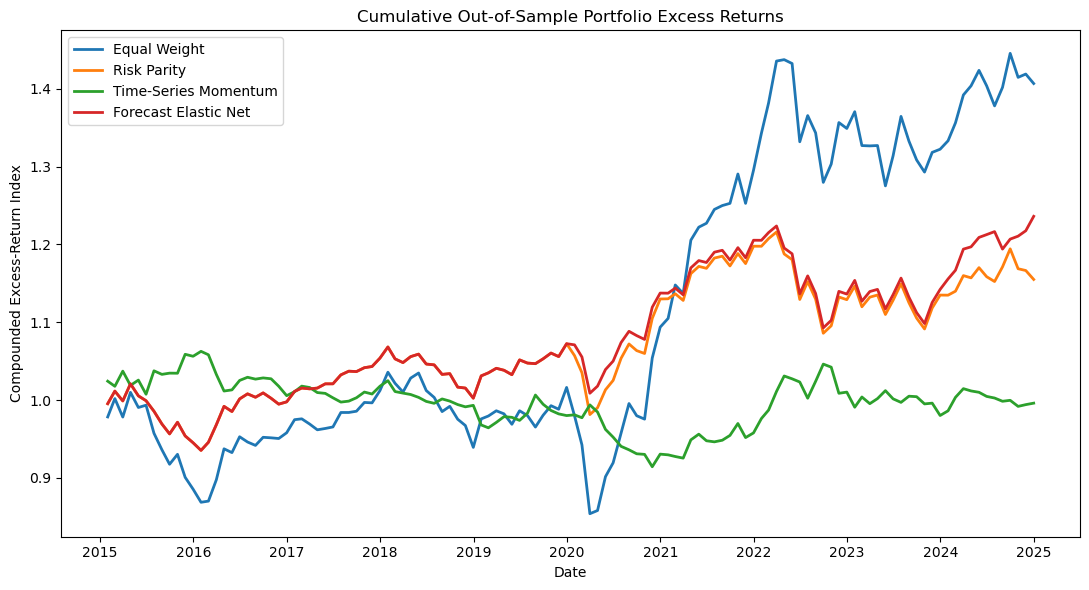

In [35]:
comparison_paths = {
    **benchmark_paths,

    'Forecast Elastic Net':
        forecast_portfolio_path
}


fig, ax = plt.subplots(
    figsize=(11, 6)
)


for strategy, path in (
    comparison_paths.items()
):

    cumulative_return = (
        1
        + path[
            'net_return'
        ]
    ).cumprod()


    ax.plot(
        cumulative_return.index,
        cumulative_return,
        label=strategy,
        linewidth=2
    )


ax.set_title(
    'Cumulative Out-of-Sample Portfolio Excess Returns'
)

ax.set_xlabel(
    'Date'
)

ax.set_ylabel(
    'Compounded Excess-Return Index'
)

ax.legend()

plt.tight_layout()
fig.savefig(
    "figure3_oos_portfolio_returns.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

### 4.4 Benchmark Exposure and Timing

The forecast-based portfolio may outperform a benchmark either because it takes similar systematic positions more efficiently or because its forecasts provide genuinely distinct timing and asset-selection information. I therefore compare its monthly net returns with the three benchmark strategies.

First, I examine return correlations. I then regress the forecast portfolio's monthly net excess return on the equal-weight, risk-parity, and time-series-momentum portfolio returns. The regression coefficients measure benchmark exposures, while the intercept captures average return not associated with those benchmark strategies. The regression R-squared measures how much of the forecast portfolio's monthly variation can be explained by the benchmark rules.

In [118]:
diagnostic_returns = pd.DataFrame({
    'Forecast Elastic Net':
        forecast_portfolio_path[
            'net_return'
        ],

    'Equal Weight':
        benchmark_paths[
            'Equal Weight'
        ][
            'net_return'
        ],

    'Risk Parity':
        benchmark_paths[
            'Risk Parity'
        ][
            'net_return'
        ],

    'Time-Series Momentum':
        benchmark_paths[
            'Time-Series Momentum'
        ][
            'net_return'
        ]
}).dropna()


return_correlations = (
    diagnostic_returns
    .corr()
)


display(
    return_correlations
    .round(3)
)

,Forecast Elastic Net,Equal Weight,Risk Parity,Time-Series Momentum
Forecast Elastic Net,1.000,0.866,0.939,-0.361
Equal Weight,0.866,1.000,0.917,-0.275
Risk Parity,0.939,0.917,1.000,-0.360
Time-Series Momentum,-0.361,-0.275,-0.360,1.000


#### Benchmark-Exposure Regression

To separate benchmark exposure from distinct forecast information, I regress the forecast portfolio's monthly net excess return on the contemporaneous net returns of all three benchmark strategies:

$$
r^{Forecast}_t
=
\alpha
+
\beta_{EW}r^{EW}_t
+
\beta_{RP}r^{RP}_t
+
\beta_{TSMOM}r^{TSMOM}_t
+
\varepsilon_t.
$$

A high regression R-squared indicates that the forecast strategy largely reproduces the benchmark return patterns. The annualized intercept is reported descriptively as the average return component not associated with those benchmark exposures; no statistical-significance claim is made without an accompanying standard error or t-statistic.


In [119]:
y = (
    diagnostic_returns[
        'Forecast Elastic Net'
    ]
    .to_numpy()
)


benchmark_names = [
    'Equal Weight',
    'Risk Parity',
    'Time-Series Momentum'
]


X = (
    diagnostic_returns[
        benchmark_names
    ]
    .to_numpy()
)


X_with_intercept = np.column_stack([
    np.ones(len(X)),
    X
])


coefficients = np.linalg.lstsq(
    X_with_intercept,
    y,
    rcond=None
)[0]


fitted_returns = (
    X_with_intercept
    @ coefficients
)


residuals = (
    y
    - fitted_returns
)


regression_r2 = (
    1
    -
    np.sum(
        residuals ** 2
    )
    /
    np.sum(
        (
            y - y.mean()
        ) ** 2
    )
)


annualized_alpha = (
    coefficients[0]
    * 12
)


benchmark_exposure_results = (
    pd.DataFrame({
        'Variable': [
            'Intercept (Alpha)',
            'Equal Weight',
            'Risk Parity',
            'Time-Series Momentum'
        ],

        'Coefficient': coefficients
    })
)


display(
    benchmark_exposure_results
    .round(4)
)


print(
    "Annualized alpha:",
    round(
        100 * annualized_alpha,
        3
    ),
    "%"
)


print(
    "Regression R-squared:",
    round(
        100 * regression_r2,
        2
    ),
    "%"
)

,Variable,Coefficient
0,Intercept (Alpha),0.0007
1,Equal Weight,0.0222
2,Risk Parity,0.8511
3,Time-Series Momentum,-0.0365


Annualized alpha: 0.82 %
Regression R-squared: 88.27 %


In [120]:
return_contributions = {
    'Alpha':
        coefficients[0] * 12
}


for i, benchmark in enumerate(
    benchmark_names,
    start=1
):

    return_contributions[
        benchmark
    ] = (
        coefficients[i]
        *
        diagnostic_returns[
            benchmark
        ].mean()
        * 12
    )


return_contributions[
    'Total Forecast Return'
] = (
    diagnostic_returns[
        'Forecast Elastic Net'
    ].mean()
    * 12
)


contribution_table = (
    pd.DataFrame(
        return_contributions.items(),
        columns=[
            'Component',
            'Annualized Contribution'
        ]
    )
)


contribution_table[
    'Annualized Contribution (%)'
] = (
    100
    * contribution_table[
        'Annualized Contribution'
    ]
)


display(
    contribution_table[
        [
            'Component',
            'Annualized Contribution (%)'
        ]
    ]
    .round(3)
)

,Component,Annualized Contribution (%)
0,Alpha,0.820
1,Equal Weight,0.084
2,Risk Parity,1.349
3,Time-Series Momentum,-0.001
4,Total Forecast Return,2.251


## Write-up

**Predicting Cross-Country Asset Returns with Machine Learning: Asset Characteristics, Macroeconomic Information, and Portfolio Performance**

### Introduction

Predicting expected returns is a central problem in empirical asset pricing and practical portfolio allocation. For an investor allocating capital across countries and asset classes, even modest improvements in forecasts can be economically useful if they help distinguish relatively attractive assets from unattractive ones, adapt exposures to changing economic conditions, or improve portfolio risk-adjusted performance. At the same time, realized returns are extremely noisy, and relationships that appear strong in sample often fail when evaluated on new data. The relevant question is therefore not simply whether characteristics or macroeconomic variables are historically correlated with returns, but whether information available to an investor at a given date can reliably forecast returns that occur afterward.

This paper studies monthly excess-return predictability in a panel of 50 anonymized assets spanning four asset classes and 12 countries from January 2000 through December 2024. Each asset is accompanied by five asset-level characteristics, while the dataset also contains global and country-level macroeconomic and financial variables. The analysis addresses three questions. First, how much of next month's excess return can be forecast from lagged asset characteristics? Second, does global or country-specific macroeconomic information add predictive content beyond those characteristics? Third, can the resulting forecasts be translated into portfolios that improve on simple allocation rules such as Equal Weight, Risk Parity, and Time-Series Momentum after accounting for turnover and transaction costs?

The approach taken in my analysis is motivated by two related pieces of asset-pricing literature. Gu, Kelly, and Xiu (2020) show that machine-learning methods can be useful for return prediction when the predictor set is large and relationships between predictors and expected returns are nonlinear. Their results also emphasize the potential role of interactions between asset characteristics and aggregate economic conditions, an idea that motivates one of the extensions considered in my analysis. By contrast, Welch and Goyal (2008) demonstrate that many apparently successful macroeconomic predictors perform poorly once evaluated out of sample. These findings motivate an empirical design that places particular emphasis on time ordering, real-time information availability, regularization, and genuinely out-of-sample evaluation.

The data also create several practical challenges for pooled forecasting. Return volatility differs substantially across asset classes, the anonymized characteristics vary considerably in scale and persistence, and the macroeconomic panel contains persistent, correlated, and sometimes redundant variables. To prevent high-volatility assets from dominating model estimation, the primary prediction target is excess return scaled by lagged volatility.

Rather than committing to a single forecasting approach, I compare models with different degrees of flexibility, ranging from OLS and Elastic Net to Random Forest, Gradient Boosting, and an ensemble of the nonlinear and regularized forecasts. I evaluate each model under both expanding and rolling estimation windows using strictly time-ordered validation and out-of-sample testing. I also test whether explicit interactions between asset characteristics and macroeconomic conditions, as well as a wider set of macroeconomic predictors, provide incremental predictive value beyond the core specifications. The preferred forecasting model is then translated into a portfolio and evaluated against Equal Weight, Risk Parity, and Time-Series Momentum.

The empirical results favor a relatively simple forecasting specification. Asset characteristics contain modest out-of-sample predictive information when models are estimated using a rolling ten-year window. Adding global macroeconomic variables improves the rolling Elastic Net, increasing out-of-sample R-squared relative to zero from 0.142% to 0.467%, while additional country-level macroeconomic variables provide essentially no further improvement. More flexible nonlinear models, explicit characteristic-macro interactions, and a wider macroeconomic predictor set also fail to deliver additional out-of-sample gains.

The preferred rolling Elastic Net using asset characteristics and global macroeconomic variables also produces economically meaningful, although modest, portfolio results. At a transaction cost of 10 basis points per dollar of turnover, the forecast portfolio earns a net Sharpe ratio of 0.439 compared with 0.433 for Equal Weight, while operating at substantially lower volatility. However, the strategy does not dominate the simpler benchmark in raw return, its risk-adjusted advantage declines as transaction costs rise, and its returns are highly correlated with Risk Parity. Overall, the evidence supports modest and economically fragile predictability rather than a large or universal machine-learning advantage.

The remainder of the paper describes the data and exploratory analysis, develops the forecasting and portfolio methodology, presents the out-of-sample results, and discusses their economic interpretation and limitations.

### Data and Exploratory Analysis

#### Sample and Asset Universe

The primary dataset is a balanced monthly panel covering January 2000 through December 2024. It contains 50 assets observed over 300 month-end dates, for a total of 15,000 asset-month observations. Returns are monthly excess returns expressed in decimal form. The asset panel contains no missing returns, no missing values in the five provided asset characteristics, and no duplicate asset-month observations.

The 50 assets are divided into four anonymized asset classes. Class A contains 26 assets, Class B contains 8, Class C contains 9, and Class D contains 7. Assets in Classes B, C, and D are associated with economically meaningful country labels drawn from a set of 12 anonymized countries. Class A is different: its 26 assets have no natural country assignment and are all labeled `country_7` in the raw files by convention.

| Asset class | Number of assets | Share of universe | Country structure |
|---|---:|---:|---|
| A | 26 | 52% | No natural country; coded as `country_7` by convention |
| B | 8 | 16% | One country per asset |
| C | 9 | 18% | One country per asset |
| D | 7 | 14% | One country per asset |


#### Return Behavior Across Asset Classes

The four asset classes differ substantially in both average performance and risk. Table 1 reports summary statistics for equal-weighted class portfolios. Annualized mean excess return is calculated as 12 times average monthly excess return, annualized volatility as the monthly standard deviation multiplied by the square root of 12, and the Sharpe ratio as annualized excess return divided by annualized volatility.

**Table 1. Full-sample summary statistics for equal-weighted asset-class portfolios**

| Class | Annualized excess return | Annualized volatility | Sharpe ratio | Worst month | Worst-month date | Maximum drawdown |
|---|---:|---:|---:|---:|---|---:|
| A | 6.02% | 14.61% | 0.41 | -19.85% | Oct. 2008 | -52.66% |
| B | -0.24% | 7.95% | -0.03 | -8.52% | Oct. 2008 | -42.22% |
| C | 4.77% | 14.61% | 0.33 | -16.02% | Oct. 2008 | -55.11% |
| D | 2.68% | 5.28% | 0.51 | -5.03% | Sep. 2022 | -24.80% |

The differences are even larger at the individual-asset level. Annualized volatility ranges from approximately 2.85% for the least volatile asset to 60.26% for the most volatile asset. This heterogeneity matters for pooled forecasting because a squared-error objective applied to raw returns places substantially more weight on high-volatility assets.

Figure 1 plots cumulative excess returns for the four equal-weighted class portfolios. The figure illustrates both long-run differences in performance and common periods of market stress. Classes A, B, and C experience their worst equal-weighted monthly return in October 2008, while Class D experiences its worst month in September 2022.

**Figure 1. Cumulative excess returns by asset class, 2000-2024.**  
*The figure plots the cumulative return of an equal-weighted portfolio within each asset class using monthly excess returns.*

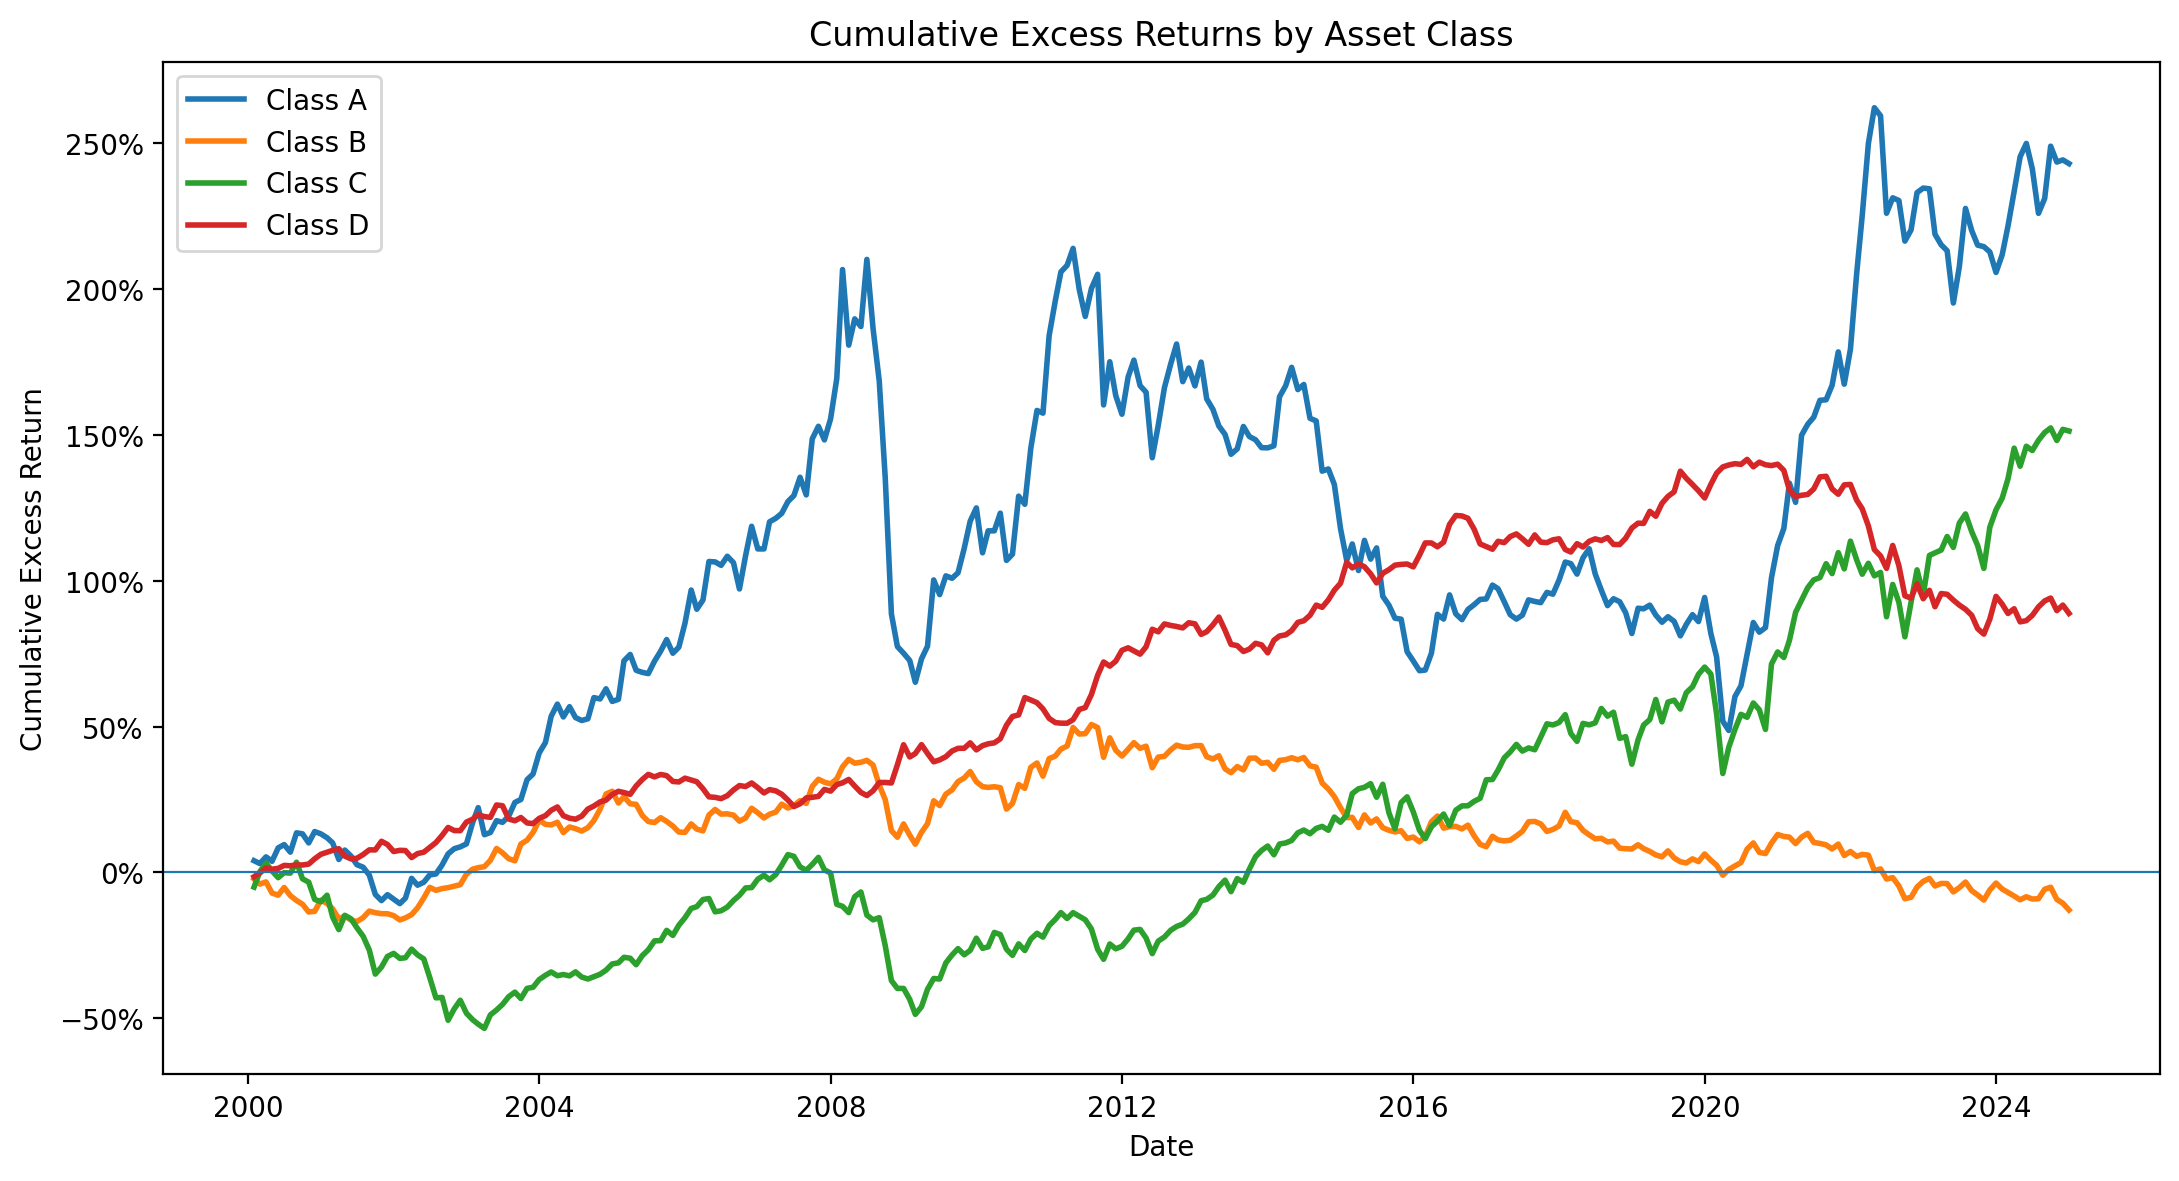

The dependence structure also differs substantially across classes. Figure 2 presents the correlation matrix of individual asset returns ordered by asset class. Average within-class pairwise correlations are approximately 0.21 for Class A, 0.55 for Class B, 0.73 for Class C, and 0.58 for Class D, while most average correlations across classes are considerably smaller. The average correlations between Classes A and D and between Classes C and D are slightly negative.

This block structure is important for the later analysis. The 50 asset returns observed in a given month should not be interpreted as 50 independent observations, and the differences across classes raise the possibility that a single pooled forecasting relationship may not capture all of the cross-sectional heterogeneity.

**Figure 2. Correlation matrix of monthly excess returns ordered by asset class.**  
*Assets are ordered by class so that within-class and between-class dependence can be compared visually.*

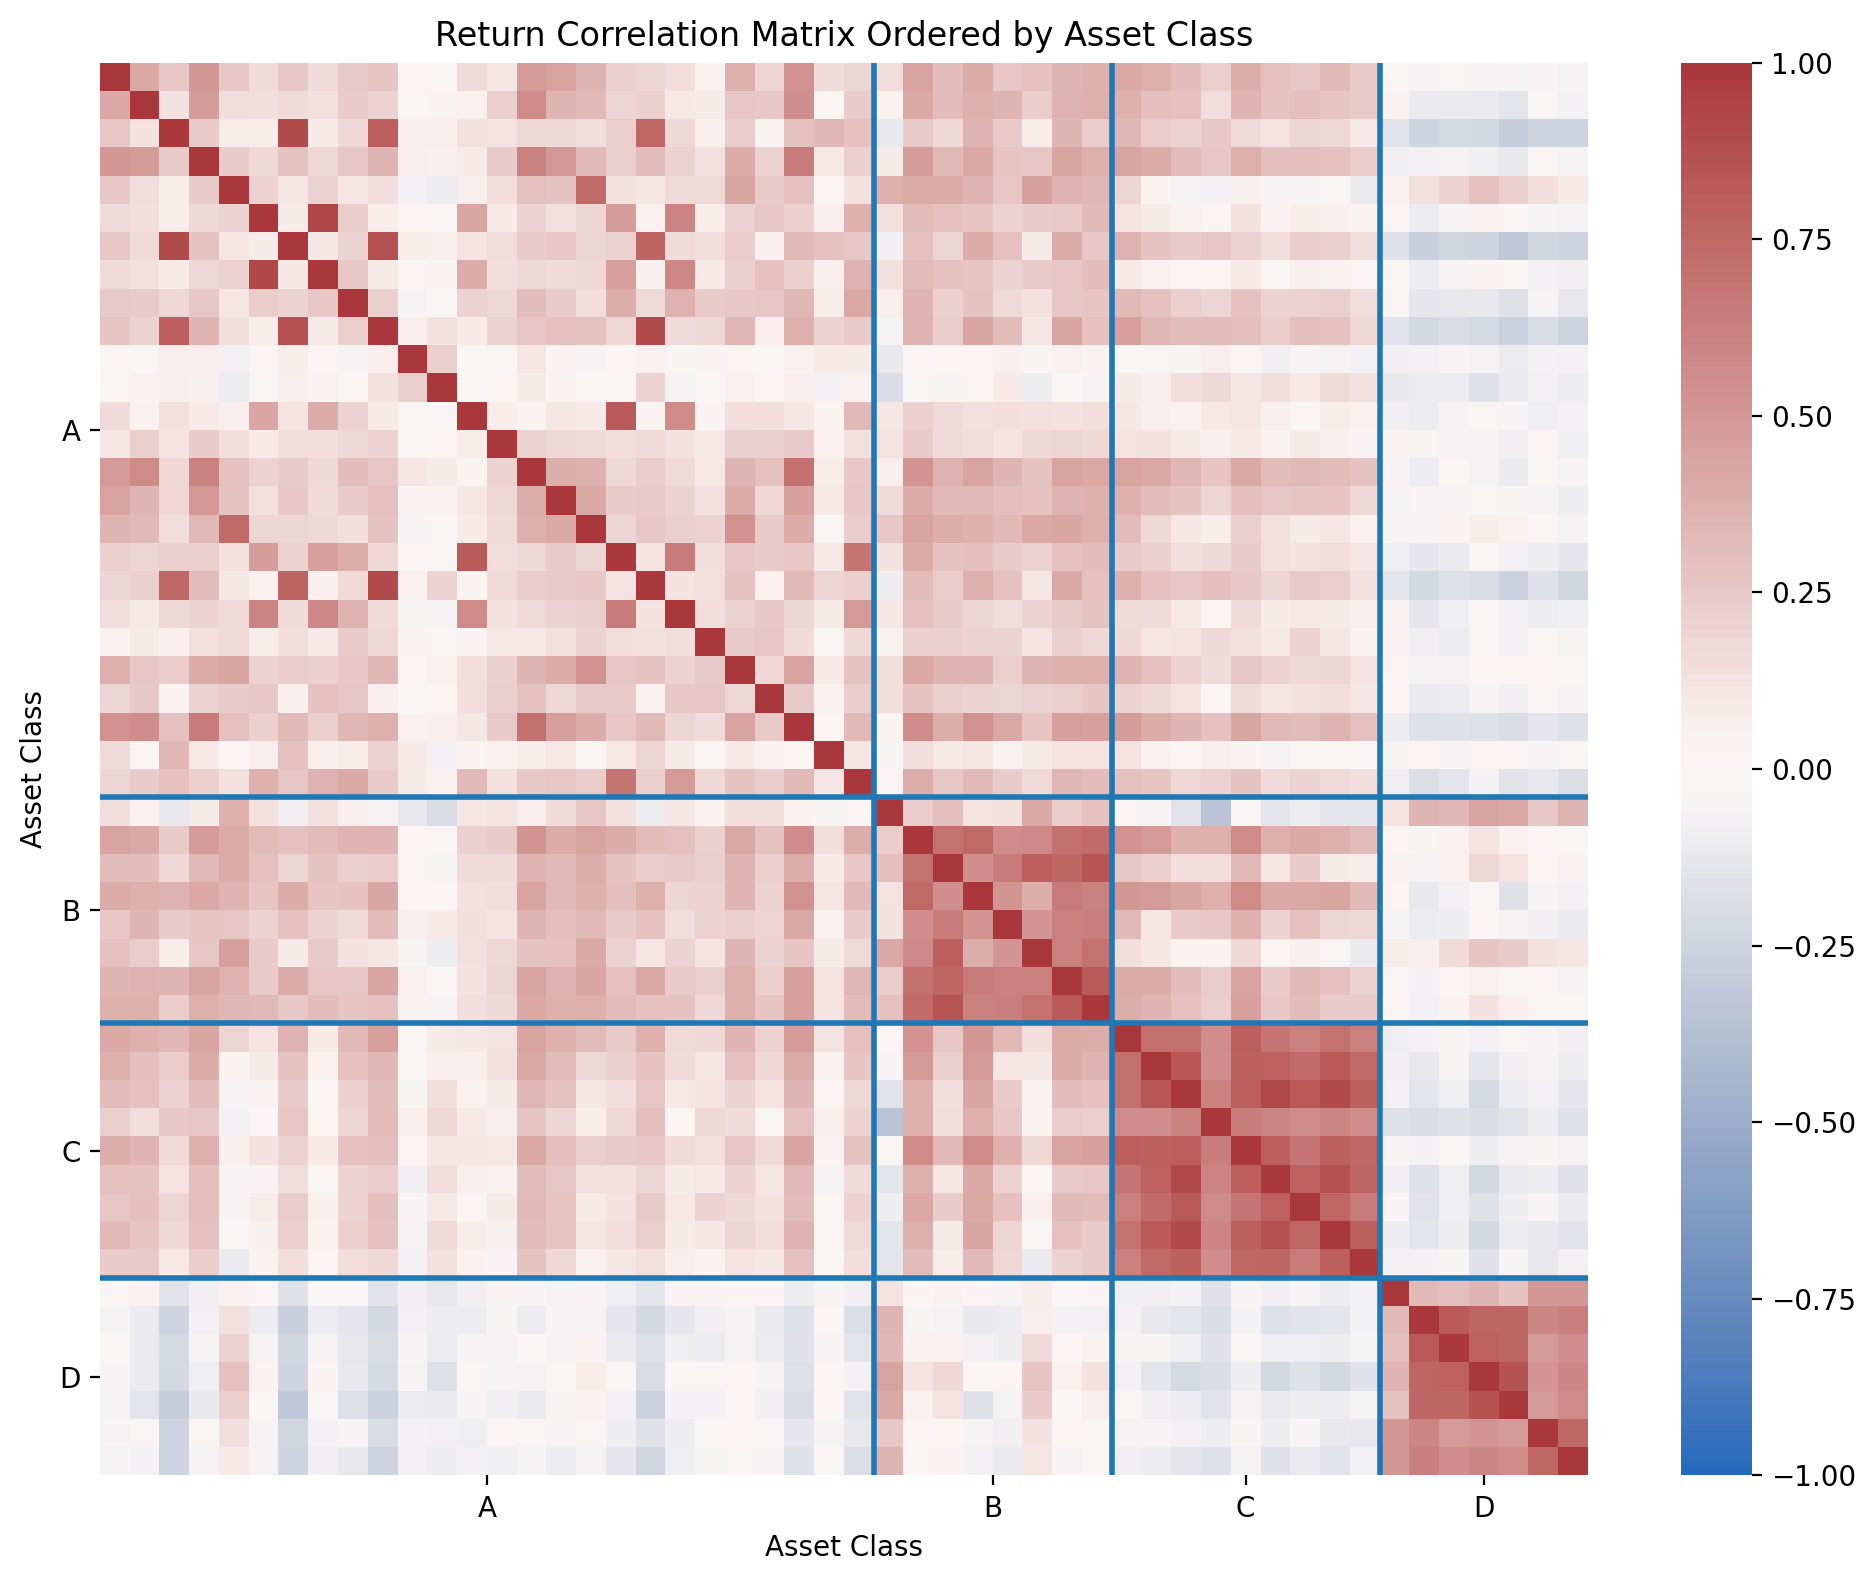


#### The Five Asset Characteristics

Each asset-month observation contains five anonymized characteristics, `x1` through `x5`. The raw scales of the characteristics differ substantially across asset classes. For example, the standard deviation of `x1` is approximately 0.024 in Class A, 0.002 in Class B, 0.054 in Class C, and 1.52 in Class D. Similar differences appear in `x4`. Raw characteristic values therefore cannot automatically be interpreted as economically comparable across classes.

The characteristics are also generally persistent. `x2`, `x3`, and `x5` exhibit especially high month-to-month persistence, with average asset-level first-order autocorrelations of approximately 0.91-0.93 for `x2`, 0.96-0.97 for `x3`, and roughly 0.99 for `x5`. Persistence in `x1` and `x4` is more class dependent.

Three of the five variables can be given more specific working interpretations. `x2` behaves almost exactly like a trailing 12-month momentum measure: its correlation with a reconstructed 12-month compounded return is approximately 0.993, and 99.63% of available observations differ by less than 0.0001. `x5` can be reconstructed to numerical rounding accuracy as the sample standard deviation of the preceding 36 monthly returns, subject to a lower bound of 0.004, giving it a clear interpretation as a volatility characteristic. `x3` appears to capture a longer-horizon value or reversal effect. Its correlation with the negative compounded return over the preceding 60 months is approximately 0.999 in Class A, 0.936 in Class B, 0.364 in Class C, and 0.941 in Class D. The evidence is not strong enough to assign definitive economic identities to `x1` and `x4`. The following table identifies our working understanding of `x1-x5`. 

| Variable | Working interpretation | Confidence |
|---|---|---|
| `x1` | Unidentified cross-sectional characteristic | Low to moderate |
| `x2` | Trailing 12-month momentum | Very high |
| `x3` | Long-horizon value / reversal signal | High, but class dependent |
| `x4` | Unidentified persistent characteristic | Low to moderate |
| `x5` | Trailing 36-month realized volatility | Very high |

The large differences in raw scale provide additional motivation for transforming the characteristics into within-class cross-sectional ranks before pooled model estimation.


#### Preliminary Cross-Sectional Predictive Evidence

Before proceeding with the formal forecasting models, I use a simple characteristic-sort exercise to examine whether the five characteristics show any visible relationship with subsequent returns. Within each month and asset class, assets are ranked on each characteristic and divided into low, middle, and high terciles. The return of the low-characteristic group is then subtracted from that of the high-characteristic group. A positive high-minus-low spread therefore indicates that assets with higher values of the characteristic subsequently earned higher returns on average.

**Figure 3. Annualized high-minus-low tercile returns by characteristic and asset class.**  
*For each characteristic and asset class, the figure reports the annualized average return difference between the high and low characteristic terciles. Predictors are aligned according to their information timing before the sorts are formed.*

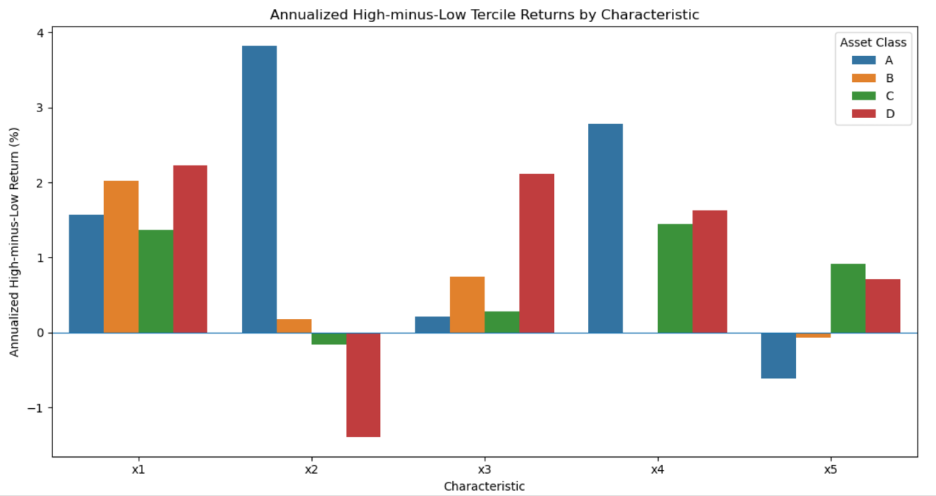

The spreads are generally modest and vary substantially across asset classes. For example, `x2` produces the largest positive spread in Class A at approximately 3.82% annually, but its relationship is negative in Class D. Similar differences appear for the other characteristics. The exercise therefore provides some evidence of cross-sectional return predictability, but no single characteristic has a uniformly strong relationship across all four asset classes.

These sorts are exploratory rather than formal hypothesis tests. Their purpose is to show that the characteristic-return relationships are modest and heterogeneous, motivating the more disciplined out-of-sample forecasting analysis that follows.


#### Why Volatility Scaling Is Important

The differences in return volatility across classes create a potentially serious problem for pooled prediction. Under a conventional squared-error objective, observations with larger realized returns contribute disproportionately to the loss function. Although Class A represents 52% of the assets, it accounts for approximately 87% of the total squared raw returns in the panel. Classes B and D together represent 30% of the universe but account for less than 4%.

**Table 2. Contribution of each class to the pooled squared-return objective**

| Class | Share of assets | Share of squared raw returns | Share after volatility scaling |
|---|---:|---:|---:|
| A | 52.0% | 87.0% | 52.6% |
| B | 16.0% | 2.9% | 15.6% |
| C | 18.0% | 9.0% | 17.7% |
| D | 14.0% | 1.1% | 14.1% |

A model estimated by minimizing pooled raw-return squared errors would therefore be dominated by Class A, even if forecasting performance in the lower-volatility classes were economically important.

The supplied volatility characteristic provides a natural normalization. I define the volatility-scaled return as

$$
y_{i,t} = \frac{r_{i,t}}{\hat{\sigma}_{i,t-1}},
$$

In practice, I divide each month's excess return by x5, which the exploratory analysis strongly suggests represents trailing 36-month realized volatility. The standard deviation of the scaled return is 1.076 in Class A, 1.060 in Class B, 1.061 in Class C, and 1.067 in Class D. As Table 2 shows, each class's contribution to the total squared scaled return also becomes approximately proportional to its share of the asset universe.

This provides the main data-driven motivation for using volatility-scaled excess return as the primary forecasting target. It places more comparable weight on assets with different natural levels of risk rather than allowing the highest-volatility class to dominate model estimation.


#### Global and Country-Level Macroeconomic Data

The asset panel is supplemented by three macroeconomic datasets. `macro_global.csv` contains four global variables, `x6` through `x9`, `macro_country.csv` contains seven curated country-level variables, `x10` through `x16`, and `macro_country_extended.csv` contains 148 additional country-level variables, `x17` through `x164`.

The four global variables are complete but highly persistent, with first-order autocorrelations ranging from approximately 0.845 to 0.984. The curated country panel is also nearly complete. Its main exception is `x11`, which stops updating for three countries and produces 99 missing country-month observations. Because carrying stale values forward indefinitely or using future-based imputation could distort the information available at a forecast date, `x11` requires special treatment in the forecasting analysis.

The extended country panel presents a larger high-dimensional problem. Several variables contain missing observations, it includes exact duplicates of variables already present in the curated and global datasets, `x148` is constant, and a number of the remaining variables are extremely highly correlated. These variables therefore cannot simply be appended mechanically to the baseline predictor set without increasing redundancy and the risk of overfitting in a sample containing only 300 monthly observations. I instead treat the extended panel as a separate high-dimensional robustness exercise.

#### Implications of the Exploratory Analysis

The exploratory analysis points to several features that shape the forecasting design. The four asset classes differ substantially in volatility and dependence structure, making volatility scaling important for balanced pooled estimation. The five characteristics differ in scale and economic interpretation, and their unconditional return relationships appear modest and heterogeneous across classes. Finally, the macroeconomic variables are persistent and the wider country-level panel contains considerable redundancy, making out-of-sample performance more informative than improvements in in-sample fit.

These findings motivate the methodology that follows: strict time ordering, a volatility-scaled prediction target, cross-sectional normalization of the asset characteristics, comparison of simple and flexible forecasting models, explicit tests of the incremental value of macroeconomic information, and evaluation of whether any statistical predictability survives when forecasts are converted into investable portfolios.

### Methodology

#### Prediction Target

The primary forecasting target is volatility-scaled monthly excess return,

$$
y_{i,t}
=
\frac{r_{i,t}}
{\hat{\sigma}_{i,t-1}}.
$$

where `x5` is used as the lagged volatility estimate $\hat{\sigma}_{i,t-1}$. As shown in the exploratory analysis, `x5` closely matches trailing 36-month realized volatility based only on information available before month $t$.

This normalization follows directly from the exploratory analysis, which showed that raw-return squared errors are heavily concentrated in the highest-volatility asset class. Scaling returns by lagged volatility produces a target with much more comparable dispersion across classes and prevents high-volatility assets from dominating estimation.

The raw excess return remains economically important because portfolios ultimately earn unscaled returns. A forecast of the scaled target can be mapped back into a raw return forecast through

$$
\hat{r}_{i,t}
=
\hat{y}_{i,t}
\hat{\sigma}_{i,t-1}.
$$


#### Asset Characteristics

All predictors are aligned so that the information used to forecast month $t$ would have been observable before the return in month $t$ occurred. The supplied `x2` and `x5` variables are already lagged appropriately and are therefore used directly. `x1`, `x3`, and `x4` are shifted by one month within each asset before entering the forecasting panel.

The exploratory analysis showed that the raw scales of the characteristics differ substantially across asset classes. To make them more comparable in a pooled forecasting problem, each timing-aligned characteristic is converted to its cross-sectional percentile rank within asset class and month and then linearly rescaled to the interval from -1 to 1. This preserves the relative ordering of assets on each characteristic while preventing class-specific units from mechanically determining model coefficients or tree splits.

Three asset-class indicators are also included, with Class A serving as the omitted category. Asset-specific fixed effects are not included in the baseline specification. This keeps the forecasting exercise focused on time-varying characteristics, macroeconomic conditions, and broad differences across asset classes rather than allowing the models to memorize persistent asset-level mean returns.


#### Macroeconomic Predictors

The baseline global macroeconomic information set contains the four supplied global variables `x6` through `x9`. Each is lagged by one month before being used for forecasting. The variables remain in their original units when the forecasting panel is constructed. For models that require scaling, means and standard deviations are estimated using historical estimation data only and then applied to subsequent observations.

The curated country macroeconomic file contains `x10` through `x16`. The only incomplete variable, `x11`, stops updating before the end of the sample for three countries. Rather than carry stale values forward or use an imputation procedure that could introduce information unavailable at the forecast date, I exclude `x11` from the forecasting models.

The baseline country information set therefore uses the six complete variables `x10` and `x12` through `x16`. Each is lagged by one month, converted to its cross-sectional percentile rank across the 12 countries at each date, and linearly rescaled to the interval from -1 to 1. Assets in Classes B, C, and D receive the lagged macro rank associated with their own country. Class A has no natural country assignment, so its country-specific macro predictors are set to zero, the neutral midpoint of the rank transformation, rather than assigning all 26 Class A assets the state of `country_7`.


#### Information Sets

The core forecasting exercise uses three nested information sets.

The **CHAR** specification contains the five transformed asset characteristics and three asset-class indicators, for a total of eight predictors.

The **GLOBAL** specification adds the four lagged global macroeconomic variables, increasing the predictor count to 12.

The **COUNTRY** specification additionally includes the six complete curated country-macro ranks, producing 18 predictors.

| Information set | Predictors | Count |
|---|---|---:|
| CHAR | `x1`-`x5` transformed characteristics; `class_B`, `class_C`, `class_D` | 8 |
| GLOBAL | CHAR predictors plus `x6`, `x7`, `x8`, `x9` | 12 |
| COUNTRY | GLOBAL predictors plus `x10`, `x12`, `x13`, `x14`, `x15`, `x16` country ranks | 18 |

This nested structure separates two questions that would otherwise be confounded. Comparing different forecasting models within the same information set tests whether greater model flexibility extracts additional signal. Comparing CHAR, GLOBAL, and COUNTRY within the same model tests whether macroeconomic information adds predictive content beyond the asset characteristics.

#### Forecasting Models

Four base forecasting models are estimated for each information set.

**Ordinary Least Squares (OLS)** provides the unregularized linear benchmark. Predictors are standardized using means and standard deviations estimated from the historical estimation sample.

**Elastic Net** provides a regularized linear model that combines ridge and lasso penalties. The tuning grid contains

- `alpha` in `{0.001, 0.01, 0.1, 0.3, 1.0}`, and
- `l1_ratio` in `{0.1, 0.5, 0.9, 1.0}`.

Predictors are standardized within the estimation pipeline, so no information from the validation or test period enters the scaling transformation.

**Random Forest** allows nonlinear relationships and interactions without specifying them directly. Each forest contains 300 trees. The validation procedure chooses among

- `max_depth` in `{3, 6}`,
- `min_samples_leaf` in `{10, 30}`, and
- `max_features` in `{0.5, 1.0}`.

**Gradient Boosting** provides a second nonlinear specification based on sequentially fitted shallow trees. The tuning grid contains

- `n_estimators` in `{100, 300}`,
- `learning_rate` in `{0.03, 0.10}`, and
- `max_depth` in `{1, 2}`,

with `min_samples_leaf = 20`.

The tree-based models are not standardized because their split rules are invariant to monotonic rescaling of individual predictors.

Finally, a simple **forecast ensemble** is constructed by taking the equal-weight average of the Elastic Net, Random Forest, and Gradient Boosting forecasts. No additional ensemble parameters are estimated. This provides a test of whether the three model families contain complementary forecasting information.


#### Hyperparameter Selection and Out-of-Sample Design

The out-of-sample evaluation period runs from January 2015 through December 2024. Models are refit annually, while forecasts are produced monthly during each test year using predictor values available for that month.

The primary estimation scheme is an expanding-window design. For the first forecast year, observations through the end of 2009 form the training sample, observations from 2010 through 2014 form the validation sample, and returns during 2015 form the first test period. For the 2016 forecast, the training history expands through 2010, the validation period moves forward to 2011-2015, and the model predicts 2016. This process continues annually through the 2024 test year.

A second specification uses a ten-year rolling training window while retaining the same five-year validation and one-year test structure. This comparison tests whether retaining the full historical sample improves estimation through a larger sample or whether older observations become less relevant as return-predictive relationships evolve.

All sample splits occur by date rather than by individual asset-month observation. The 50 assets from a given month therefore remain together in the same training, validation, or test block. No random cross-validation is used.

For each model requiring hyperparameter tuning, information set, estimation scheme, and test year, candidate hyperparameter specifications are estimated using the training block and evaluated on the subsequent five-year validation period. Validation loss is calculated by first averaging squared forecast errors across assets within each month and then averaging those monthly losses across the validation period. The specification with the lowest validation mean squared error is selected.

After hyperparameters are selected, the chosen specification is refit before the test year using all observations allowed by the relevant estimation scheme. Under the expanding scheme, this means all observations available through the end of the preceding year. Under the rolling scheme, it means the ten years immediately preceding the test year. Thus, validation observations can be incorporated into the final refit only after they have served their role in hyperparameter selection, while the subsequent test year remains completely untouched.

The refitted model is then held fixed during the following test year, while monthly predictor values change as new information becomes available. Predictor standardization and all other fitted transformations are re-estimated using historical data only.


#### Forecast Benchmarks and Evaluation

Predictive performance is evaluated relative to two simple forecasts.

The first predicts zero volatility-scaled excess return for every asset. This is a natural benchmark because monthly excess returns are difficult to forecast and are close to zero unconditionally.

The second predicts the pooled expanding historical mean volatility-scaled return, calculated across all asset-month observations available through the end of the preceding month. The same pooled forecast is applied to every asset in month $t$ and is updated monthly, so no return from the forecast month enters its own prediction.

For model forecast $\hat{y}_{i,t}$ and benchmark forecast $\hat{y}^{\,b}_{i,t}$, out-of-sample predictive performance is measured using

$$
R^2_{OOS}
=
1
-
\frac{
\sum_{i,t}
\left(
y_{i,t}
-
\hat{y}_{i,t}
\right)^2
}{
\sum_{i,t}
\left(
y_{i,t}
-
\hat{y}^{\,b}_{i,t}
\right)^2
}.
$$

The analysis reports this measure relative to both zero and the historical-mean benchmark, both for the full asset universe and separately by asset class. Positive values indicate that the forecasting model reduces squared prediction error relative to the benchmark, while negative values indicate that the benchmark forecasts more accurately.


#### Additional Forecasting Extensions

The core specifications compare forecasting methods while keeping the predictor sets relatively simple and consistent. I then consider two richer specifications to test whether the main results change when macroeconomic information is represented more flexibly.

The first extension adds every interaction between the five transformed asset characteristics and the four lagged global macroeconomic variables. This generates 20 characteristic-macro interaction terms. Together with the five characteristic main effects, three asset-class indicators, and four global macro variables, the interaction specification contains 32 predictors. Because the larger predictor set creates greater risk of overfitting, the model is estimated using Elastic Net with the same tuning grid as in the core analysis. The interaction specification is evaluated under both expanding and rolling estimation schemes.

The second extension uses the wider `x17` through `x164` country-macro panel. I follow the exclusion rules motivated by the exploratory analysis and remove variables with missing observations, exact duplicates of variables already contained in the curated or global macro sets, and variables that are constant throughout the sample. The resulting exclusions are summarized below.

| Reason for exclusion | Variables removed |
|---|---|
| Missing observations | `x55`, `x82`, `x83`, `x113`, `x136`, `x163`, `x164` |
| Exact duplicates of existing macro variables | `x17`, `x18`, `x73`, `x88`, `x89`, `x92`, `x99`, `x104`, `x109`, `x114` |
| Constant throughout the sample | `x148` |

These exclusions remove 18 of the 148 extended variables, leaving 130 candidate macro predictors. The remaining variables are lagged by one month and converted to cross-country ranks using the same procedure as the curated country variables. Assets in Classes B, C, and D receive the rank associated with their own country, while Class A again receives zero for these country-specific predictors.

Because directly fitting a flexible nonlinear model to all 130 extended variables would create a high-dimensional search problem, I use a two-stage procedure within each rolling forecasting window. First, the ten-year historical training block is divided chronologically into an initial seven-year screening-estimation sample and a subsequent three-year screening-validation sample. Elastic Net is used to select the penalty parameters and identify extended macro variables with nonzero coefficients. The selected Elastic Net is then refit on the full ten-year training block, and only the extended variables with nonzero coefficients are retained. The five asset characteristics, three class indicators, and four global macro variables are always kept regardless of the screening results.

Gradient Boosting is then tuned on the existing five-year validation period using the retained extended macro variables together with the core predictors. The selected Gradient Boosting specification is finally refit on the most recent ten years available before the test year and used to forecast the following year. This procedure keeps variable screening, model tuning, and final test evaluation chronologically separated while allowing the wider macro panel to enter the nonlinear model only when variables survive the regularized screening stage.


#### Portfolio Model Selection

After evaluating the forecasting models, I use the preferred specification to examine whether the statistical predictability documented in the forecasting exercise can be translated into economically useful portfolio positions. Rather than constructing portfolios from every model, I select the specification with the strongest overall out-of-sample forecasting performance and use its forecasts throughout the portfolio analysis.

As shown in the Results section below, the rolling GLOBAL Elastic Net performs best among the core specifications, so it is selected for the forecast-based portfolio. This specification combines the five asset characteristics, the asset-class indicators, and the four global macroeconomic variables using a ten-year rolling estimation window.

The portfolio exercise evaluates the economic implications of the forecasting specification that performs best in the main out-of-sample comparison. Because model selection is based on forecasting performance over the same 2015-2024 period used for the portfolio comparison, the portfolio exercise should not be interpreted as a separate untouched holdout test. Importantly, the individual monthly forecasts used to construct the portfolio remain genuinely out of sample and are generated without future information.


#### From Forecasts to Portfolio Weights

The preferred model predicts volatility-scaled return,

$$
\hat{y}_{i,t}
=
\frac{\hat{r}_{i,t}}
{\hat{\sigma}_{i,t-1}}.
$$

To translate this forecast into a portfolio position, each asset receives the score

$$
s_{i,t}
=
\frac{\hat{y}_{i,t}}
{\hat{\sigma}_{i,t-1}}
=
\frac{\hat{r}_{i,t}}
{\hat{\sigma}_{i,t-1}^{2}}.
$$

Because the model already forecasts return scaled by volatility, dividing the forecast by volatility once more produces a score proportional to predicted excess return divided by predicted variance. The allocation therefore favors assets with higher expected returns and lower risk.

Positive forecasts generate long positions and negative forecasts can generate short positions.

Each month, scores are normalized to unit gross exposure:

$$
w_{i,t}
=
\frac{s_{i,t}}
{\sum_j |s_{j,t}|}.
$$

Thus,

$$
\sum_i |w_{i,t}| = 1
$$

for every month. No separate net-exposure constraint is imposed.

Weights for month $t$ are formed entirely from information available before the month-$t$ return is realized and are then applied to the realized excess return in month $t$. The portfolio is rebalanced monthly.


#### Portfolio Benchmarks and Trading Costs

Forecasting accuracy alone does not establish economic value. The forecast portfolio is therefore compared with three simple portfolio rules.

The **Equal Weight** portfolio assigns the same positive weight to all 50 assets.

The **Risk Parity** portfolio assigns weights proportional to the inverse of each asset's trailing 36-month volatility.

The **Time-Series Momentum** portfolio assigns positions proportional to the sign of the asset's trailing 12-month return divided by its trailing volatility.

Each strategy is rebalanced monthly and normalized so that the sum of absolute portfolio weights equals one.

Turnover is measured as the sum of absolute changes in target weights between consecutive months. Because the supplied series are excess returns rather than total asset returns, exact post-return weight drift cannot be reconstructed. The same target-to-target turnover convention is therefore applied consistently to the forecast portfolio and the benchmarks.

Because the underlying instruments are anonymized, instrument-specific transaction costs cannot be estimated credibly from the supplied data. The primary specification applies a common cost of 10 basis points per dollar of turnover. Sensitivity is evaluated at 25 and 50 basis points.

Portfolio performance is summarized using annualized excess return, annualized volatility, Sharpe ratio, maximum drawdown, monthly turnover, compounded cumulative excess returns, and performance net of transaction costs.

### Results

#### Forecastability from Asset Characteristics

The first question is whether lagged asset characteristics contain useful information about next-month excess returns. The answer is yes, but the amount of predictability is modest and depends importantly on the estimation window.

Under the expanding-window specification, none of the characteristic-only models improves on the zero-return benchmark. OOS R-squared ranges from -0.038% for Elastic Net to -0.321% for OLS.

The results improve when estimation is restricted to the most recent ten years. Under the rolling-window specification, Elastic Net produces an OOS R-squared of 0.142% relative to zero, Random Forest produces 0.116%, and the three-model ensemble produces 0.148%. Gradient Boosting and OLS remain slightly negative. Results relative to the trailing-mean benchmark are similar.

Table 3 reports the complete core forecasting comparison against both no-model benchmarks. The contrast between rolling and expanding estimation is visible across model classes. For the characteristic-only information set, the strongest rolling specifications produce small positive OOS R-squared values against both zero and the trailing historical mean, while the corresponding expanding estimates are uniformly negative.

**Table 3. Core out-of-sample forecasting performance**

*Entries are OOS R-squared in percentage points. Panel A uses the zero-return benchmark and Panel B uses the pooled expanding trailing-mean benchmark. The table is rounded to two decimal percentage points; exact values for the main specifications are reported in the text.*

**Panel A. OOS R² vs. Zero**

| Estimation scheme | Model | CHAR | GLOBAL | COUNTRY |
|---|---|---:|---:|---:|
| Expanding | OLS | -0.32% | -1.61% | -1.61% |
| Expanding | Elastic Net | -0.04% | -0.03% | -0.03% |
| Expanding | Random Forest | -0.22% | -4.52% | -6.02% |
| Expanding | Gradient Boosting | -0.20% | -2.64% | -2.64% |
| Expanding | Ensemble | -0.10% | -1.79% | -2.19% |
| Rolling | OLS | -0.07% | -0.72% | -0.75% |
| Rolling | Elastic Net | 0.14% | 0.47% | 0.46% |
| Rolling | Random Forest | 0.12% | -2.77% | -2.77% |
| Rolling | Gradient Boosting | -0.04% | -1.79% | -1.07% |
| Rolling | Ensemble | 0.15% | -0.70% | -0.50% |

**Panel B. OOS R² vs. Trailing Mean**

| Estimation scheme | Model | CHAR | GLOBAL | COUNTRY |
|---|---|---:|---:|---:|
| Expanding | OLS | -0.30% | -1.58% | -1.58% |
| Expanding | Elastic Net | -0.01% | -0.01% | -0.01% |
| Expanding | Random Forest | -0.20% | -4.50% | -5.99% |
| Expanding | Gradient Boosting | -0.17% | -2.62% | -2.62% |
| Expanding | Ensemble | -0.08% | -1.77% | -2.16% |
| Rolling | OLS | -0.05% | -0.69% | -0.72% |
| Rolling | Elastic Net | 0.17% | 0.49% | 0.49% |
| Rolling | Random Forest | 0.14% | -2.75% | -2.74% |
| Rolling | Gradient Boosting | -0.01% | -1.76% | -1.04% |
| Rolling | Ensemble | 0.17% | -0.68% | -0.47% |

Although these R-squared values are small, realized monthly asset returns are extremely noisy. The relevant question is therefore whether the models improve consistently on real-time benchmarks rather than whether they explain a large fraction of total return variation. The results show that the strongest characteristic-only forecasts are obtained when estimation places greater weight on more recent observations.

Overall, the characteristic results provide evidence of modest out-of-sample return predictability, with Elastic Net, Random Forest, and the ensemble all producing positive rolling-window performance relative to the two benchmarks.


#### Incremental Value of Macroeconomic Information

The second question is whether macroeconomic information improves forecasts beyond asset-level characteristics. The strongest evidence comes from the rolling-window Elastic Net. Adding the four global macroeconomic variables increases OOS R-squared relative to zero from 0.142% for CHAR to 0.467% for GLOBAL, an improvement of 0.325 percentage points. Performance relative to the trailing-mean benchmark is also positive, with an OOS R-squared of 0.492% for the GLOBAL specification.

Country-specific macroeconomic information contributes almost nothing beyond the global variables. The rolling COUNTRY Elastic Net produces an OOS R-squared of 0.464% relative to zero, approximately 0.003 percentage points below the GLOBAL specification. The additional cross-country variation contained in the curated country variables therefore does not improve aggregate forecasting performance beyond the global macro variables.

The benefit of macro information is highly model-dependent. While Elastic Net improves substantially after global macro variables are added, the other models deteriorate. Under the rolling GLOBAL specification, Random Forest produces an OOS R-squared of -2.774%, Gradient Boosting -1.788%, OLS -0.718%, and the ensemble -0.701%. The ensemble also performs poorly because it combines the relatively strong Elastic Net forecasts with substantially weaker nonlinear forecasts.

These results show that simply expanding the predictor set does not necessarily improve forecasting performance. In this sample, the incremental value of the global macro variables is concentrated in the regularized Elastic Net specification.

Because aggregate forecasting performance can conceal differences across asset classes, Table 4 reports the preferred rolling GLOBAL Elastic Net separately for Classes A through D. These statistics evaluate the same pooled model within each asset class; they are not estimates from four separately fitted class-specific models.

**Table 4. Preferred rolling GLOBAL Elastic Net performance by asset class**

*Entries report OOS R-squared in percentage points relative to the zero-return and pooled expanding historical-mean benchmarks.*

| Class | OOS R² vs. Zero | OOS R² vs. Trailing Mean |
|---|---:|---:|
| A | 0.675% | 0.467% |
| B | -0.035% | 1.899% |
| C | 1.800% | 0.490% |
| D | -1.368% | -0.841% |

Performance is heterogeneous across asset classes. The preferred model is strongest in Class C and also produces positive improvements in Class A relative to both benchmarks. In Class B, performance is essentially flat relative to zero but substantially better than the trailing-mean benchmark, while Class D is negative relative to both. The pooled forecasting gain therefore does not reflect uniform predictability across the asset universe.


#### Interactions and the Extended Macroeconomic Panel

I next test two additional specifications intended to capture relationships that may be missed by the core forecasting models.

The first extension adds all 20 interactions between the five asset characteristics and four global macro variables to the Elastic Net. This tests whether macroeconomic conditions contain additional predictive information through their interaction with asset characteristics. The interaction model does not improve forecasting performance. Under the rolling window, its OOS R-squared relative to zero is 0.459%, compared with 0.467% for the simpler GLOBAL Elastic Net. Under the expanding window, the interaction specification performs substantially worse, with an OOS R-squared of -1.308%.

The coefficient-selection results also provide little evidence of stable characteristic-macro interactions. In the rolling specification, no interaction is selected in more than one of the ten annual estimation windows, while most interactions are never selected. The interaction terms therefore do not provide a persistent source of additional forecasting performance.

The second extension uses the much wider `x17` through `x164` country-macro panel. After removing incomplete, constant, and exact duplicate variables, 130 extended predictors remain. Elastic Net is used to screen these variables within each historical forecasting window, after which Gradient Boosting is estimated using the surviving macro variables together with the core predictors.

This procedure also fails to uncover stable additional signal. The screened Gradient Boosting model produces a rolling OOS R-squared of -1.794%, essentially identical to the -1.788% obtained by the ordinary GLOBAL Gradient Boosting model and far below the 0.467% achieved by GLOBAL Elastic Net. No extended macro variable is selected in more than two of the ten annual forecast windows.

Taken together, the two extensions provide no evidence that either explicit characteristic-macro interactions or a much larger country-macro predictor set improves on the simpler rolling GLOBAL Elastic Net.


#### Economic Value of the Forecasts

The final question is whether the predictive signal translates into economically useful portfolio decisions. Based on the forecasting comparison, I use the rolling GLOBAL Elastic Net to form the forecast-based portfolio. Because this specification was selected after comparing forecasting performance over the 2015-2024 out-of-sample period, the portfolio exercise should be interpreted as an economic evaluation of the preferred forecasting model rather than as a completely independent second holdout test.

At the primary transaction-cost assumption of 10 basis points per dollar of turnover, the forecast portfolio earns a net annualized excess return of 2.25% with annualized volatility of 5.13%, producing a net Sharpe ratio of 0.439. Equal Weight earns a higher annualized return of 3.80%, but does so with substantially greater volatility of 8.78% and a Sharpe ratio of 0.433. The forecast portfolio therefore produces slightly greater return per unit of risk, although not a higher absolute return.

Risk Parity produces similar volatility but weaker performance, with a net annualized return of 1.59% and a Sharpe ratio of 0.294. Time-Series Momentum performs poorly over this sample, producing a net annualized return of only 0.04% and a Sharpe ratio of 0.010. The forecast strategy also experiences a maximum drawdown of approximately -10.70%, compared with -17.55% for Equal Weight.

**Table 5. Out-of-sample portfolio performance, 2015-2024**

*Net performance uses the primary transaction-cost assumption of 10 basis points per dollar of turnover.*

| Strategy | Gross return | Volatility | Gross Sharpe | Net return | Net Sharpe | Max drawdown | Monthly turnover |
|---|---:|---:|---:|---:|---:|---:|---:|
| Equal Weight | 3.80% | 8.78% | 0.433 | 3.80% | 0.433 | -17.55% | 0.00% |
| Risk Parity | 1.61% | 5.38% | 0.299 | 1.59% | 0.294 | -10.70% | 2.11% |
| Time-Series Momentum | 0.34% | 4.02% | 0.085 | 0.04% | 0.010 | -13.96% | 25.47% |
| Forecast Elastic Net | 2.36% | 5.13% | 0.459 | 2.25% | 0.439 | -10.70% | 8.93% |

Figure 3 plots the cumulative net excess-return paths of the forecast portfolio and the three benchmark strategies over the same out-of-sample period.

**Figure 3. Cumulative out-of-sample net portfolio excess returns, 2015-2024.**  
*The figure compares the preferred rolling GLOBAL Elastic Net portfolio with Equal Weight, Risk Parity, and Time-Series Momentum. Net returns incorporate transaction costs of 10 basis points per dollar of turnover.*

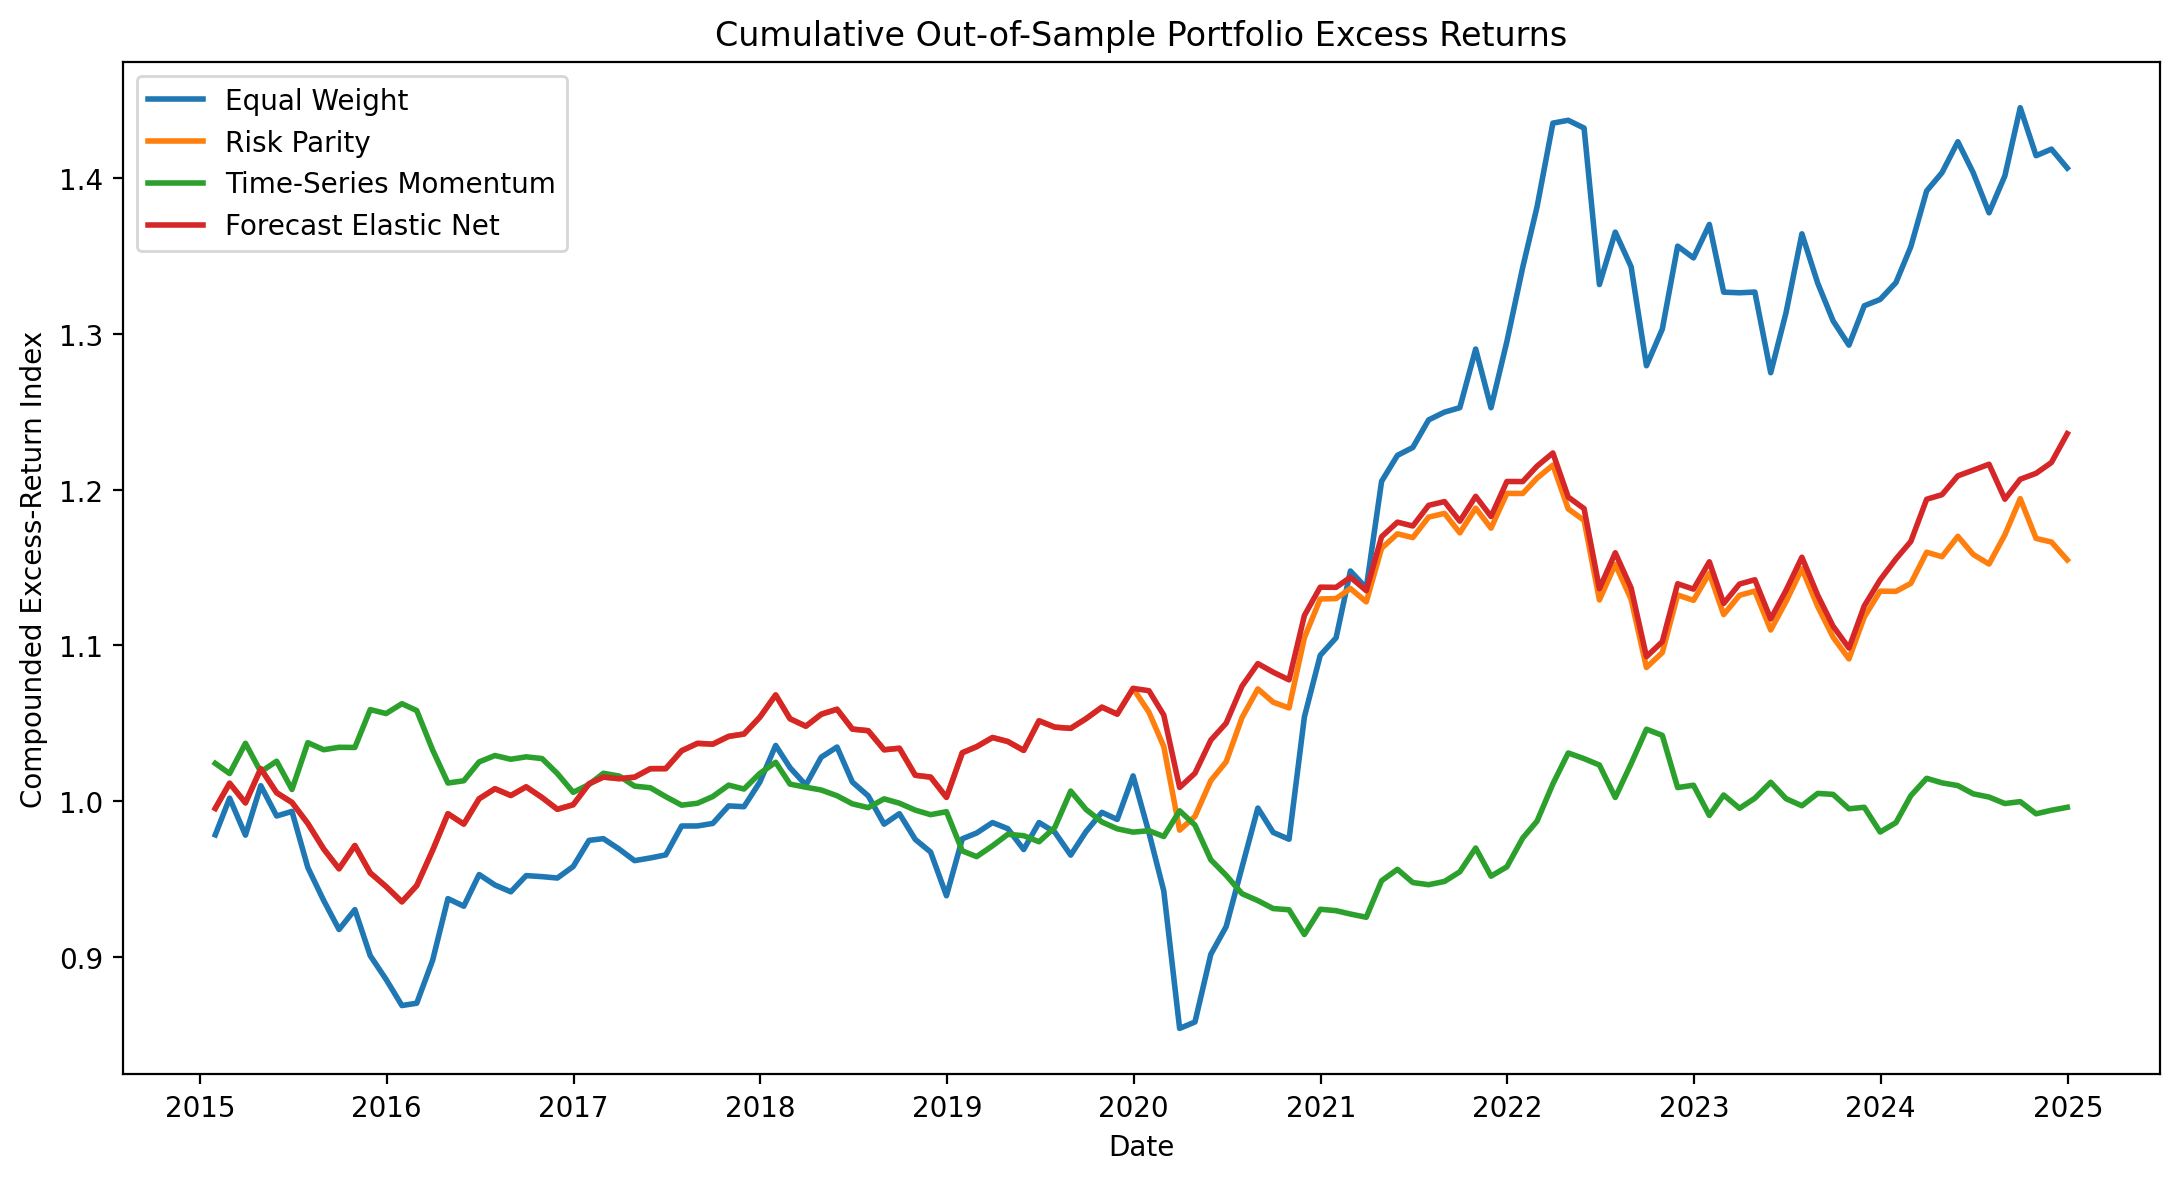

The advantage is economically modest and sensitive to trading costs. At 10 basis points, the forecast portfolio's net Sharpe ratio of 0.439 slightly exceeds Equal Weight's 0.433. Increasing costs to 25 basis points reduces the forecast portfolio's Sharpe to 0.409, and at 50 basis points it falls further to 0.358. Its corresponding net annualized returns decline from 2.25% to 2.09% and 1.83%.

The forecast portfolio therefore does not dominate the Equal Weight benchmark. Equal Weight generates a higher absolute return and requires essentially no target-weight turnover under the turnover convention used here. The forecast portfolio's advantage is instead a modest improvement in risk-adjusted performance at low transaction costs, together with substantially lower volatility and drawdown.


#### Benchmark Exposure and Source of Portfolio Performance

The forecast portfolio's lower volatility raises the question of how much of its performance reflects exposure to the simple benchmark strategies. Its monthly net returns are highly correlated with Risk Parity, with a correlation of 0.939. The correlation with Equal Weight is also high at 0.866, while its correlation with Time-Series Momentum is negative at -0.361.

A regression of the forecast portfolio's monthly net excess return on the three benchmark portfolios confirms that Risk Parity explains most of its systematic behavior. The estimated loading on Risk Parity is 0.851, compared with only 0.022 on Equal Weight and -0.037 on Time-Series Momentum. Together, the three benchmarks explain 88.27% of the monthly variation in the forecast portfolio.

The regression nevertheless leaves a positive descriptive intercept. Annualized, this intercept is approximately 0.82%. A decomposition of average annual return attributes approximately 1.35 percentage points of the forecast portfolio's 2.25% annual net return to Risk Parity exposure, 0.08 percentage points to Equal Weight exposure, essentially zero to Time-Series Momentum, and 0.82 percentage points to the regression intercept. Because no standard error or t-statistic is estimated for this intercept, it should not be interpreted as statistically significant alpha.

The forecast strategy therefore behaves primarily like a dynamically modified risk-parity portfolio, while retaining a smaller return component that is not captured by the three benchmark rules.

### Interpretation and Discussion

The central finding of the analysis is not that greater model complexity leads to better return forecasts. Instead, the strongest results come from combining a relatively small information set with regularization and an estimation window that emphasizes recent history. This pattern is plausible in a setting where expected returns are noisy, predictive relationships may evolve over time, and the number of genuinely independent time-series observations is much smaller than the number of asset-month observations might initially suggest.

#### Why Does the Rolling Window Perform Better?

The difference between expanding and rolling estimation is one of the clearest patterns in the results. The strongest characteristic-based models perform better when estimation is restricted to the most recent ten years, and this advantage becomes more pronounced for the preferred Elastic Net after global macroeconomic variables are added.

One possible explanation is that return-predictive relationships are not fully stable over the full sample. Financial markets can change with monetary regimes, regulation, investor participation, technology, and the composition of risks priced by investors. If relationships observed in the early 2000s are less relevant to the 2020s, retaining all historical observations can dilute more recent information.

The rolling window therefore trades sample size for relevance. It discards older observations and consequently increases estimation uncertainty, but it allows the model to place greater implicit weight on relationships observed during the most recent decade. The results are consistent with the benefit of greater relevance outweighing the cost of a smaller estimation sample in this dataset. However, the comparison does not by itself establish structural change as the cause; some of the difference could also reflect sampling variation over the particular 2015-2024 evaluation period.

#### Why Does Elastic Net Benefit from Global Macro Information?

The global macro results suggest that aggregate economic conditions contain incremental information about expected returns, but that this signal is weak relative to the noise in the predictor set. Elastic Net is well suited to such an environment because it shrinks coefficient estimates and can set weak predictors to zero, limiting the influence of unstable relationships.

This interpretation is consistent with the contrast across models. Once macro variables are introduced, the regularized Elastic Net improves substantially while unregularized OLS and the more flexible tree-based models deteriorate. Random Forest and Gradient Boosting can represent nonlinearities and complex interactions, but that flexibility is useful only when the sample contains enough stable information to estimate those relationships. In this panel, additional flexibility appears to increase estimation noise faster than it increases useful forecasting signal.

The poor performance of the nonlinear models should therefore not be interpreted as evidence that nonlinear relationships are unimportant in asset pricing generally. A more limited conclusion is appropriate: with monthly observations, 50 assets, a relatively short time dimension, and a weak return signal, these models do not generalize successfully out of sample in the present application.

#### Global Versus Country-Specific Information

The contrast between global and country-specific macroeconomic information is also economically informative. Global macro variables improve the preferred rolling Elastic Net, whereas the curated country variables provide almost no additional forecasting gain once characteristics and global conditions are already included.

Several explanations are possible. Common global financial conditions may be more important for this asset universe than country-specific variation. The country variables may also contain information that is persistent or redundant with the global state, leaving little incremental predictive content at a one-month horizon. In addition, Class A represents more than half of the asset universe but has no natural country assignment, limiting the role that country-specific information can play consistently across the full panel.

The result should therefore not be interpreted as evidence that country fundamentals are economically irrelevant. It shows more narrowly that the available country-level variables do not provide stable incremental next-month forecasting value under the predictor transformations, models, and real-time timing conventions considered here.

#### Why Does Additional Complexity Not Help?

The interaction and extended-macro experiments provide two additional tests of whether the core forecasting design is simply too restrictive.

The characteristic-macro interaction model allows the predictive effect of an asset characteristic to depend explicitly on the global macroeconomic state. This is an economically plausible mechanism and is consistent with the broader idea that expected-return relationships may vary across environments. In practice, however, the interaction specification does not improve out-of-sample performance. The selected interaction coefficients are also unstable across annual estimation windows, with few interactions surviving regularization repeatedly. Within the specifications considered here, the improvement from global macro information therefore appears to come primarily from including the global variables directly rather than from stable characteristic-macro interaction effects.

The extended country-macro experiment reaches a similar conclusion from a different direction. After cleaning the wider panel, 130 additional macro predictors remain, and the two-stage procedure gives these variables an opportunity to contribute through regularized screening followed by a nonlinear Gradient Boosting model. The resulting forecasts nevertheless fail to improve on the core specification, and the extended variables selected by Elastic Net vary substantially across forecasting windows.

Together, these experiments suggest that neither greater functional flexibility nor substantially greater predictor dimensionality uncovers a stable additional forecasting signal in this sample. The negative results are informative: they indicate that the superior performance of the preferred specification is not simply the result of having failed to search a sufficiently large model or predictor space. In this application, parsimony appears more valuable than additional complexity.

#### Economic Interpretation of the Portfolio Results

The portfolio exercise provides a different perspective from forecast MSE or OOS R-squared. A forecasting model does not need to explain a large fraction of monthly return variation to be economically useful if its forecasts help rank assets or size exposures more efficiently. The preferred rolling GLOBAL Elastic Net provides some evidence of such value. Its portfolio operates at substantially lower volatility and drawdown than Equal Weight while producing a slightly higher Sharpe ratio under the primary transaction-cost assumption.

The improvement is nevertheless modest. Equal Weight earns a higher absolute return and requires essentially no target-weight turnover under the convention used here. As transaction costs increase, the small Sharpe-ratio advantage of the forecast portfolio disappears. The model therefore does not produce a dominant trading strategy. Its economic contribution is more limited: when implementation is inexpensive, the forecasts appear to improve risk allocation slightly.

The benchmark-exposure analysis further qualifies this conclusion. The forecast portfolio is highly correlated with Risk Parity, and the three benchmark strategies explain approximately 88% of its monthly return variation. The portfolio is also usually net long, with its average net exposure close to one. Much of its low-volatility behavior is therefore consistent with a risk-scaled long portfolio rather than an aggressive market-neutral strategy driven entirely by return forecasts.

At the same time, benchmark exposure does not explain everything. The regression leaves a positive annualized descriptive intercept of approximately 0.82%. This is consistent with some forecast-specific contribution beyond the benchmark exposures, but no standard error or significance test is attached to the intercept. It should therefore be interpreted as descriptive evidence rather than statistically established abnormal performance.

Overall, the economic evidence is consistent with the statistical results: the forecasts appear to contain some useful information, but the magnitude is small and much of the resulting portfolio behavior remains closely related to a simple risk-based allocation rule.

#### Limitations and Further Research

Several limitations should shape how these results are interpreted. First, although every individual test-year forecast is genuinely out of sample, the rolling GLOBAL Elastic Net was selected after comparing forecasting performance across models over the 2015-2024 evaluation period. The subsequent portfolio analysis therefore evaluates the economic implications of the preferred forecasting specification rather than providing a completely independent second holdout test. A stricter design could reserve a final block of years exclusively for portfolio evaluation after all forecasting decisions have been made.

Second, the improvements themselves are small, and I do not conduct formal statistical tests of whether the differences in OOS R-squared or Sharpe ratios are distinguishable from the corresponding benchmarks. The positive forecasting results and slight portfolio advantage should therefore be interpreted as descriptive evidence of improvement rather than definitive statistical superiority.

Third, transaction costs are calculated from changes in target weights because the available excess-return data do not permit exact reconstruction of post-return portfolio weights. This convention is applied consistently across strategies, but it remains an approximation to actual trading turnover. More detailed price, financing, and instrument-level cost data would allow a more realistic assessment of implementability.

Fourth, the forecasting models are estimated jointly across asset classes. Class indicators allow for broad differences across classes, and performance is evaluated separately by class, but class-specific models are not estimated. Given the substantial heterogeneity in the class-level results, a larger sample could be used to test whether characteristics and macroeconomic conditions operate differently across asset classes rather than requiring most relationships to be shared.

The analysis also establishes the incremental value of broad predictor groups rather than identifying a single characteristic or global macro variable as the source of the preferred model's forecasting gain. Examining the stability, sign, and magnitude of individual Elastic Net coefficients across forecasting windows would provide a more detailed view of which predictors carry the signal and how persistent those relationships are.

These limitations do not overturn the main findings, but they place them in the appropriate context. The evidence supports modest and potentially useful return predictability, not a large or permanent return anomaly. The broader lesson is that, in this sample, controlling model complexity and respecting changes through time are more valuable than simply adding more predictors or more flexible forecasting methods.

### Conclusion

This paper evaluates whether asset characteristics and macroeconomic information can forecast monthly excess returns across a diversified panel of 50 assets and whether those forecasts are economically useful for portfolio allocation.

Three conclusions emerge. First, asset characteristics contain modest out-of-sample predictive information, but the signal is considerably stronger when estimation focuses on the most recent ten years rather than all available historical observations. The superior performance of the rolling window is consistent with time variation in return-predictive relationships and suggests that very old observations may sometimes dilute more relevant recent information.

Second, macroeconomic information is useful selectively rather than universally. Adding four global macro variables materially improves the rolling Elastic Net, raising OOS R-squared relative to zero from 0.142% to 0.467%. Country-specific macro variables provide almost no additional gain. Neither explicit characteristic-macro interactions nor the much wider extended country-macro panel improves forecasting performance, while more flexible Random Forest and Gradient Boosting models perform substantially worse once macro variables are introduced. In this dataset, regularization and a parsimonious information set are more valuable than additional model complexity.

Third, the forecasting improvement has some economic value, but the magnitude is limited. The forecast-based Elastic Net portfolio achieves lower volatility and drawdown than Equal Weight and produces a slightly higher Sharpe ratio when trading costs are low. It does not generate a higher raw return than Equal Weight, and its risk-adjusted advantage disappears as transaction costs increase. Moreover, most of its return variation is closely related to Risk Parity, indicating that the strategy behaves primarily like a forecast-adjusted risk allocation rather than a completely independent source of returns.

For a portfolio manager, the practical implication is therefore not that machine learning replaces simple allocation rules. The evidence instead supports using a regularized forecasting model as a modest adjustment to a disciplined risk-allocation process. Recent asset characteristics and a small set of global macroeconomic conditions appear more useful than aggressively expanding predictor dimensionality or nonlinear model complexity.

More broadly, the results illustrate a central difficulty of empirical return prediction: statistical flexibility is abundant, but stable signal is scarce. The evidence in this sample supports modest and potentially useful predictability, but not a large or robust return anomaly. The models that perform best are those that restrict flexibility while remaining responsive to changes in the investment environment.

### References

Gu, Shihao, Bryan Kelly, and Dacheng Xiu. 2020. “Empirical Asset Pricing via Machine Learning.” *The Review of Financial Studies* 33 (5): 2223–2273.

Welch, Ivo, and Amit Goyal. 2008. “A Comprehensive Look at the Empirical Performance of Equity Premium Prediction.” *The Review of Financial Studies* 21 (4): 1455–1508.